# Tenfold Tuning Runner

This notebook loads the setup cells from `ten_min_segment_pipeline_v10.4.ipynb`, then runs a grouped 10-fold class-weight x label-smoothing sweep with pooled out-of-fold Severe calibration.

The sweep is executed sequentially with aggressive TensorFlow and plot cleanup between folds and between weight settings to reduce CPU memory buildup.

In [1]:
from pathlib import Path
import hashlib
import os
import subprocess
import sys

DEFAULT_REPO_URL = "https://github.com/zeyneppguler23/CTG_Dissertation.git"
DEFAULT_BRANCH = "helper"
PROJECT_ROOT = Path("/content/CTG_Dissertation")
STAMP_PATH = PROJECT_ROOT / ".colab_requirements_installed"

REPO_URL = os.environ.get("CTG_COLAB_REPO_URL", DEFAULT_REPO_URL).strip()
BRANCH = os.environ.get("CTG_COLAB_REPO_BRANCH", DEFAULT_BRANCH).strip()


def run_command(args, cwd=None, capture_output=False):
    return subprocess.run(
        args,
        cwd=str(cwd) if cwd else None,
        check=True,
        text=True,
        capture_output=capture_output,
    )


def remote_branch_exists(repo_url: str, branch: str) -> bool:
    result = subprocess.run(
        ["git", "ls-remote", "--heads", repo_url, branch],
        check=False,
        text=True,
        capture_output=True,
    )
    return result.returncode == 0 and bool(result.stdout.strip())


def requirements_fingerprint(requirements_path: Path) -> str:
    return hashlib.sha256(requirements_path.read_bytes()).hexdigest()


if "google.colab" in sys.modules:
    if not remote_branch_exists(REPO_URL, BRANCH):
        raise RuntimeError(
            "The requested Colab source branch was not found on the remote repository. "
            f"repo={REPO_URL} branch={BRANCH}. "
            "Push the branch first or set CTG_COLAB_REPO_URL / CTG_COLAB_REPO_BRANCH to a valid remote source."
        )

    if not PROJECT_ROOT.exists():
        run_command(
            [
                "git",
                "clone",
                "--branch",
                BRANCH,
                "--single-branch",
                REPO_URL,
                str(PROJECT_ROOT),
            ]
        )
    else:
        print(f"Using existing repo at {PROJECT_ROOT}")
        run_command(["git", "remote", "set-url", "origin", REPO_URL], cwd=PROJECT_ROOT)
        run_command(["git", "fetch", "origin", BRANCH], cwd=PROJECT_ROOT)
        run_command(["git", "checkout", BRANCH], cwd=PROJECT_ROOT)
        run_command(["git", "reset", "--hard", f"origin/{BRANCH}"], cwd=PROJECT_ROOT)

    os.environ["CTG_DISSERTATION_ROOT"] = str(PROJECT_ROOT)

    requirements_path = PROJECT_ROOT / "requirements.txt"
    current_fingerprint = requirements_fingerprint(requirements_path)
    installed_fingerprint = STAMP_PATH.read_text(encoding="utf-8").strip() if STAMP_PATH.exists() else ""

    if installed_fingerprint != current_fingerprint:
        run_command(
            [
                sys.executable,
                "-m",
                "pip",
                "install",
                "--upgrade",
                "--force-reinstall",
                "-r",
                str(requirements_path),
            ]
        )
        STAMP_PATH.write_text(current_fingerprint + "\n", encoding="utf-8")
        raise SystemExit(
            "Dependencies were installed or refreshed for Colab. Restart the runtime now, then run this cell again before running the tuning cell."
        )

    os.chdir(PROJECT_ROOT)
    print(f"Colab repo ready at: {PROJECT_ROOT}")
    print(f"Remote source: {REPO_URL} [{BRANCH}]")
    print("Colab only sees remote code. Unpushed local notebook/script changes are not available there.")
    print("If you just restarted the runtime, run this cell once more and then run the tuning cell.")
    print("Set Runtime -> Change runtime type -> GPU before running the tuning cell.")
else:
    print("Not running in Colab; skipping clone/install bootstrap.")

Not running in Colab; skipping clone/install bootstrap.


Project root: C:\Users\ZEYNEP\OneDrive\Desktop\CTG_Dissertation
Working directory: C:\Users\ZEYNEP\OneDrive\Desktop\CTG_Dissertation\src\Transfer_Learning
StratifiedGroupKFold available — will use group-aware stratified splitting.


c:\Users\ZEYNEP\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


TensorFlow 2.16.1 | NumPy 1.26.4
GPU available: False
════════════════════════════════════════════════════════════
CONFIGURATION SUMMARY
════════════════════════════════════════════════════════════
  Windows used:      Steps [2, 3]
  Sampling rate:     4 Hz raw -> 1 Hz model input
  Window length:     30 min = 1800 samples @ 1 Hz
  Canonical offsets: {2: (60, 30), 3: (30, 0)}
  Controlled windows:3 per step
    Step 2: [(70, 40), (60, 30), (50, 20)]
    Step 3: [(50, 20), (40, 10), (30, 0)]
  Max NaN frac:      16%
  CV folds:          10
  Requested min Severe/fold: 10 step-units
  Label smoothing:   0.05
  Softmax baseline:  enabled
  Feature branch:    compact engineered FHR features
  Grouped CV:        by rec_id (unchanged)
════════════════════════════════════════════════════════════
Step 2: 548 labelled records (4 uninterpretable excluded)
  Class 0 (Normal): 229 (41.8%)
  Class 1 (Mild): 251 (45.8%)
  Class 2 (Severe): 68 (12.4%)
Step 3: 337 labelled records (215 uninterpretable

Model: "FHR-SegNet-ClinFeat"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ fhr_input           │ (None, 1800, 1)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ temporal_conv       │ (None, 1800, 32)  │        224 │ fhr_input[0][0]   │
│ (Conv1D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ temporal_bn         │ (None, 1800, 32)  │        128 │ temporal_conv[0]… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ temporal_relu       │ (None, 1800, 32)  │          0 │ temporal_bn[0][0] │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, 450, 32)   │          0 │ temporal_relu[0]… │
│ (AveragePooling1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout1 (Dropout)  │ (None, 450, 32)   │          0 │ pool1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ms_sep_0            │ (None, 450, 32)   │      1,120 │ dropout1[0][0]    │
│ (SeparableConv1D)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ms_sep_1            │ (None, 450, 32)   │      1,248 │ dropout1[0][0]    │
│ (SeparableConv1D)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ms_sep_2            │ (None, 450, 32)   │      1,504 │ dropout1[0][0]    │
│ (SeparableConv1D)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ms_bn_0             │ (None, 450, 32)   │        128 │ ms_sep_0[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ms_bn_1             │ (None, 450, 32)   │        128 │ ms_sep_1[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ms_bn_2             │ (None, 450, 32)   │        128 │ ms_sep_2[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ms_relu_0           │ (None, 450, 32)   │          0 │ ms_bn_0[0][0]     │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ms_relu_1           │ (None, 450, 32)   │          0 │ ms_bn_1[0][0]     │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ms_relu_2           │ (None, 450, 32)   │          0 │ ms_bn_2[0][0]     │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ms_concat           │ (None, 450, 96)   │          0 │ ms_relu_0[0][0],  │
│ (Concatenate)       │                   │            │ ms_relu_1[0][0],  │
│                     │                   │            │ ms_relu_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ proj1 (Conv1D)      │ (None, 450, 32)   │      3,072 │ ms_concat[0][0] 

 Total params: 13,507 (52.76 KB)

 Trainable params: 13,059 (51.01 KB)

 Non-trainable params: 448 (1.75 KB)


Total parameters: 13,507
Training functions defined:
  train_from_scratch          - scratch training with record-step BA early stopping
  _make_model_input           - builds [X, clin] or X
  build_step_target_table     - one labeled row per record-step
  resolve_min_severe_threshold - feasible Severe threshold per fold
  oversample_minority_records - optional Severe-window oversampling
  calibrate_predictions       - optional post-hoc Severe boost
  stratified_record_kfold     - grouped CV using record-step labels
  analyze_validation_set      - fold quality assessment at record-step level
Evaluation functions defined:
  aggregate_to_record_step_level — mean probability aggregation within each record-step
  compute_metrics                — accuracy, balanced acc, macro F1, per-class
  print_metrics                  — formatted display
Plotting utilities defined (confusion matrix, fold summary)
Cross-validation pipeline defined (run_grouped_cv)
  Includes grouped CV by rec_id, train-

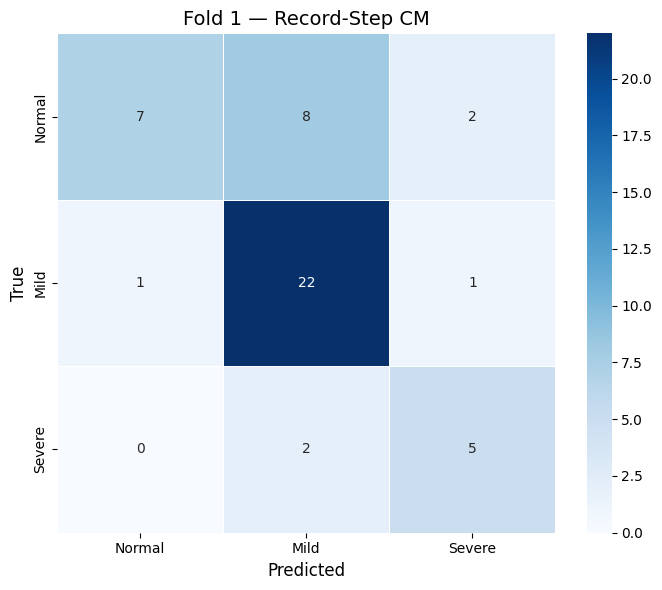


FOLD 2 / 10
  Validation quality: RELIABLE
    Normal: 26 step-units, 78 windows
    Mild: 19 step-units, 57 windows
    Severe: 7 step-units, 21 windows

TRAINING FROM SCRATCH
  Class weights (manual override): {0: 0.9, 1: 1.1, 2: 2.3}
  Early stopping monitor: val_record_step_balanced_accuracy
  Label smoothing: 0.00
Epoch 1/100
619/621 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4494 - loss: 1.2945  val_record_step_balanced_accuracy: 0.3445
621/621 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - accuracy: 0.4525 - loss: 1.3027 - val_accuracy: 0.4167 - val_loss: 1.0516 - val_record_step_balanced_accuracy: 0.3445 - learning_rate: 0.0010
Epoch 2/100
612/621 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4909 - loss: 1.2045  val_record_step_balanced_accuracy: 0.4120
621/621 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.4823 - loss: 1.2414 - val_accuracy: 0.4744 - val_loss: 1.0330 - val_record_step_balanced_accuracy: 0.4120 - learning_rate: 0.0010
Epoch 3/100
615/621 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/

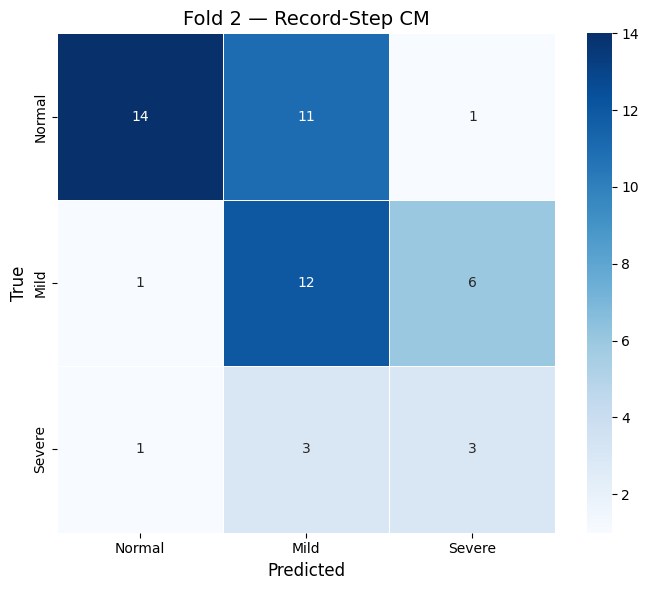


FOLD 3 / 10
  Validation quality: RELIABLE
    Normal: 16 step-units, 48 windows
    Mild: 19 step-units, 57 windows
    Severe: 7 step-units, 21 windows

TRAINING FROM SCRATCH
  Class weights (manual override): {0: 0.9, 1: 1.1, 2: 2.3}
  Early stopping monitor: val_record_step_balanced_accuracy
  Label smoothing: 0.00
Epoch 1/100
636/636 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.3936 - loss: 1.3623  val_record_step_balanced_accuracy: 0.4441
636/636 ━━━━━━━━━━━━━━━━━━━━ 30s 24ms/step - accuracy: 0.4300 - loss: 1.2995 - val_accuracy: 0.5397 - val_loss: 1.0237 - val_record_step_balanced_accuracy: 0.4441 - learning_rate: 0.0010
Epoch 2/100
635/636 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.4815 - loss: 1.2501  val_record_step_balanced_accuracy: 0.3487
636/636 ━━━━━━━━━━━━━━━━━━━━ 11s 17ms/step - accuracy: 0.4969 - loss: 1.2127 - val_accuracy: 0.4524 - val_loss: 1.0008 - val_record_step_balanced_accuracy: 0.3487 - learning_rate: 0.0010
Epoch 3/100
634/636 ━━━━━━━━━━━━━━━━━━━━ 0

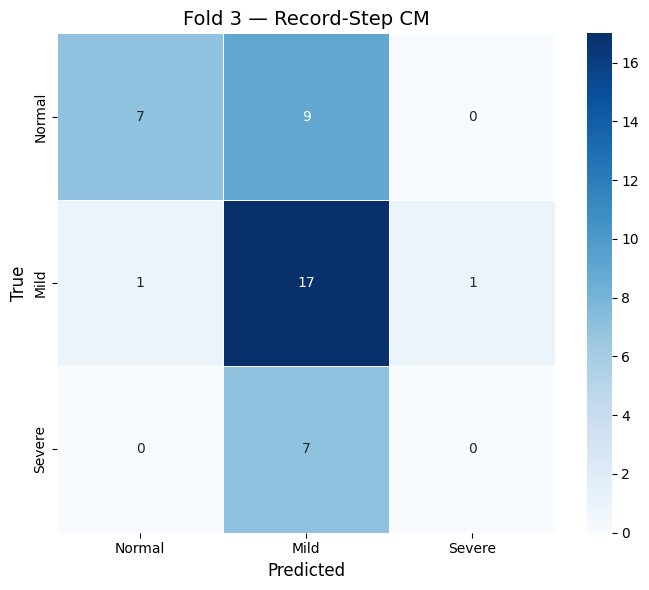


FOLD 4 / 10
  Validation quality: RELIABLE
    Normal: 11 step-units, 33 windows
    Mild: 26 step-units, 78 windows
    Severe: 8 step-units, 24 windows

TRAINING FROM SCRATCH
  Class weights (manual override): {0: 0.9, 1: 1.1, 2: 2.3}
  Early stopping monitor: val_record_step_balanced_accuracy
  Label smoothing: 0.00
Epoch 1/100
630/632 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.4397 - loss: 1.2814  val_record_step_balanced_accuracy: 0.5711
632/632 ━━━━━━━━━━━━━━━━━━━━ 70s 75ms/step - accuracy: 0.4505 - loss: 1.2980 - val_accuracy: 0.4963 - val_loss: 0.9898 - val_record_step_balanced_accuracy: 0.5711 - learning_rate: 0.0010
Epoch 2/100
632/632 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.5053 - loss: 1.2078  val_record_step_balanced_accuracy: 0.6157
632/632 ━━━━━━━━━━━━━━━━━━━━ 41s 64ms/step - accuracy: 0.4964 - loss: 1.2431 - val_accuracy: 0.5704 - val_loss: 0.9631 - val_record_step_balanced_accuracy: 0.6157 - learning_rate: 0.0010
Epoch 3/100
631/632 ━━━━━━━━━━━━━━━━━━━━ 0

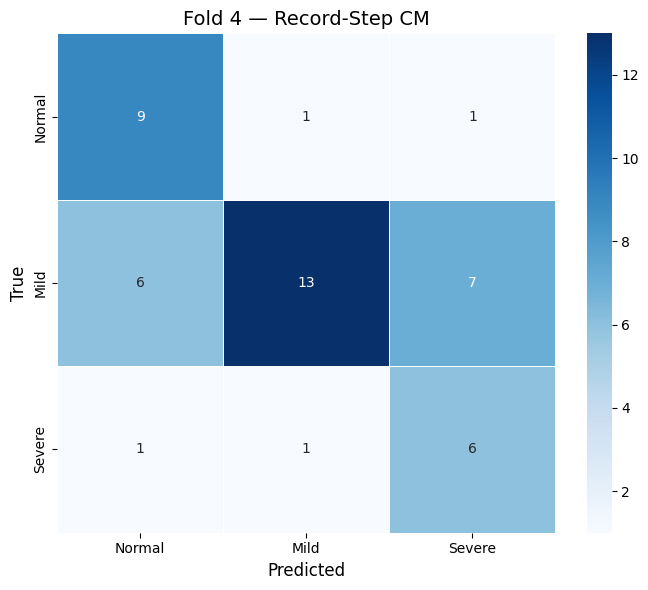


FOLD 5 / 10
  Validation quality: RELIABLE
    Normal: 16 step-units, 48 windows
    Mild: 21 step-units, 63 windows
    Severe: 5 step-units, 15 windows

TRAINING FROM SCRATCH
  Class weights (manual override): {0: 0.9, 1: 1.1, 2: 2.3}
  Early stopping monitor: val_record_step_balanced_accuracy
  Label smoothing: 0.00
Epoch 1/100
635/636 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.3955 - loss: 1.3546  val_record_step_balanced_accuracy: 0.3671
636/636 ━━━━━━━━━━━━━━━━━━━━ 28s 26ms/step - accuracy: 0.4458 - loss: 1.2928 - val_accuracy: 0.5000 - val_loss: 0.9912 - val_record_step_balanced_accuracy: 0.3671 - learning_rate: 0.0010
Epoch 2/100
631/636 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.4667 - loss: 1.2508  val_record_step_balanced_accuracy: 0.5321
636/636 ━━━━━━━━━━━━━━━━━━━━ 17s 27ms/step - accuracy: 0.4803 - loss: 1.2271 - val_accuracy: 0.5317 - val_loss: 0.9733 - val_record_step_balanced_accuracy: 0.5321 - learning_rate: 0.0010
Epoch 3/100
635/636 ━━━━━━━━━━━━━━━━━━━━ 0

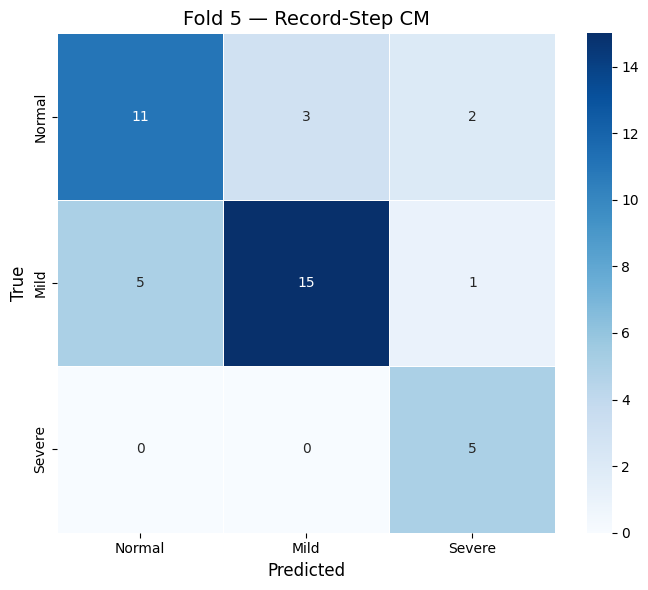


FOLD 6 / 10
  Validation quality: RELIABLE
    Normal: 24 step-units, 72 windows
    Mild: 20 step-units, 60 windows
    Severe: 6 step-units, 18 windows

TRAINING FROM SCRATCH
  Class weights (manual override): {0: 0.9, 1: 1.1, 2: 2.3}
  Early stopping monitor: val_record_step_balanced_accuracy
  Label smoothing: 0.00
Epoch 1/100
624/624 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.4069 - loss: 1.3896  val_record_step_balanced_accuracy: 0.3944
624/624 ━━━━━━━━━━━━━━━━━━━━ 28s 25ms/step - accuracy: 0.4359 - loss: 1.3290 - val_accuracy: 0.5333 - val_loss: 1.0211 - val_record_step_balanced_accuracy: 0.3944 - learning_rate: 0.0010
Epoch 2/100
621/624 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.4979 - loss: 1.2405  val_record_step_balanced_accuracy: 0.4556
624/624 ━━━━━━━━━━━━━━━━━━━━ 17s 20ms/step - accuracy: 0.5000 - loss: 1.2527 - val_accuracy: 0.4667 - val_loss: 1.0272 - val_record_step_balanced_accuracy: 0.4556 - learning_rate: 0.0010
Epoch 3/100
624/624 ━━━━━━━━━━━━━━━━━━━━ 0

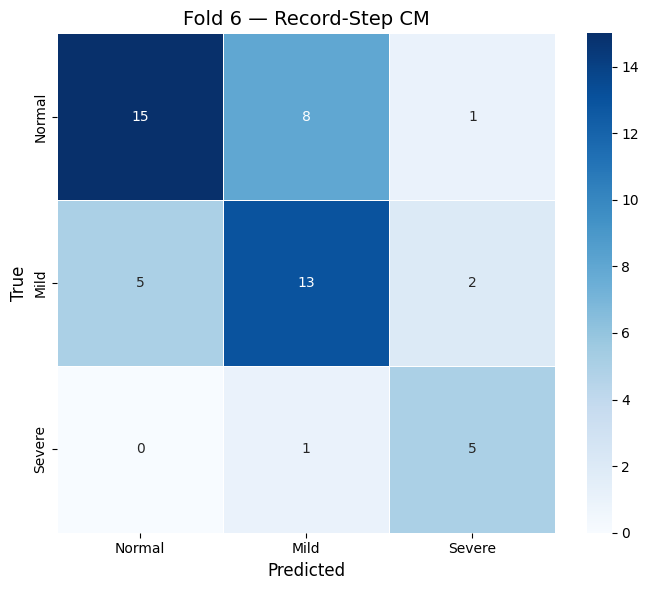


FOLD 7 / 10
  Validation quality: RELIABLE
    Normal: 15 step-units, 45 windows
    Mild: 26 step-units, 78 windows
    Severe: 5 step-units, 15 windows

TRAINING FROM SCRATCH
  Class weights (manual override): {0: 0.9, 1: 1.1, 2: 2.3}
  Early stopping monitor: val_record_step_balanced_accuracy
  Label smoothing: 0.00
Epoch 1/100
628/630 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.4076 - loss: 1.3480  val_record_step_balanced_accuracy: 0.5060
630/630 ━━━━━━━━━━━━━━━━━━━━ 26s 22ms/step - accuracy: 0.4444 - loss: 1.2917 - val_accuracy: 0.3406 - val_loss: 1.0895 - val_record_step_balanced_accuracy: 0.5060 - learning_rate: 0.0010
Epoch 2/100
629/630 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.4930 - loss: 1.2709  val_record_step_balanced_accuracy: 0.5547
630/630 ━━━━━━━━━━━━━━━━━━━━ 13s 21ms/step - accuracy: 0.5167 - loss: 1.2135 - val_accuracy: 0.4783 - val_loss: 1.0146 - val_record_step_balanced_accuracy: 0.5547 - learning_rate: 0.0010
Epoch 3/100
629/630 ━━━━━━━━━━━━━━━━━━━━ 0

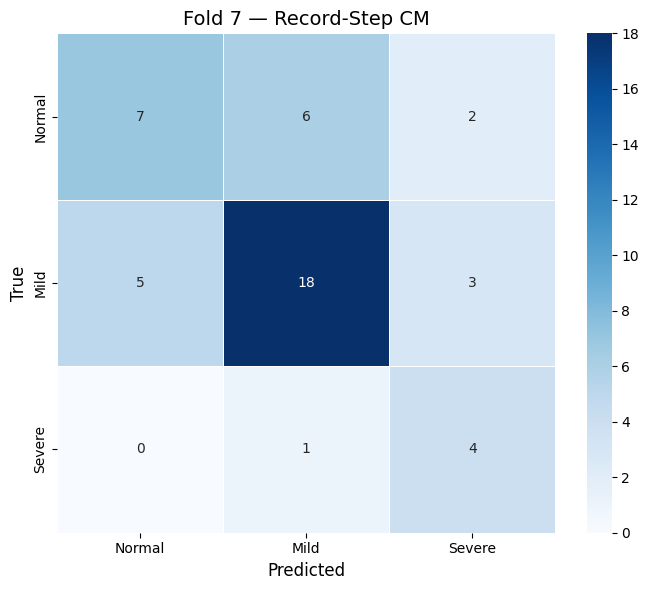


FOLD 8 / 10
  Validation quality: RELIABLE
    Normal: 16 step-units, 48 windows
    Mild: 22 step-units, 66 windows
    Severe: 6 step-units, 18 windows

TRAINING FROM SCRATCH
  Class weights (manual override): {0: 0.9, 1: 1.1, 2: 2.3}
  Early stopping monitor: val_record_step_balanced_accuracy
  Label smoothing: 0.00
Epoch 1/100
632/633 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4265 - loss: 1.3173  val_record_step_balanced_accuracy: 0.4602
633/633 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.4771 - loss: 1.2716 - val_accuracy: 0.5076 - val_loss: 0.9927 - val_record_step_balanced_accuracy: 0.4602 - learning_rate: 0.0010
Epoch 2/100
632/633 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5201 - loss: 1.2286  val_record_step_balanced_accuracy: 0.4186
633/633 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.5205 - loss: 1.2163 - val_accuracy: 0.5606 - val_loss: 0.9748 - val_record_step_balanced_accuracy: 0.4186 - learning_rate: 0.0010
Epoch 3/100
629/633 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/

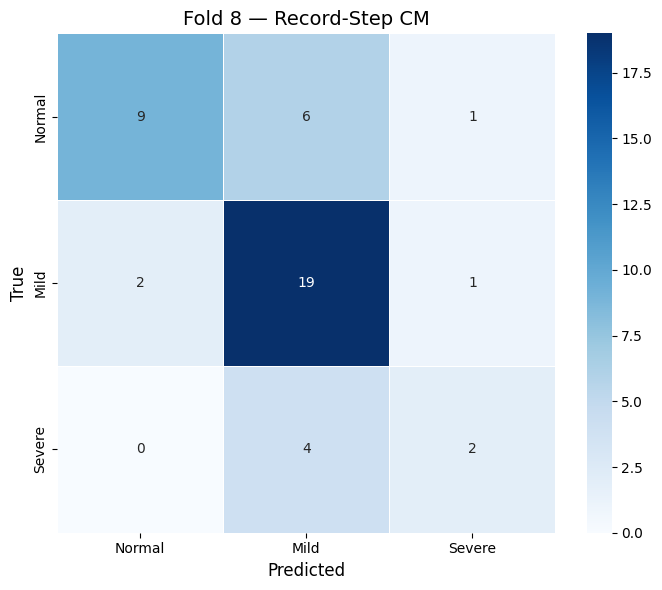


FOLD 9 / 10
  Validation quality: RELIABLE
    Normal: 23 step-units, 69 windows
    Mild: 18 step-units, 54 windows
    Severe: 10 step-units, 30 windows

TRAINING FROM SCRATCH
  Class weights (manual override): {0: 0.9, 1: 1.1, 2: 2.3}
  Early stopping monitor: val_record_step_balanced_accuracy
  Label smoothing: 0.00
Epoch 1/100
619/623 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.4963 - loss: 1.2944  val_record_step_balanced_accuracy: 0.4072
623/623 ━━━━━━━━━━━━━━━━━━━━ 17s 16ms/step - accuracy: 0.4843 - loss: 1.2737 - val_accuracy: 0.4706 - val_loss: 1.0424 - val_record_step_balanced_accuracy: 0.4072 - learning_rate: 0.0010
Epoch 2/100
622/623 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.4873 - loss: 1.2109  val_record_step_balanced_accuracy: 0.4810
623/623 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.5124 - loss: 1.2073 - val_accuracy: 0.5033 - val_loss: 1.0336 - val_record_step_balanced_accuracy: 0.4810 - learning_rate: 0.0010
Epoch 3/100
619/623 ━━━━━━━━━━━━━━━━━━━━ 0

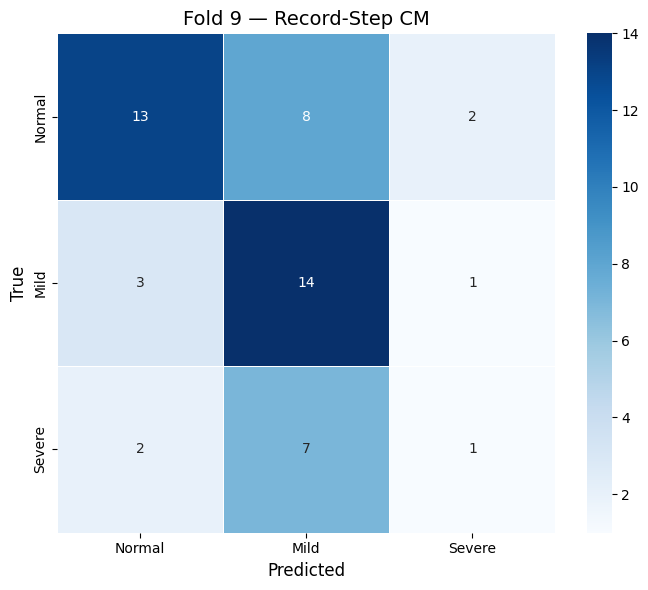


FOLD 10 / 10
  Validation quality: RELIABLE
    Normal: 24 step-units, 72 windows
    Mild: 17 step-units, 51 windows
    Severe: 5 step-units, 15 windows

TRAINING FROM SCRATCH
  Class weights (manual override): {0: 0.9, 1: 1.1, 2: 2.3}
  Early stopping monitor: val_record_step_balanced_accuracy
  Label smoothing: 0.00
Epoch 1/100
630/630 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.3786 - loss: 1.3880  val_record_step_balanced_accuracy: 0.3412
630/630 ━━━━━━━━━━━━━━━━━━━━ 15s 15ms/step - accuracy: 0.4095 - loss: 1.3332 - val_accuracy: 0.3261 - val_loss: 1.0685 - val_record_step_balanced_accuracy: 0.3412 - learning_rate: 0.0010
Epoch 2/100
622/630 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4413 - loss: 1.2445  val_record_step_balanced_accuracy: 0.3080
630/630 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.4619 - loss: 1.2366 - val_accuracy: 0.4130 - val_loss: 1.0217 - val_record_step_balanced_accuracy: 0.3080 - learning_rate: 0.0010
Epoch 3/100
627/630 ━━━━━━━━━━━━━━━━━━━━ 0s 

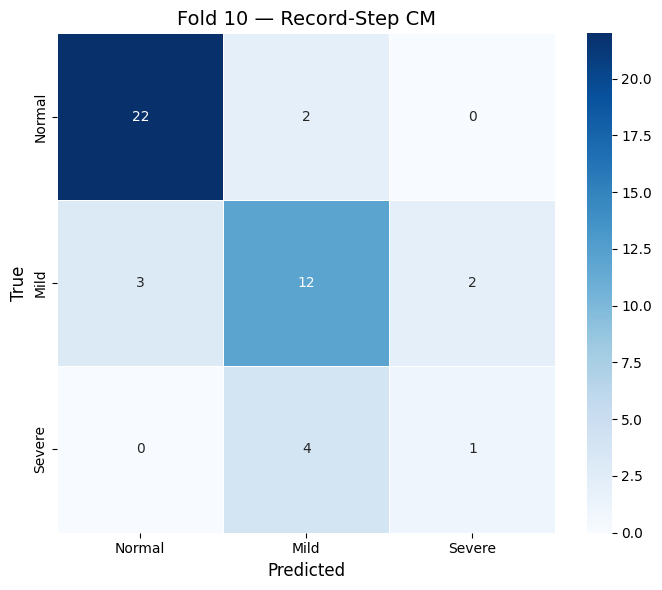

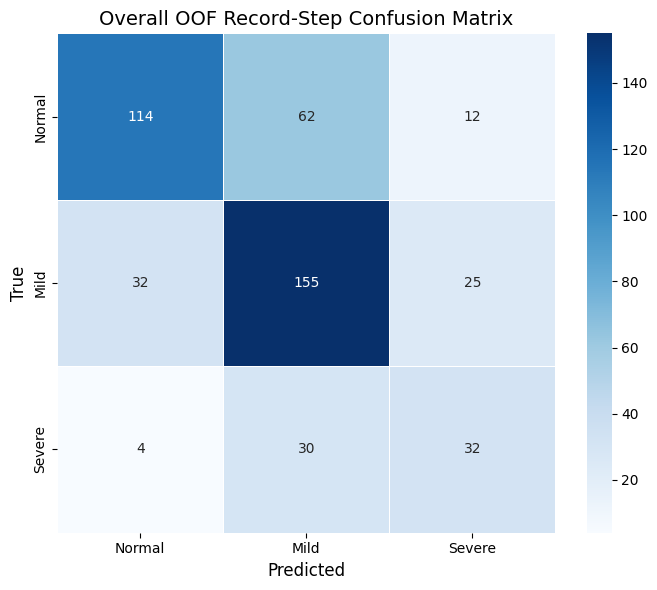

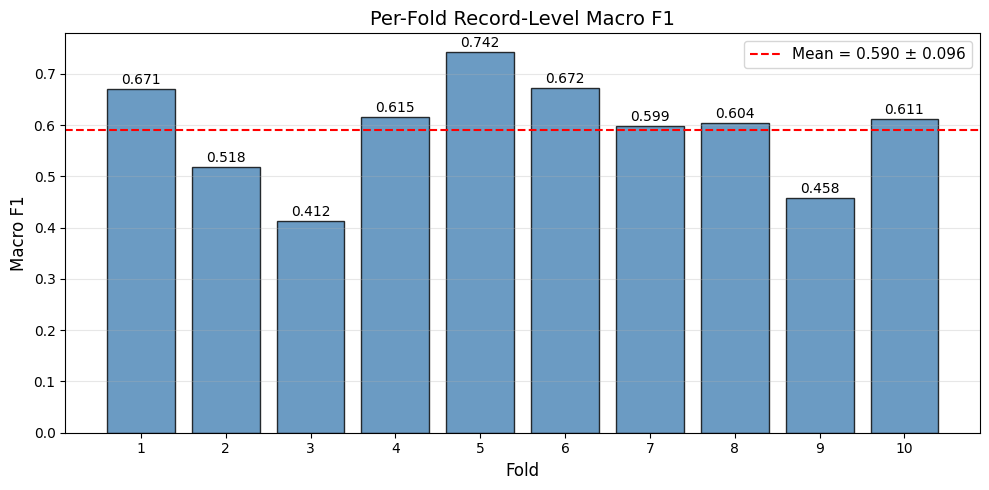

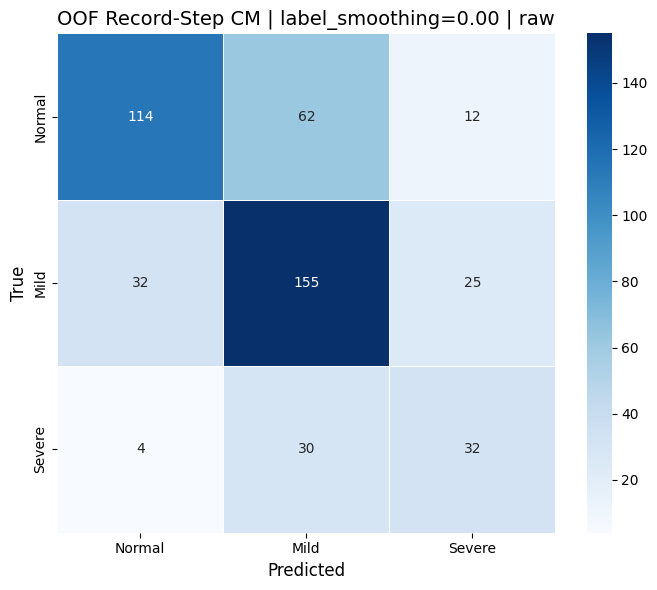

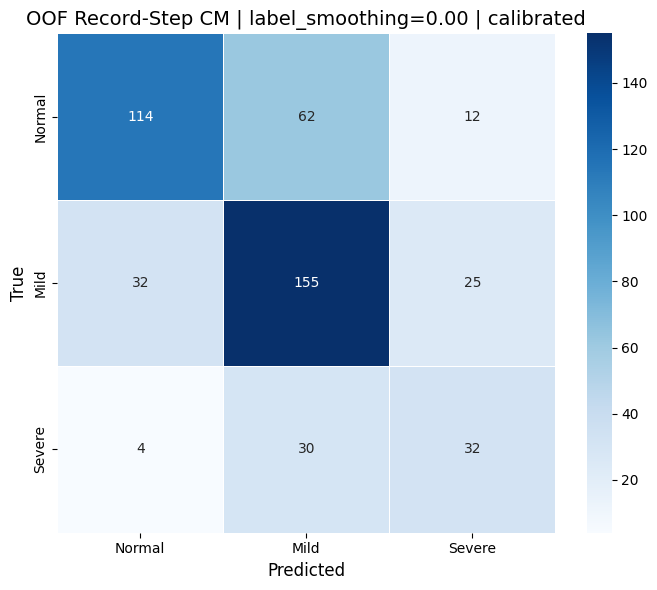


Run complete:
  Label smoothing:          0.00
  Raw OOF balanced acc:     0.6075
  Calibrated OOF bal acc:   0.6075
  Best OOF Severe boost:    0.00
  Results saved to:         C:\Users\ZEYNEP\OneDrive\Desktop\CTG_Dissertation\src\Transfer_Learning\outputs\step23_softmax_tenfold_tuning\cw_0p9_1p1_2p3\ls_0p00

Running tenfold CV for label_smoothing=0.02
Output directory: C:\Users\ZEYNEP\OneDrive\Desktop\CTG_Dissertation\src\Transfer_Learning\outputs\step23_softmax_tenfold_tuning\cw_0p9_1p1_2p3\ls_0p02
Computing engineered features from cleaned FHR windows...
  Engineered feature matrix: (1398, 10)

Generating 10-fold CV with requested >= 10 Severe step-units/fold...
  Total Severe step-units: 66, 10 folds -> max ~6/fold
  Found valid split at attempt 8 (seed=49, StratifiedGroupKFold)
    Severe step-units per val fold: [7, 7, 7, 8, 5, 6, 5, 6, 10, 5]
  Effective reliability threshold: 5 Severe step-units/fold

FOLD 1 / 10
  Validation quality: RELIABLE
    Normal: 17 step-units, 51 wi

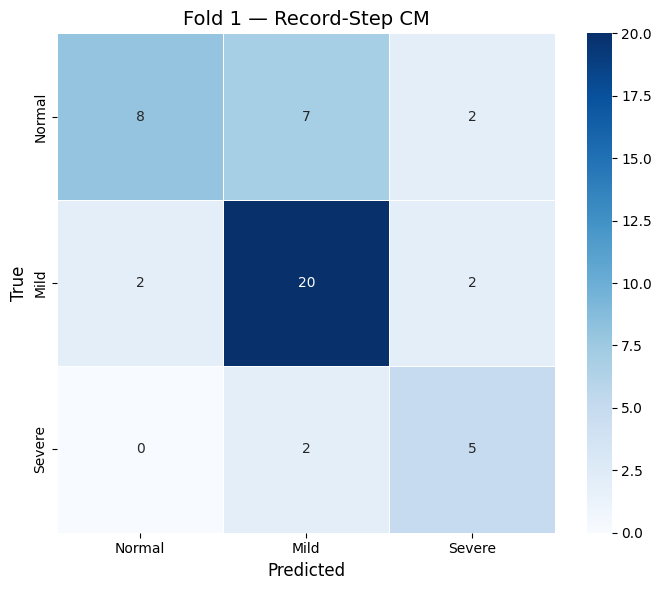


FOLD 2 / 10
  Validation quality: RELIABLE
    Normal: 26 step-units, 78 windows
    Mild: 19 step-units, 57 windows
    Severe: 7 step-units, 21 windows

TRAINING FROM SCRATCH
  Class weights (manual override): {0: 0.9, 1: 1.1, 2: 2.3}
  Early stopping monitor: val_record_step_balanced_accuracy
  Label smoothing: 0.02
Epoch 1/100
621/621 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.3769 - loss: 1.3785  val_record_step_balanced_accuracy: 0.3877
621/621 ━━━━━━━━━━━━━━━━━━━━ 22s 21ms/step - accuracy: 0.3994 - loss: 1.3420 - val_accuracy: 0.4167 - val_loss: 1.0432 - val_record_step_balanced_accuracy: 0.3877 - learning_rate: 0.0010
Epoch 2/100
616/621 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.5390 - loss: 1.1994  val_record_step_balanced_accuracy: 0.3644
621/621 ━━━━━━━━━━━━━━━━━━━━ 9s 15ms/step - accuracy: 0.5258 - loss: 1.2258 - val_accuracy: 0.4936 - val_loss: 1.0248 - val_record_step_balanced_accuracy: 0.3644 - learning_rate: 0.0010
Epoch 3/100
621/621 ━━━━━━━━━━━━━━━━━━━━ 0s

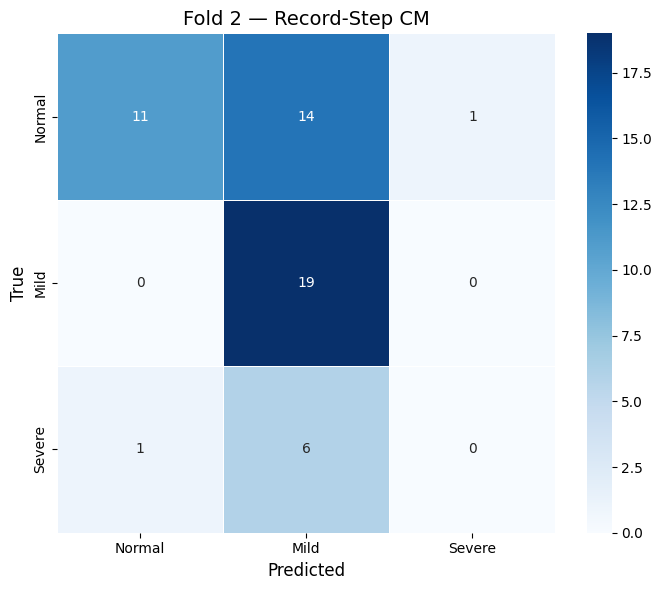


FOLD 3 / 10
  Validation quality: RELIABLE
    Normal: 16 step-units, 48 windows
    Mild: 19 step-units, 57 windows
    Severe: 7 step-units, 21 windows

TRAINING FROM SCRATCH
  Class weights (manual override): {0: 0.9, 1: 1.1, 2: 2.3}
  Early stopping monitor: val_record_step_balanced_accuracy
  Label smoothing: 0.02
Epoch 1/100
634/636 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.3962 - loss: 1.3430  val_record_step_balanced_accuracy: 0.3322
636/636 ━━━━━━━━━━━━━━━━━━━━ 16s 13ms/step - accuracy: 0.4300 - loss: 1.2888 - val_accuracy: 0.4444 - val_loss: 1.0309 - val_record_step_balanced_accuracy: 0.3322 - learning_rate: 0.0010
Epoch 2/100
634/636 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.4955 - loss: 1.2579  val_record_step_balanced_accuracy: 0.3656
636/636 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.5000 - loss: 1.2283 - val_accuracy: 0.4683 - val_loss: 1.0004 - val_record_step_balanced_accuracy: 0.3656 - learning_rate: 0.0010
Epoch 3/100
632/636 ━━━━━━━━━━━━━━━━━━━━ 0s 

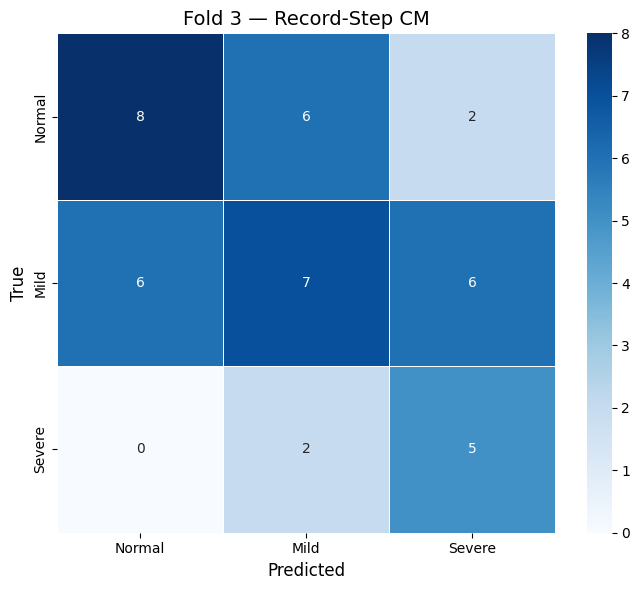


FOLD 4 / 10
  Validation quality: RELIABLE
    Normal: 11 step-units, 33 windows
    Mild: 26 step-units, 78 windows
    Severe: 8 step-units, 24 windows

TRAINING FROM SCRATCH
  Class weights (manual override): {0: 0.9, 1: 1.1, 2: 2.3}
  Early stopping monitor: val_record_step_balanced_accuracy
  Label smoothing: 0.02
Epoch 1/100
627/632 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4534 - loss: 1.2611  val_record_step_balanced_accuracy: 0.6334
632/632 ━━━━━━━━━━━━━━━━━━━━ 17s 14ms/step - accuracy: 0.4656 - loss: 1.2645 - val_accuracy: 0.4963 - val_loss: 1.0029 - val_record_step_balanced_accuracy: 0.6334 - learning_rate: 0.0010
Epoch 2/100
630/632 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5110 - loss: 1.1710  val_record_step_balanced_accuracy: 0.6078
632/632 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.5162 - loss: 1.1925 - val_accuracy: 0.4889 - val_loss: 1.0137 - val_record_step_balanced_accuracy: 0.6078 - learning_rate: 0.0010
Epoch 3/100
631/632 ━━━━━━━━━━━━━━━━━━━━ 0s

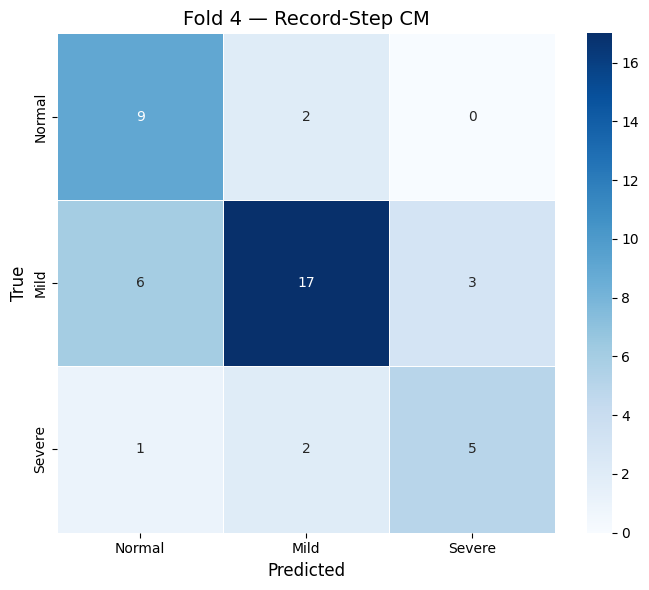


FOLD 5 / 10
  Validation quality: RELIABLE
    Normal: 16 step-units, 48 windows
    Mild: 21 step-units, 63 windows
    Severe: 5 step-units, 15 windows

TRAINING FROM SCRATCH
  Class weights (manual override): {0: 0.9, 1: 1.1, 2: 2.3}
  Early stopping monitor: val_record_step_balanced_accuracy
  Label smoothing: 0.02
Epoch 1/100
632/636 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.4300 - loss: 1.3316  val_record_step_balanced_accuracy: 0.6474
636/636 ━━━━━━━━━━━━━━━━━━━━ 14s 12ms/step - accuracy: 0.4513 - loss: 1.2902 - val_accuracy: 0.6190 - val_loss: 0.9333 - val_record_step_balanced_accuracy: 0.6474 - learning_rate: 0.0010
Epoch 2/100
635/636 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.4907 - loss: 1.2401  val_record_step_balanced_accuracy: 0.6365
636/636 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.5094 - loss: 1.2215 - val_accuracy: 0.6032 - val_loss: 0.9170 - val_record_step_balanced_accuracy: 0.6365 - learning_rate: 0.0010
Epoch 3/100
632/636 ━━━━━━━━━━━━━━━━━━━━ 0s 9m

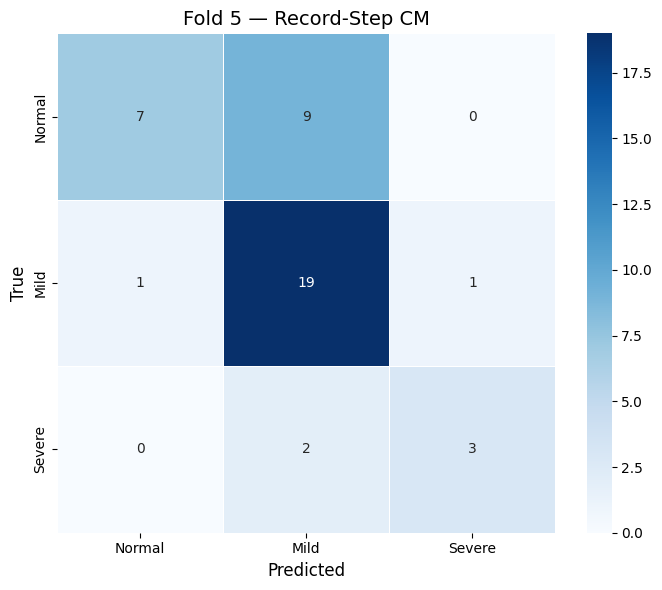


FOLD 6 / 10
  Validation quality: RELIABLE
    Normal: 24 step-units, 72 windows
    Mild: 20 step-units, 60 windows
    Severe: 6 step-units, 18 windows

TRAINING FROM SCRATCH
  Class weights (manual override): {0: 0.9, 1: 1.1, 2: 2.3}
  Early stopping monitor: val_record_step_balanced_accuracy
  Label smoothing: 0.02
Epoch 1/100
623/624 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.3812 - loss: 1.3452  val_record_step_balanced_accuracy: 0.5778
624/624 ━━━━━━━━━━━━━━━━━━━━ 16s 13ms/step - accuracy: 0.4175 - loss: 1.3024 - val_accuracy: 0.4467 - val_loss: 1.0369 - val_record_step_balanced_accuracy: 0.5778 - learning_rate: 0.0010
Epoch 2/100
619/624 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.4949 - loss: 1.2410  val_record_step_balanced_accuracy: 0.4667
624/624 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.4880 - loss: 1.2411 - val_accuracy: 0.5467 - val_loss: 0.9801 - val_record_step_balanced_accuracy: 0.4667 - learning_rate: 0.0010
Epoch 3/100
622/624 ━━━━━━━━━━━━━━━━━━━━ 0s 9

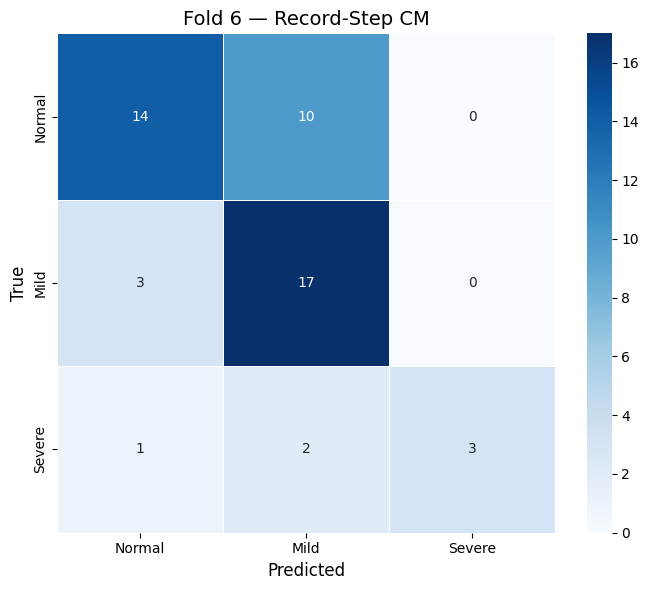


FOLD 7 / 10
  Validation quality: RELIABLE
    Normal: 15 step-units, 45 windows
    Mild: 26 step-units, 78 windows
    Severe: 5 step-units, 15 windows

TRAINING FROM SCRATCH
  Class weights (manual override): {0: 0.9, 1: 1.1, 2: 2.3}
  Early stopping monitor: val_record_step_balanced_accuracy
  Label smoothing: 0.02
Epoch 1/100
629/630 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.3482 - loss: 1.4043  val_record_step_balanced_accuracy: 0.4906
630/630 ━━━━━━━━━━━━━━━━━━━━ 16s 12ms/step - accuracy: 0.4024 - loss: 1.3157 - val_accuracy: 0.4493 - val_loss: 1.0318 - val_record_step_balanced_accuracy: 0.4906 - learning_rate: 0.0010
Epoch 2/100
625/630 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.4937 - loss: 1.2833  val_record_step_balanced_accuracy: 0.5769
630/630 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.5071 - loss: 1.2270 - val_accuracy: 0.5507 - val_loss: 0.9783 - val_record_step_balanced_accuracy: 0.5769 - learning_rate: 0.0010
Epoch 3/100
629/630 ━━━━━━━━━━━━━━━━━━━━ 0s 9

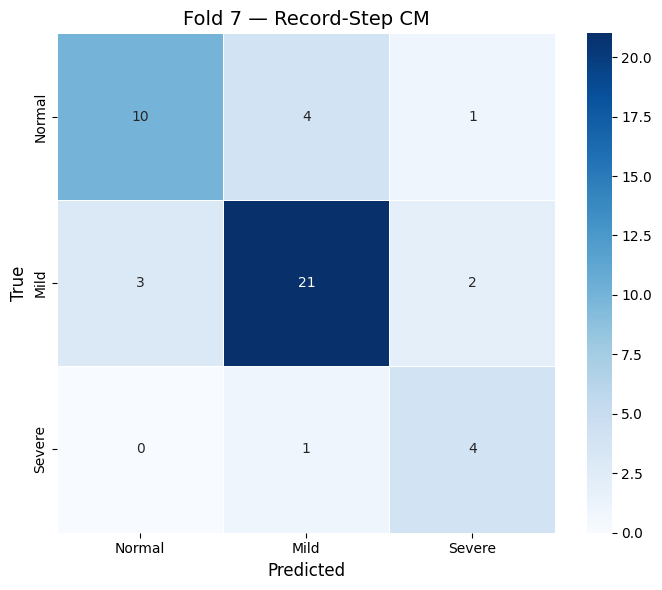


FOLD 8 / 10
  Validation quality: RELIABLE
    Normal: 16 step-units, 48 windows
    Mild: 22 step-units, 66 windows
    Severe: 6 step-units, 18 windows

TRAINING FROM SCRATCH
  Class weights (manual override): {0: 0.9, 1: 1.1, 2: 2.3}
  Early stopping monitor: val_record_step_balanced_accuracy
  Label smoothing: 0.02
Epoch 1/100
630/633 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.3844 - loss: 1.3598  val_record_step_balanced_accuracy: 0.3920
633/633 ━━━━━━━━━━━━━━━━━━━━ 15s 12ms/step - accuracy: 0.4321 - loss: 1.2868 - val_accuracy: 0.5000 - val_loss: 0.9856 - val_record_step_balanced_accuracy: 0.3920 - learning_rate: 0.0010
Epoch 2/100
629/633 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5296 - loss: 1.2474  val_record_step_balanced_accuracy: 0.4394
633/633 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.5047 - loss: 1.2438 - val_accuracy: 0.5000 - val_loss: 0.9786 - val_record_step_balanced_accuracy: 0.4394 - learning_rate: 0.0010
Epoch 3/100
633/633 ━━━━━━━━━━━━━━━━━━━━ 0s 9

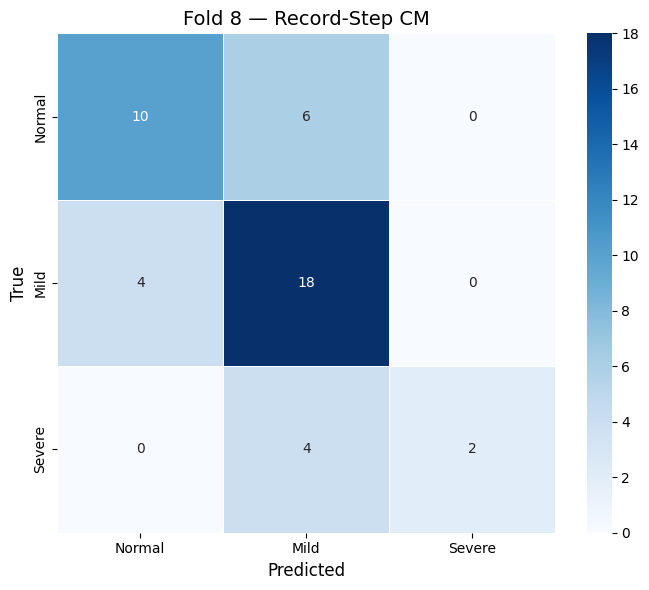


FOLD 9 / 10
  Validation quality: RELIABLE
    Normal: 23 step-units, 69 windows
    Mild: 18 step-units, 54 windows
    Severe: 10 step-units, 30 windows

TRAINING FROM SCRATCH
  Class weights (manual override): {0: 0.9, 1: 1.1, 2: 2.3}
  Early stopping monitor: val_record_step_balanced_accuracy
  Label smoothing: 0.02
Epoch 1/100
619/623 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4451 - loss: 1.3320  val_record_step_balanced_accuracy: 0.4551
623/623 ━━━━━━━━━━━━━━━━━━━━ 18s 14ms/step - accuracy: 0.4635 - loss: 1.2970 - val_accuracy: 0.4967 - val_loss: 1.0562 - val_record_step_balanced_accuracy: 0.4551 - learning_rate: 0.0010
Epoch 2/100
618/623 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5074 - loss: 1.2251  val_record_step_balanced_accuracy: 0.5066
623/623 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.5261 - loss: 1.2055 - val_accuracy: 0.4837 - val_loss: 1.0786 - val_record_step_balanced_accuracy: 0.5066 - learning_rate: 0.0010
Epoch 3/100
620/623 ━━━━━━━━━━━━━━━━━━━━ 0

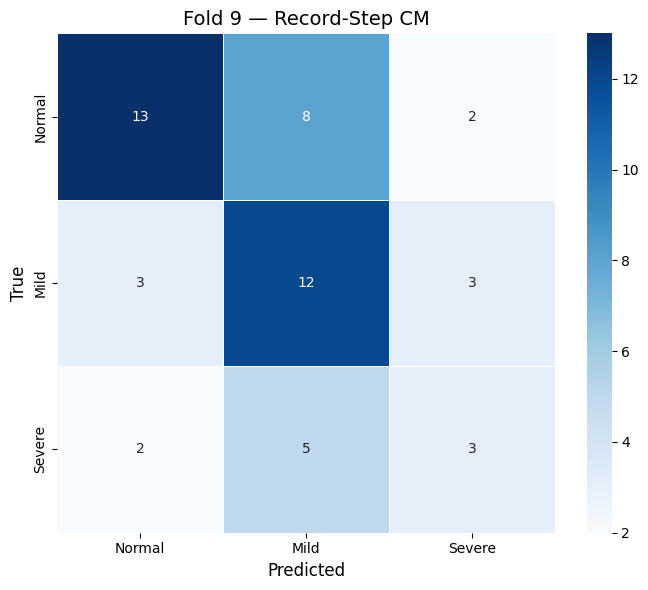


FOLD 10 / 10
  Validation quality: RELIABLE
    Normal: 24 step-units, 72 windows
    Mild: 17 step-units, 51 windows
    Severe: 5 step-units, 15 windows

TRAINING FROM SCRATCH
  Class weights (manual override): {0: 0.9, 1: 1.1, 2: 2.3}
  Early stopping monitor: val_record_step_balanced_accuracy
  Label smoothing: 0.02
Epoch 1/100
630/630 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.3587 - loss: 1.3730  val_record_step_balanced_accuracy: 0.4714
630/630 ━━━━━━━━━━━━━━━━━━━━ 16s 13ms/step - accuracy: 0.4246 - loss: 1.3157 - val_accuracy: 0.5725 - val_loss: 0.9672 - val_record_step_balanced_accuracy: 0.4714 - learning_rate: 0.0010
Epoch 2/100
630/630 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.4771 - loss: 1.2697  val_record_step_balanced_accuracy: 0.5049
630/630 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.4905 - loss: 1.2510 - val_accuracy: 0.6159 - val_loss: 0.8978 - val_record_step_balanced_accuracy: 0.5049 - learning_rate: 0.0010
Epoch 3/100
627/630 ━━━━━━━━━━━━━━━━━━━━ 0s 

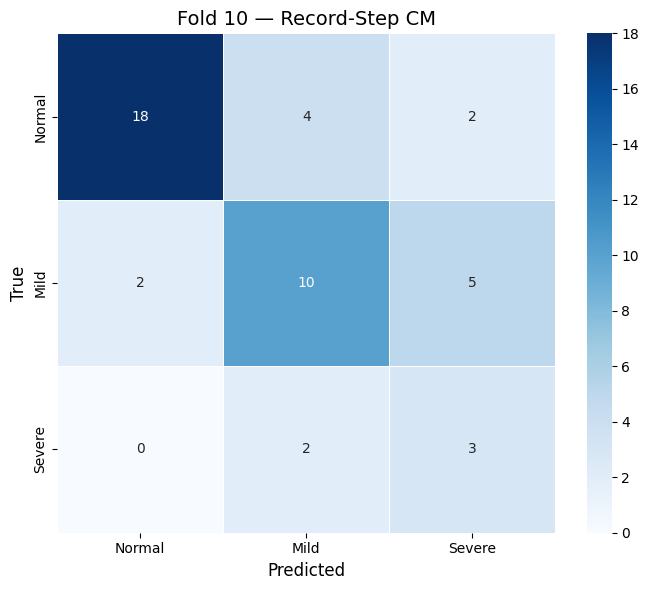

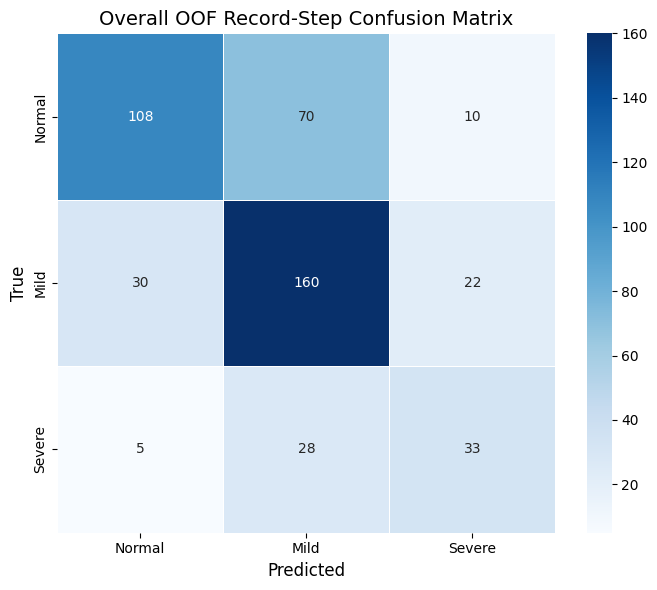

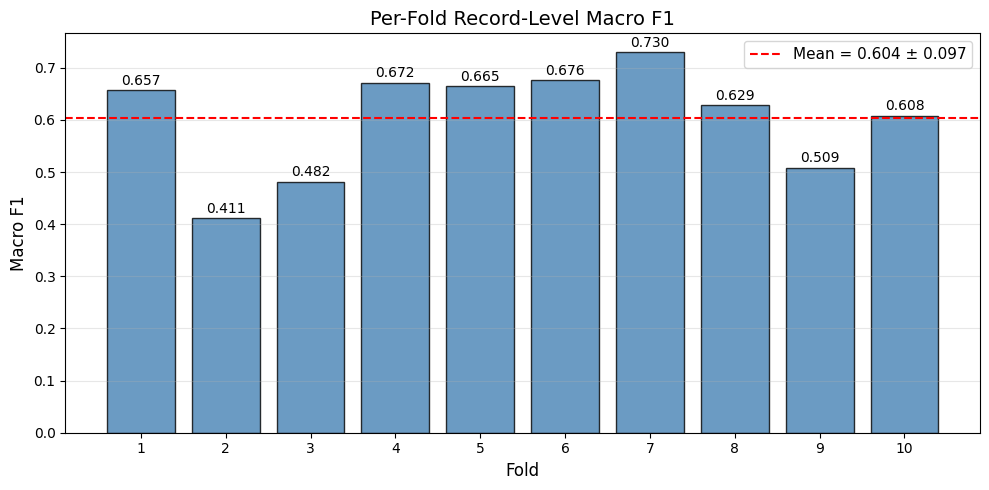

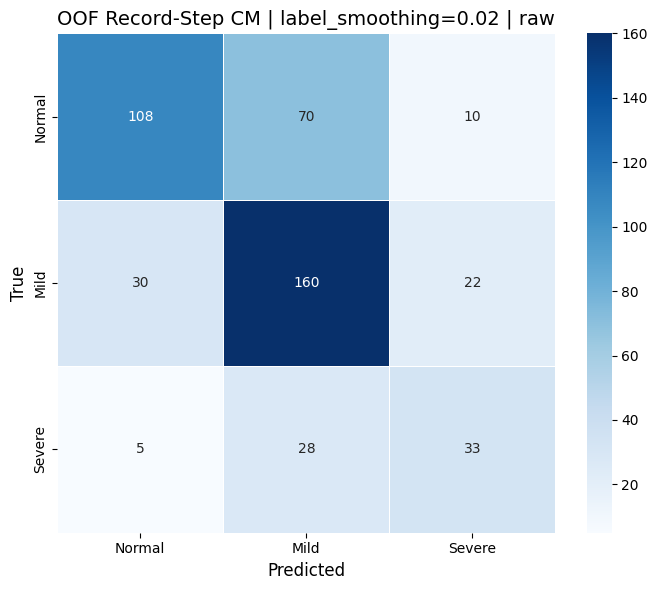

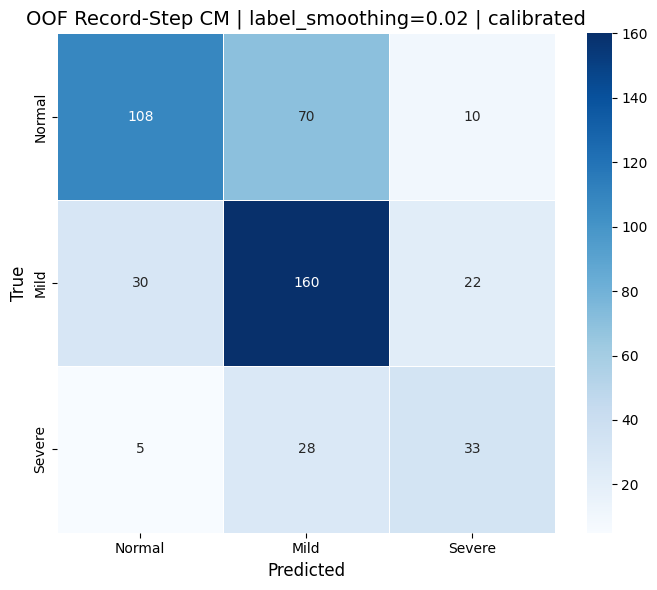


Run complete:
  Label smoothing:          0.02
  Raw OOF balanced acc:     0.6097
  Calibrated OOF bal acc:   0.6097
  Best OOF Severe boost:    0.00
  Results saved to:         C:\Users\ZEYNEP\OneDrive\Desktop\CTG_Dissertation\src\Transfer_Learning\outputs\step23_softmax_tenfold_tuning\cw_0p9_1p1_2p3\ls_0p02

Running tenfold CV for label_smoothing=0.05
Output directory: C:\Users\ZEYNEP\OneDrive\Desktop\CTG_Dissertation\src\Transfer_Learning\outputs\step23_softmax_tenfold_tuning\cw_0p9_1p1_2p3\ls_0p05
Computing engineered features from cleaned FHR windows...
  Engineered feature matrix: (1398, 10)

Generating 10-fold CV with requested >= 10 Severe step-units/fold...
  Total Severe step-units: 66, 10 folds -> max ~6/fold
  Found valid split at attempt 8 (seed=49, StratifiedGroupKFold)
    Severe step-units per val fold: [7, 7, 7, 8, 5, 6, 5, 6, 10, 5]
  Effective reliability threshold: 5 Severe step-units/fold

FOLD 1 / 10
  Validation quality: RELIABLE
    Normal: 17 step-units, 51 wi

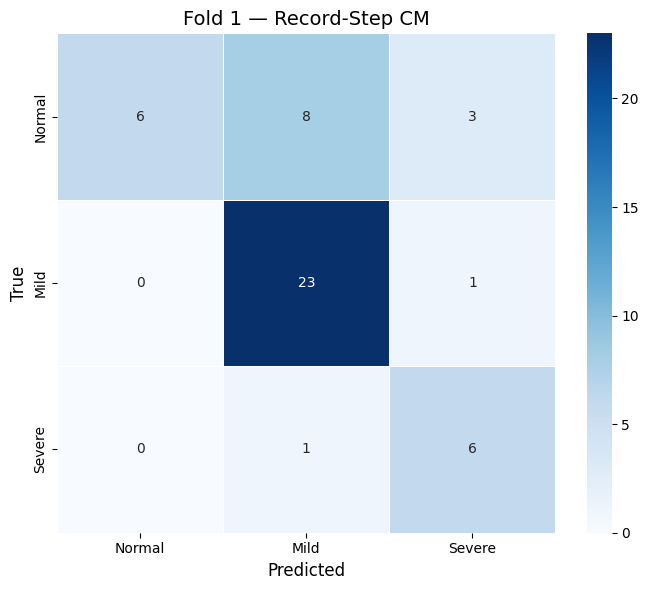


FOLD 2 / 10
  Validation quality: RELIABLE
    Normal: 26 step-units, 78 windows
    Mild: 19 step-units, 57 windows
    Severe: 7 step-units, 21 windows

TRAINING FROM SCRATCH
  Class weights (manual override): {0: 0.9, 1: 1.1, 2: 2.3}
  Early stopping monitor: val_record_step_balanced_accuracy
  Label smoothing: 0.05
Epoch 1/100
618/621 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.4506 - loss: 1.2891  val_record_step_balanced_accuracy: 0.3306
621/621 ━━━━━━━━━━━━━━━━━━━━ 15s 12ms/step - accuracy: 0.4517 - loss: 1.3036 - val_accuracy: 0.4423 - val_loss: 1.0816 - val_record_step_balanced_accuracy: 0.3306 - learning_rate: 0.0010
Epoch 2/100
617/621 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5103 - loss: 1.2180  val_record_step_balanced_accuracy: 0.3657
621/621 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.4952 - loss: 1.2501 - val_accuracy: 0.4744 - val_loss: 1.0742 - val_record_step_balanced_accuracy: 0.3657 - learning_rate: 0.0010
Epoch 3/100
621/621 ━━━━━━━━━━━━━━━━━━━━ 0s 

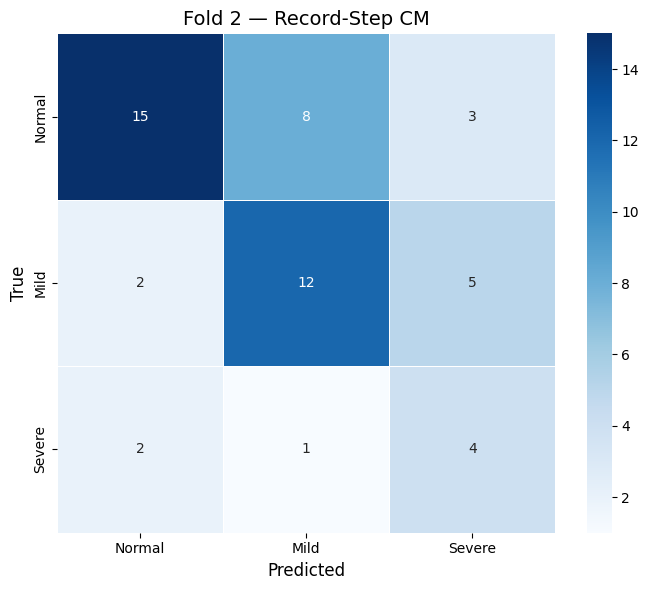


FOLD 3 / 10
  Validation quality: RELIABLE
    Normal: 16 step-units, 48 windows
    Mild: 19 step-units, 57 windows
    Severe: 7 step-units, 21 windows

TRAINING FROM SCRATCH
  Class weights (manual override): {0: 0.9, 1: 1.1, 2: 2.3}
  Early stopping monitor: val_record_step_balanced_accuracy
  Label smoothing: 0.05
Epoch 1/100
632/636 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.4026 - loss: 1.3413  val_record_step_balanced_accuracy: 0.3864
636/636 ━━━━━━━━━━━━━━━━━━━━ 16s 12ms/step - accuracy: 0.4379 - loss: 1.3010 - val_accuracy: 0.4603 - val_loss: 1.0597 - val_record_step_balanced_accuracy: 0.3864 - learning_rate: 0.0010
Epoch 2/100
630/636 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.4841 - loss: 1.2736  val_record_step_balanced_accuracy: 0.3629
636/636 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.4945 - loss: 1.2411 - val_accuracy: 0.5159 - val_loss: 1.0103 - val_record_step_balanced_accuracy: 0.3629 - learning_rate: 0.0010
Epoch 3/100
635/636 ━━━━━━━━━━━━━━━━━━━━ 0s 9

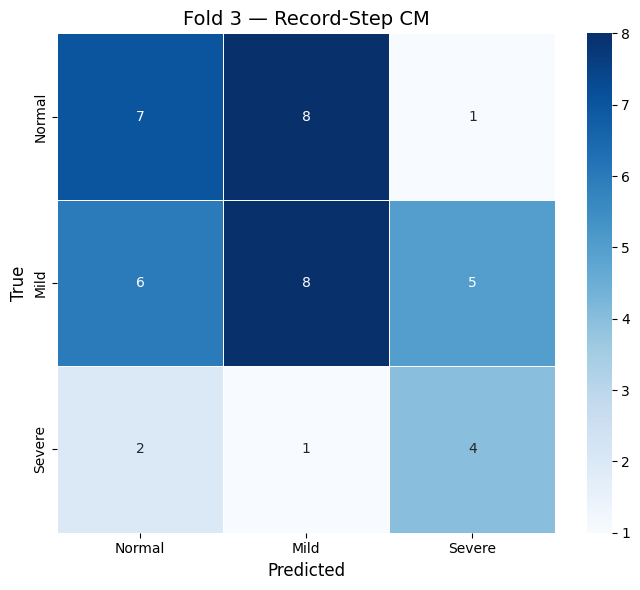


FOLD 4 / 10
  Validation quality: RELIABLE
    Normal: 11 step-units, 33 windows
    Mild: 26 step-units, 78 windows
    Severe: 8 step-units, 24 windows

TRAINING FROM SCRATCH
  Class weights (manual override): {0: 0.9, 1: 1.1, 2: 2.3}
  Early stopping monitor: val_record_step_balanced_accuracy
  Label smoothing: 0.05
Epoch 1/100
627/632 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.4416 - loss: 1.2768  val_record_step_balanced_accuracy: 0.5373
632/632 ━━━━━━━━━━━━━━━━━━━━ 16s 14ms/step - accuracy: 0.4695 - loss: 1.2843 - val_accuracy: 0.5333 - val_loss: 1.0332 - val_record_step_balanced_accuracy: 0.5373 - learning_rate: 0.0010
Epoch 2/100
631/632 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4915 - loss: 1.2030  val_record_step_balanced_accuracy: 0.6029
632/632 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - accuracy: 0.4893 - loss: 1.2325 - val_accuracy: 0.5556 - val_loss: 0.9736 - val_record_step_balanced_accuracy: 0.6029 - learning_rate: 0.0010
Epoch 3/100
630/632 ━━━━━━━━━━━━━━━━━━━━ 0s

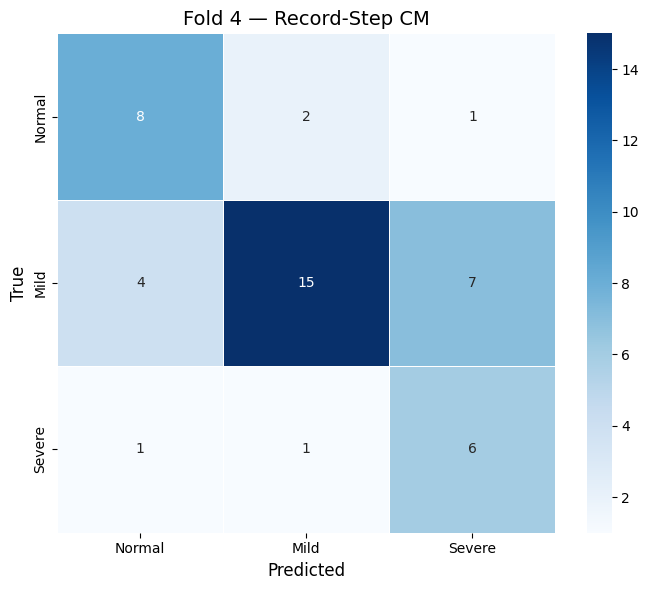


FOLD 5 / 10
  Validation quality: RELIABLE
    Normal: 16 step-units, 48 windows
    Mild: 21 step-units, 63 windows
    Severe: 5 step-units, 15 windows

TRAINING FROM SCRATCH
  Class weights (manual override): {0: 0.9, 1: 1.1, 2: 2.3}
  Early stopping monitor: val_record_step_balanced_accuracy
  Label smoothing: 0.05
Epoch 1/100
631/636 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.3887 - loss: 1.3402  val_record_step_balanced_accuracy: 0.3998
636/636 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - accuracy: 0.4371 - loss: 1.2925 - val_accuracy: 0.5000 - val_loss: 0.9888 - val_record_step_balanced_accuracy: 0.3998 - learning_rate: 0.0010
Epoch 2/100
631/636 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5213 - loss: 1.2814  val_record_step_balanced_accuracy: 0.5321
636/636 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.5283 - loss: 1.2362 - val_accuracy: 0.5079 - val_loss: 0.9642 - val_record_step_balanced_accuracy: 0.5321 - learning_rate: 0.0010
Epoch 3/100
633/636 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/

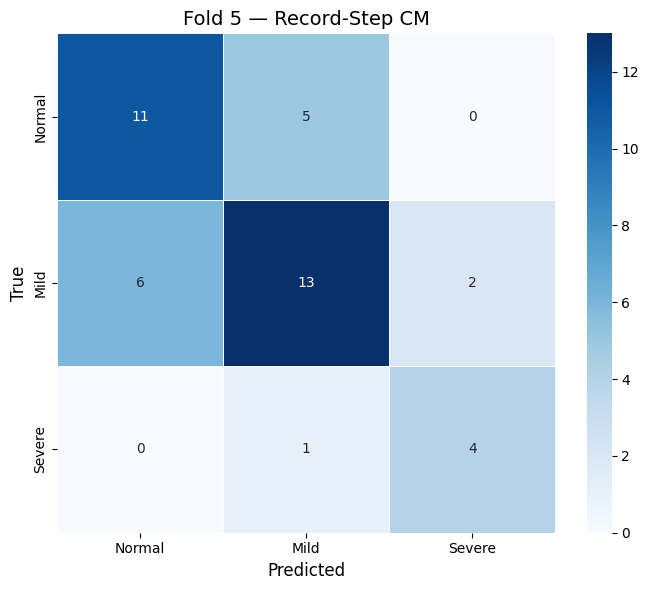


FOLD 6 / 10
  Validation quality: RELIABLE
    Normal: 24 step-units, 72 windows
    Mild: 20 step-units, 60 windows
    Severe: 6 step-units, 18 windows

TRAINING FROM SCRATCH
  Class weights (manual override): {0: 0.9, 1: 1.1, 2: 2.3}
  Early stopping monitor: val_record_step_balanced_accuracy
  Label smoothing: 0.05
Epoch 1/100
622/624 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4350 - loss: 1.3516  val_record_step_balanced_accuracy: 0.3917
624/624 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - accuracy: 0.4439 - loss: 1.3116 - val_accuracy: 0.4867 - val_loss: 1.0630 - val_record_step_balanced_accuracy: 0.3917 - learning_rate: 0.0010
Epoch 2/100
624/624 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4742 - loss: 1.2492  val_record_step_balanced_accuracy: 0.4250
624/624 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.4832 - loss: 1.2423 - val_accuracy: 0.4800 - val_loss: 1.0026 - val_record_step_balanced_accuracy: 0.4250 - learning_rate: 0.0010
Epoch 3/100
619/624 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/

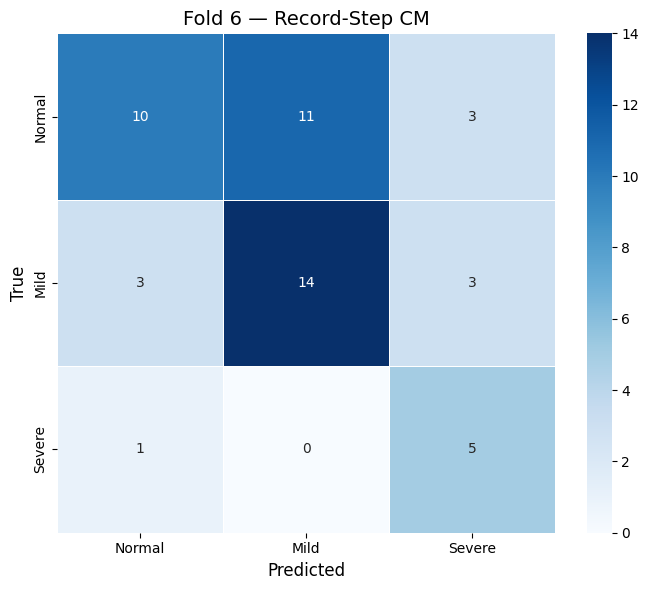


FOLD 7 / 10
  Validation quality: RELIABLE
    Normal: 15 step-units, 45 windows
    Mild: 26 step-units, 78 windows
    Severe: 5 step-units, 15 windows

TRAINING FROM SCRATCH
  Class weights (manual override): {0: 0.9, 1: 1.1, 2: 2.3}
  Early stopping monitor: val_record_step_balanced_accuracy
  Label smoothing: 0.05
Epoch 1/100
624/630 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.3842 - loss: 1.3812  val_record_step_balanced_accuracy: 0.5419
630/630 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - accuracy: 0.4397 - loss: 1.3011 - val_accuracy: 0.5217 - val_loss: 1.0013 - val_record_step_balanced_accuracy: 0.5419 - learning_rate: 0.0010
Epoch 2/100
626/630 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4866 - loss: 1.2765  val_record_step_balanced_accuracy: 0.4530
630/630 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.4968 - loss: 1.2433 - val_accuracy: 0.5290 - val_loss: 0.9922 - val_record_step_balanced_accuracy: 0.4530 - learning_rate: 0.0010
Epoch 3/100
622/630 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/

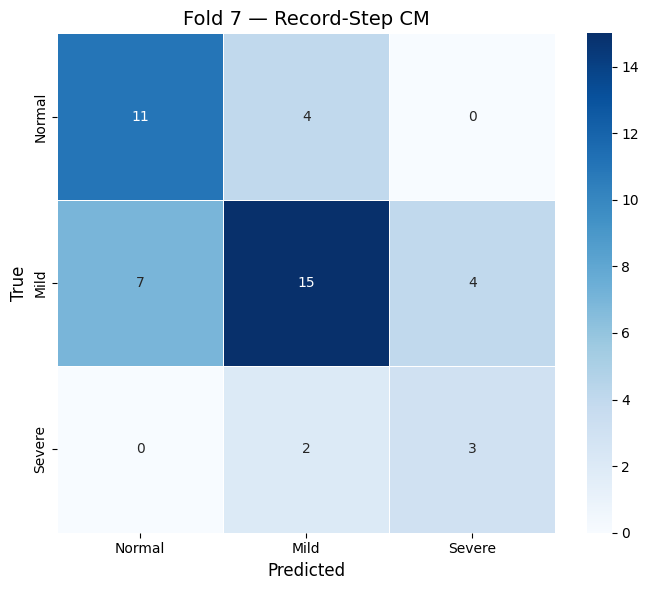


FOLD 8 / 10
  Validation quality: RELIABLE
    Normal: 16 step-units, 48 windows
    Mild: 22 step-units, 66 windows
    Severe: 6 step-units, 18 windows

TRAINING FROM SCRATCH
  Class weights (manual override): {0: 0.9, 1: 1.1, 2: 2.3}
  Early stopping monitor: val_record_step_balanced_accuracy
  Label smoothing: 0.05
Epoch 1/100
628/633 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4427 - loss: 1.3385  val_record_step_balanced_accuracy: 0.4148
633/633 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - accuracy: 0.4573 - loss: 1.2975 - val_accuracy: 0.5455 - val_loss: 0.9810 - val_record_step_balanced_accuracy: 0.4148 - learning_rate: 0.0010
Epoch 2/100
631/633 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4951 - loss: 1.2535  val_record_step_balanced_accuracy: 0.5297
633/633 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.5087 - loss: 1.2365 - val_accuracy: 0.5682 - val_loss: 0.9867 - val_record_step_balanced_accuracy: 0.5297 - learning_rate: 0.0010
Epoch 3/100
632/633 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/

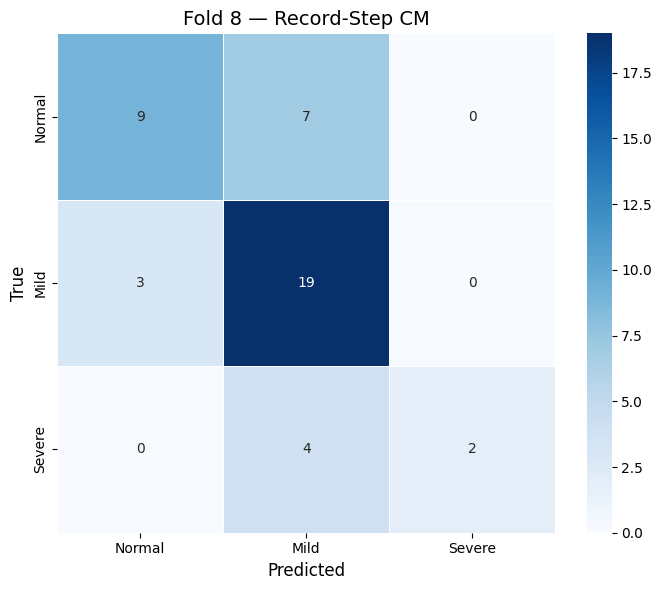


FOLD 9 / 10
  Validation quality: RELIABLE
    Normal: 23 step-units, 69 windows
    Mild: 18 step-units, 54 windows
    Severe: 10 step-units, 30 windows

TRAINING FROM SCRATCH
  Class weights (manual override): {0: 0.9, 1: 1.1, 2: 2.3}
  Early stopping monitor: val_record_step_balanced_accuracy
  Label smoothing: 0.05
Epoch 1/100
619/623 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4620 - loss: 1.2779  val_record_step_balanced_accuracy: 0.5483
623/623 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - accuracy: 0.4602 - loss: 1.2850 - val_accuracy: 0.4641 - val_loss: 1.0515 - val_record_step_balanced_accuracy: 0.5483 - learning_rate: 0.0010
Epoch 2/100
619/623 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4988 - loss: 1.2214  val_record_step_balanced_accuracy: 0.4591
623/623 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.4940 - loss: 1.2460 - val_accuracy: 0.4706 - val_loss: 1.0462 - val_record_step_balanced_accuracy: 0.4591 - learning_rate: 0.0010
Epoch 3/100
620/623 ━━━━━━━━━━━━━━━━━━━━ 0s 7m

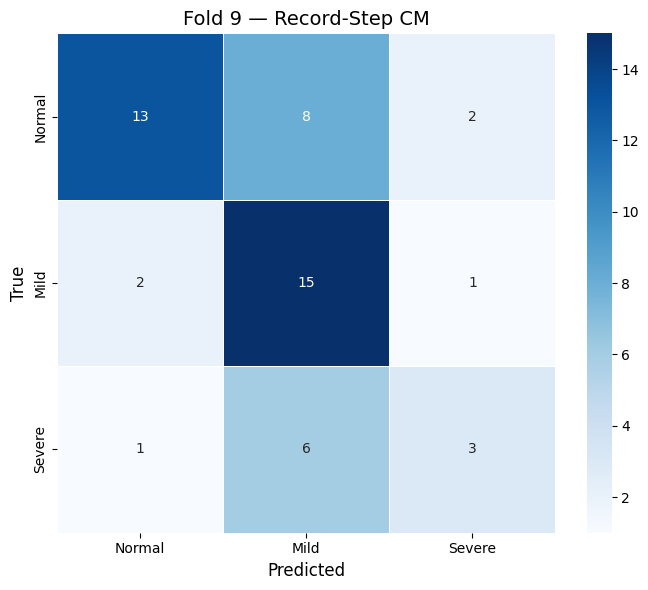


FOLD 10 / 10
  Validation quality: RELIABLE
    Normal: 24 step-units, 72 windows
    Mild: 17 step-units, 51 windows
    Severe: 5 step-units, 15 windows

TRAINING FROM SCRATCH
  Class weights (manual override): {0: 0.9, 1: 1.1, 2: 2.3}
  Early stopping monitor: val_record_step_balanced_accuracy
  Label smoothing: 0.05
Epoch 1/100
626/630 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4814 - loss: 1.2903  val_record_step_balanced_accuracy: 0.5078
630/630 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - accuracy: 0.4992 - loss: 1.2742 - val_accuracy: 0.5072 - val_loss: 0.9901 - val_record_step_balanced_accuracy: 0.5078 - learning_rate: 0.0010
Epoch 2/100
627/630 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4593 - loss: 1.2570  val_record_step_balanced_accuracy: 0.4882
630/630 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.4968 - loss: 1.2292 - val_accuracy: 0.5362 - val_loss: 0.9730 - val_record_step_balanced_accuracy: 0.4882 - learning_rate: 0.0010
Epoch 3/100
622/630 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms

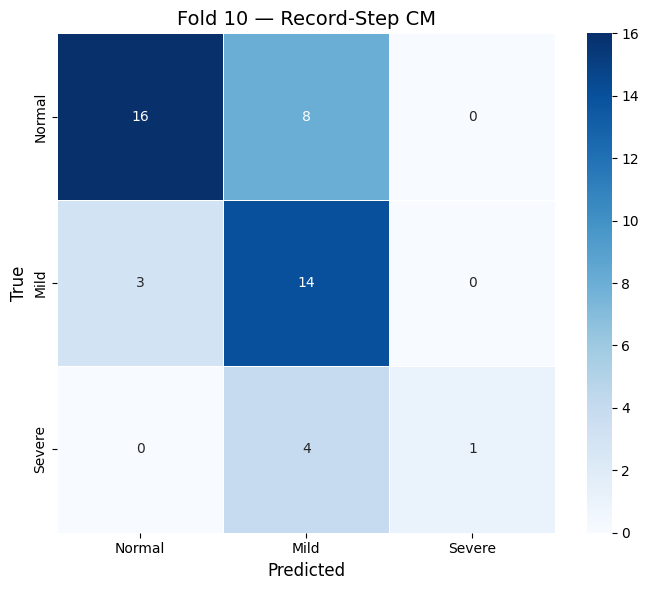

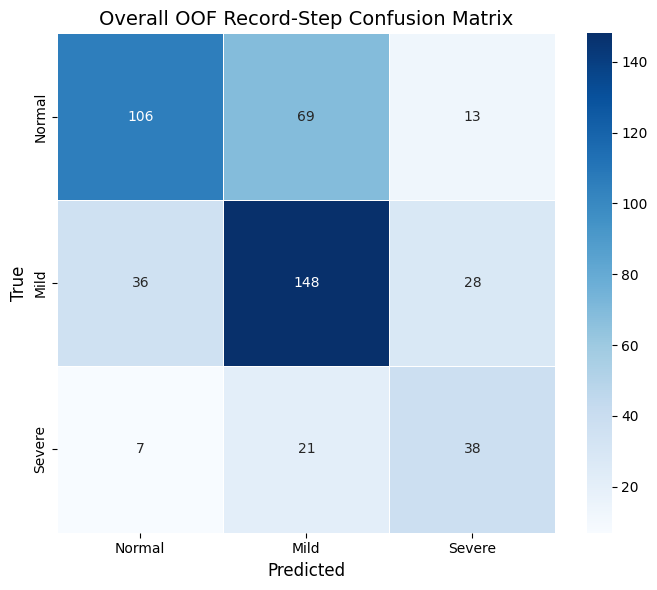

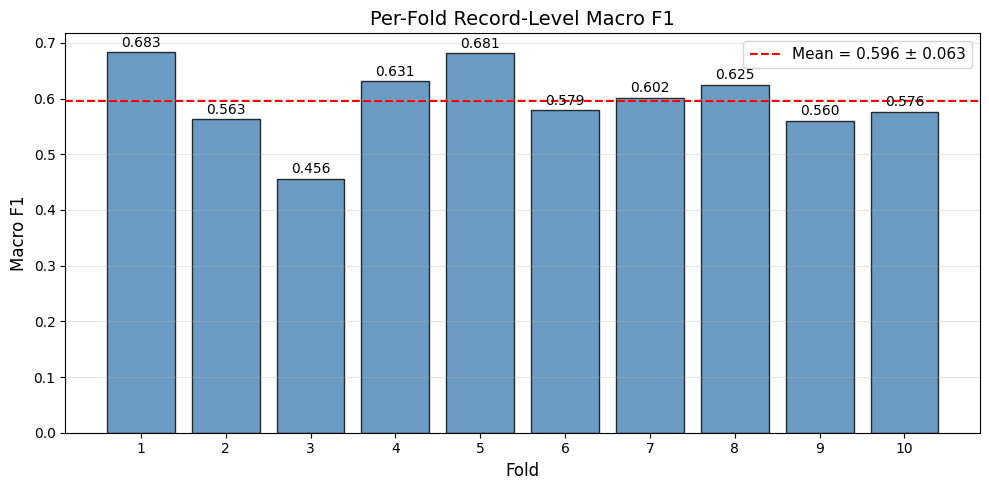

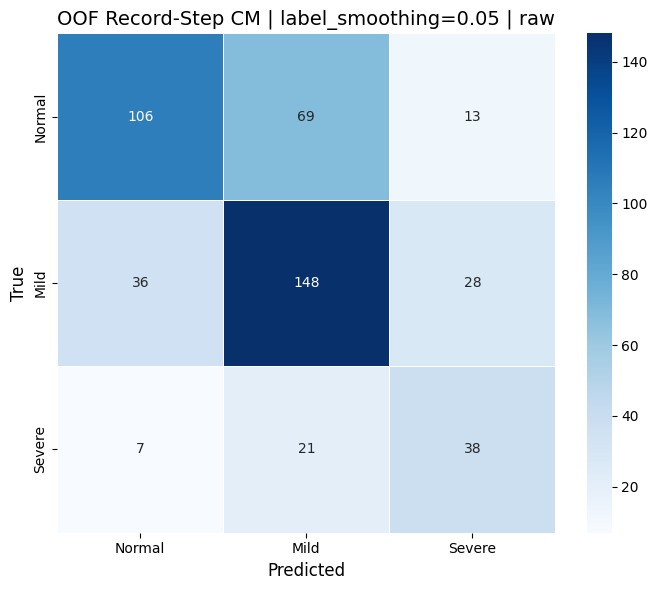

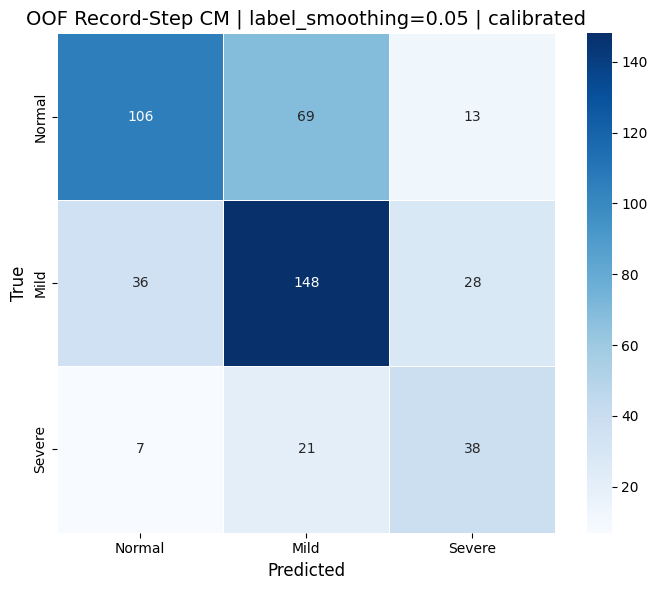


Run complete:
  Label smoothing:          0.05
  Raw OOF balanced acc:     0.6126
  Calibrated OOF bal acc:   0.6126
  Best OOF Severe boost:    0.00
  Results saved to:         C:\Users\ZEYNEP\OneDrive\Desktop\CTG_Dissertation\src\Transfer_Learning\outputs\step23_softmax_tenfold_tuning\cw_0p9_1p1_2p3\ls_0p05

##############################################################################
TENFOLD LABEL-SMOOTHING + OOF CALIBRATION SUMMARY
##############################################################################
 label_smoothing  best_oof_severe_boost  raw_balanced_accuracy  calibrated_balanced_accuracy  raw_macro_f1  calibrated_macro_f1
            0.05                    0.0               0.612567                      0.612567      0.603665             0.603665
            0.02                    0.0               0.609728                      0.609728      0.612412             0.612412
            0.00                    0.0               0.607455                      0.607455   

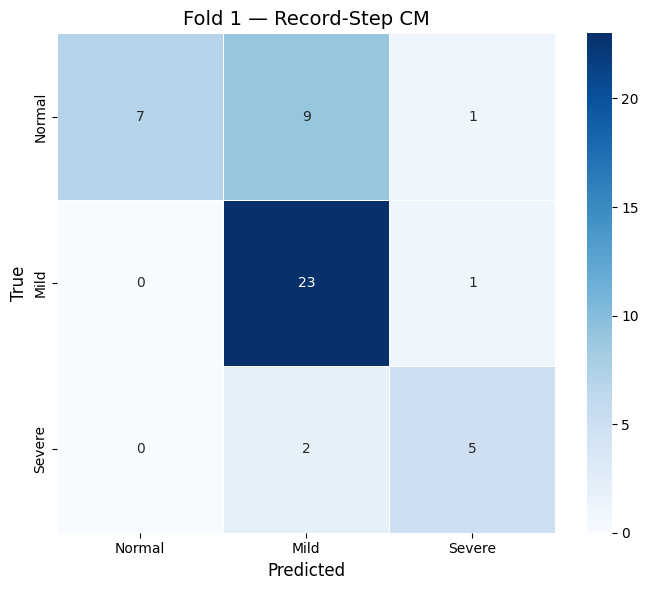


FOLD 2 / 10
  Validation quality: RELIABLE
    Normal: 26 step-units, 78 windows
    Mild: 19 step-units, 57 windows
    Severe: 7 step-units, 21 windows

TRAINING FROM SCRATCH
  Class weights (manual override): {0: 0.9, 1: 1.2, 2: 2.3}
  Early stopping monitor: val_record_step_balanced_accuracy
  Label smoothing: 0.00
Epoch 1/100
616/621 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4057 - loss: 1.3397  val_record_step_balanced_accuracy: 0.3479
621/621 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - accuracy: 0.4485 - loss: 1.3382 - val_accuracy: 0.3718 - val_loss: 1.0845 - val_record_step_balanced_accuracy: 0.3479 - learning_rate: 0.0010
Epoch 2/100
614/621 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5297 - loss: 1.2332  val_record_step_balanced_accuracy: 0.3482
621/621 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.5097 - loss: 1.2646 - val_accuracy: 0.3974 - val_loss: 1.0925 - val_record_step_balanced_accuracy: 0.3482 - learning_rate: 0.0010
Epoch 3/100
613/621 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/

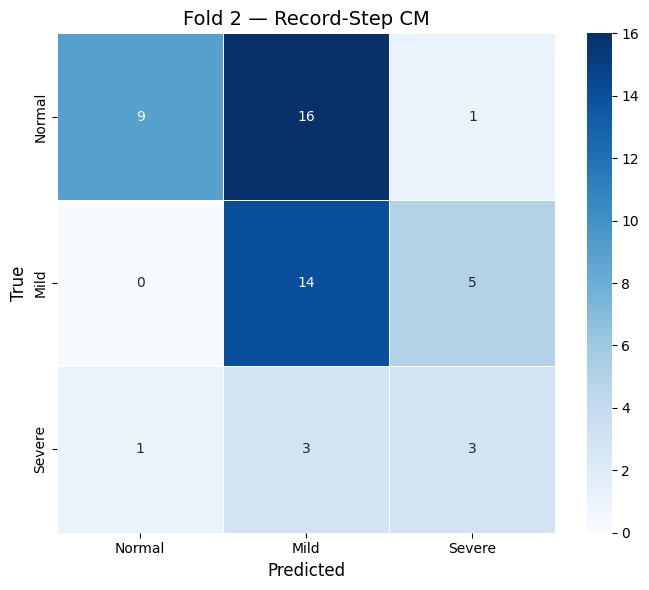


FOLD 3 / 10
  Validation quality: RELIABLE
    Normal: 16 step-units, 48 windows
    Mild: 19 step-units, 57 windows
    Severe: 7 step-units, 21 windows

TRAINING FROM SCRATCH
  Class weights (manual override): {0: 0.9, 1: 1.2, 2: 2.3}
  Early stopping monitor: val_record_step_balanced_accuracy
  Label smoothing: 0.00
Epoch 1/100
629/636 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4135 - loss: 1.3845  val_record_step_balanced_accuracy: 0.4057
636/636 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - accuracy: 0.4489 - loss: 1.3160 - val_accuracy: 0.4841 - val_loss: 1.0113 - val_record_step_balanced_accuracy: 0.4057 - learning_rate: 0.0010
Epoch 2/100
628/636 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4724 - loss: 1.3019  val_record_step_balanced_accuracy: 0.4834
636/636 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.5000 - loss: 1.2601 - val_accuracy: 0.4524 - val_loss: 1.0167 - val_record_step_balanced_accuracy: 0.4834 - learning_rate: 0.0010
Epoch 3/100
635/636 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/

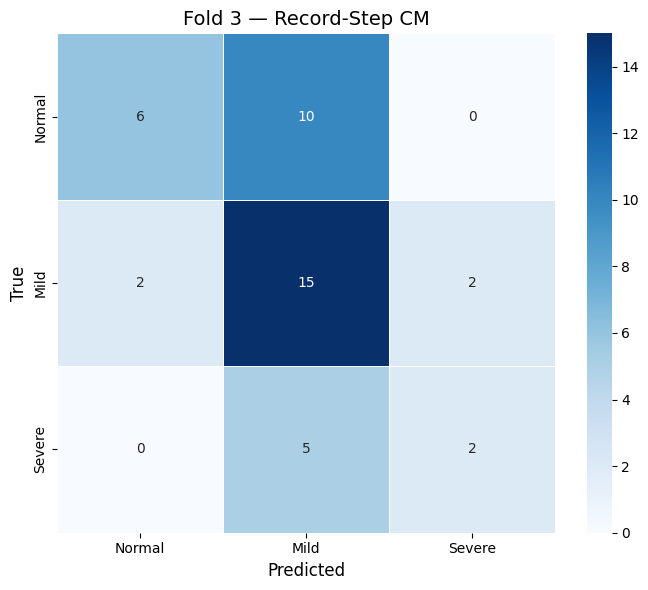


FOLD 4 / 10
  Validation quality: RELIABLE
    Normal: 11 step-units, 33 windows
    Mild: 26 step-units, 78 windows
    Severe: 8 step-units, 24 windows

TRAINING FROM SCRATCH
  Class weights (manual override): {0: 0.9, 1: 1.2, 2: 2.3}
  Early stopping monitor: val_record_step_balanced_accuracy
  Label smoothing: 0.00
Epoch 1/100
625/632 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4102 - loss: 1.3601  val_record_step_balanced_accuracy: 0.5661
632/632 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.4402 - loss: 1.3490 - val_accuracy: 0.4370 - val_loss: 1.0196 - val_record_step_balanced_accuracy: 0.5661 - learning_rate: 0.0010
Epoch 2/100
627/632 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5107 - loss: 1.2303  val_record_step_balanced_accuracy: 0.5213
632/632 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.5178 - loss: 1.2570 - val_accuracy: 0.5037 - val_loss: 0.9872 - val_record_step_balanced_accuracy: 0.5213 - learning_rate: 0.0010
Epoch 3/100
629/632 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms

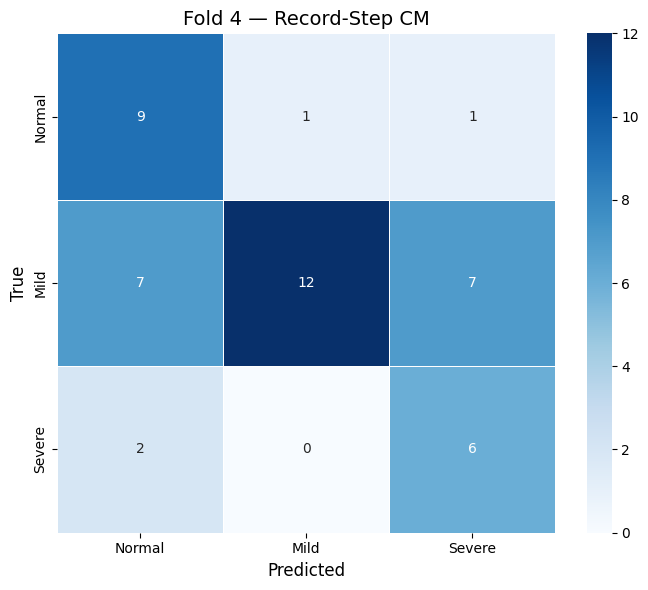


FOLD 5 / 10
  Validation quality: RELIABLE
    Normal: 16 step-units, 48 windows
    Mild: 21 step-units, 63 windows
    Severe: 5 step-units, 15 windows

TRAINING FROM SCRATCH
  Class weights (manual override): {0: 0.9, 1: 1.2, 2: 2.3}
  Early stopping monitor: val_record_step_balanced_accuracy
  Label smoothing: 0.00
Epoch 1/100
635/636 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.3897 - loss: 1.4024  val_record_step_balanced_accuracy: 0.4107
636/636 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - accuracy: 0.4340 - loss: 1.3532 - val_accuracy: 0.5635 - val_loss: 0.9553 - val_record_step_balanced_accuracy: 0.4107 - learning_rate: 0.0010
Epoch 2/100
632/636 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4864 - loss: 1.3270  val_record_step_balanced_accuracy: 0.5599
636/636 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.4929 - loss: 1.2975 - val_accuracy: 0.6111 - val_loss: 0.9335 - val_record_step_balanced_accuracy: 0.5599 - learning_rate: 0.0010
Epoch 3/100
628/636 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/

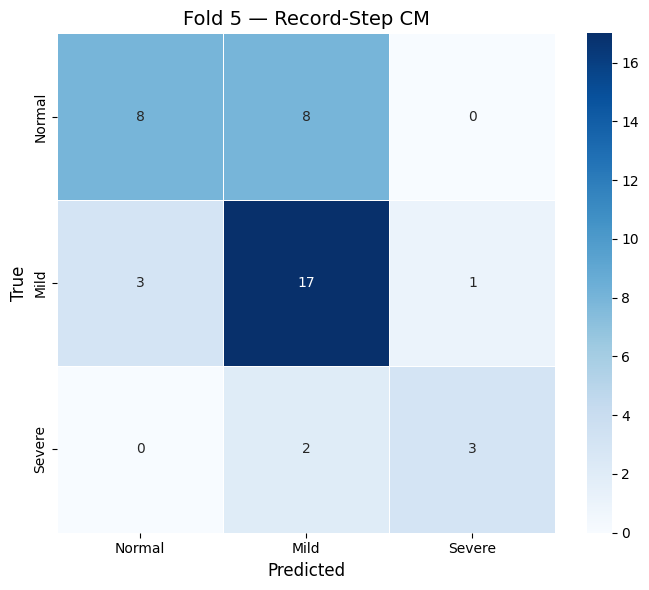


FOLD 6 / 10
  Validation quality: RELIABLE
    Normal: 24 step-units, 72 windows
    Mild: 20 step-units, 60 windows
    Severe: 6 step-units, 18 windows

TRAINING FROM SCRATCH
  Class weights (manual override): {0: 0.9, 1: 1.2, 2: 2.3}
  Early stopping monitor: val_record_step_balanced_accuracy
  Label smoothing: 0.00
Epoch 1/100
623/624 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.3928 - loss: 1.3824  val_record_step_balanced_accuracy: 0.3389
624/624 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - accuracy: 0.4479 - loss: 1.3209 - val_accuracy: 0.4200 - val_loss: 1.0447 - val_record_step_balanced_accuracy: 0.3389 - learning_rate: 0.0010
Epoch 2/100
616/624 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4700 - loss: 1.2737  val_record_step_balanced_accuracy: 0.4694
624/624 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.4808 - loss: 1.2680 - val_accuracy: 0.4400 - val_loss: 1.0309 - val_record_step_balanced_accuracy: 0.4694 - learning_rate: 0.0010
Epoch 3/100
617/624 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/

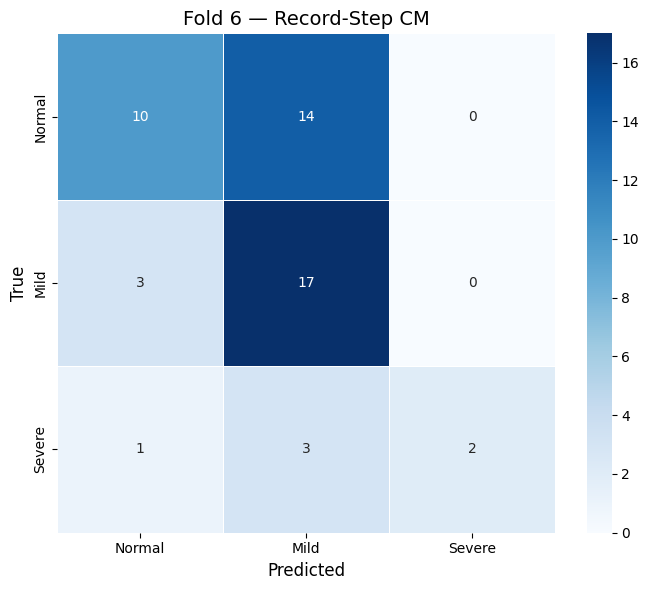


FOLD 7 / 10
  Validation quality: RELIABLE
    Normal: 15 step-units, 45 windows
    Mild: 26 step-units, 78 windows
    Severe: 5 step-units, 15 windows

TRAINING FROM SCRATCH
  Class weights (manual override): {0: 0.9, 1: 1.2, 2: 2.3}
  Early stopping monitor: val_record_step_balanced_accuracy
  Label smoothing: 0.00
Epoch 1/100
624/630 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4404 - loss: 1.3572  val_record_step_balanced_accuracy: 0.5513
630/630 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - accuracy: 0.4468 - loss: 1.3132 - val_accuracy: 0.5145 - val_loss: 0.9984 - val_record_step_balanced_accuracy: 0.5513 - learning_rate: 0.0010
Epoch 2/100
624/630 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5422 - loss: 1.2995  val_record_step_balanced_accuracy: 0.5769
630/630 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.5302 - loss: 1.2654 - val_accuracy: 0.5435 - val_loss: 0.9874 - val_record_step_balanced_accuracy: 0.5769 - learning_rate: 0.0010
Epoch 3/100
625/630 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/

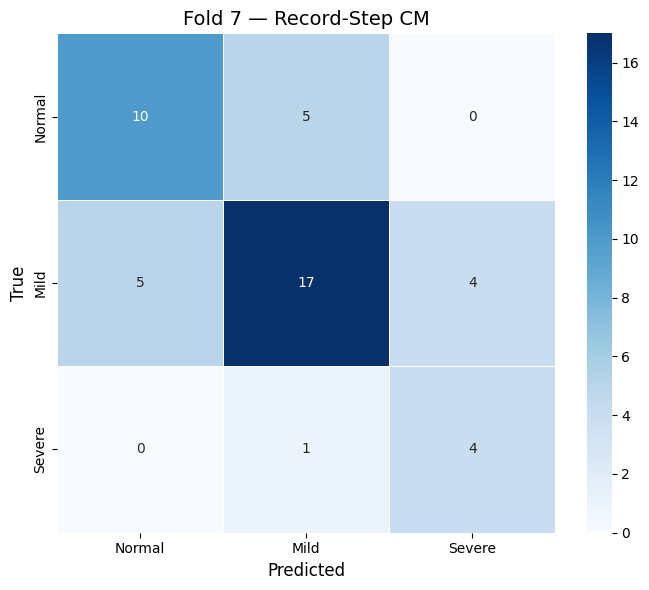


FOLD 8 / 10
  Validation quality: RELIABLE
    Normal: 16 step-units, 48 windows
    Mild: 22 step-units, 66 windows
    Severe: 6 step-units, 18 windows

TRAINING FROM SCRATCH
  Class weights (manual override): {0: 0.9, 1: 1.2, 2: 2.3}
  Early stopping monitor: val_record_step_balanced_accuracy
  Label smoothing: 0.00
Epoch 1/100
633/633 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4660 - loss: 1.3425  val_record_step_balanced_accuracy: 0.4533
633/633 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - accuracy: 0.4913 - loss: 1.3067 - val_accuracy: 0.4545 - val_loss: 0.9915 - val_record_step_balanced_accuracy: 0.4533 - learning_rate: 0.0010
Epoch 2/100
632/633 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5138 - loss: 1.3035  val_record_step_balanced_accuracy: 0.4779
633/633 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.5174 - loss: 1.2774 - val_accuracy: 0.5227 - val_loss: 0.9769 - val_record_step_balanced_accuracy: 0.4779 - learning_rate: 0.0010
Epoch 3/100
631/633 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/

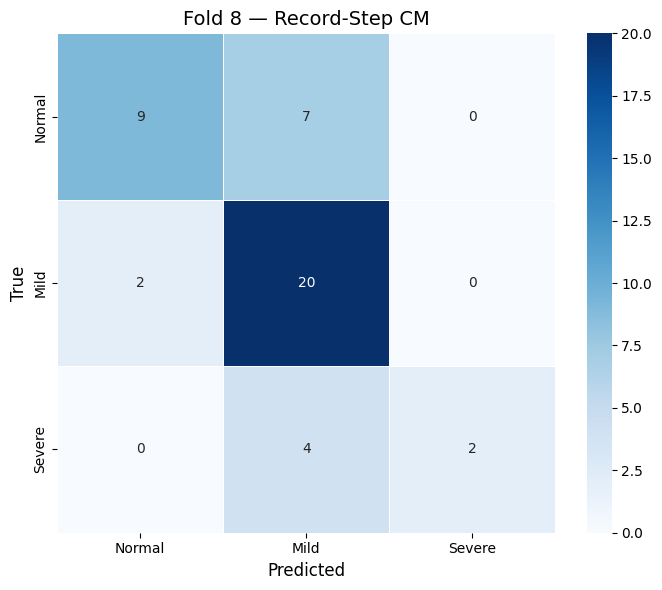


FOLD 9 / 10
  Validation quality: RELIABLE
    Normal: 23 step-units, 69 windows
    Mild: 18 step-units, 54 windows
    Severe: 10 step-units, 30 windows

TRAINING FROM SCRATCH
  Class weights (manual override): {0: 0.9, 1: 1.2, 2: 2.3}
  Early stopping monitor: val_record_step_balanced_accuracy
  Label smoothing: 0.00
Epoch 1/100
617/623 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4074 - loss: 1.3465  val_record_step_balanced_accuracy: 0.4689
623/623 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - accuracy: 0.4578 - loss: 1.3063 - val_accuracy: 0.5229 - val_loss: 1.0628 - val_record_step_balanced_accuracy: 0.4689 - learning_rate: 0.0010
Epoch 2/100
622/623 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5234 - loss: 1.2158  val_record_step_balanced_accuracy: 0.4258
623/623 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.5141 - loss: 1.2226 - val_accuracy: 0.4706 - val_loss: 1.0436 - val_record_step_balanced_accuracy: 0.4258 - learning_rate: 0.0010
Epoch 3/100
616/623 ━━━━━━━━━━━━━━━━━━━━ 0s 7

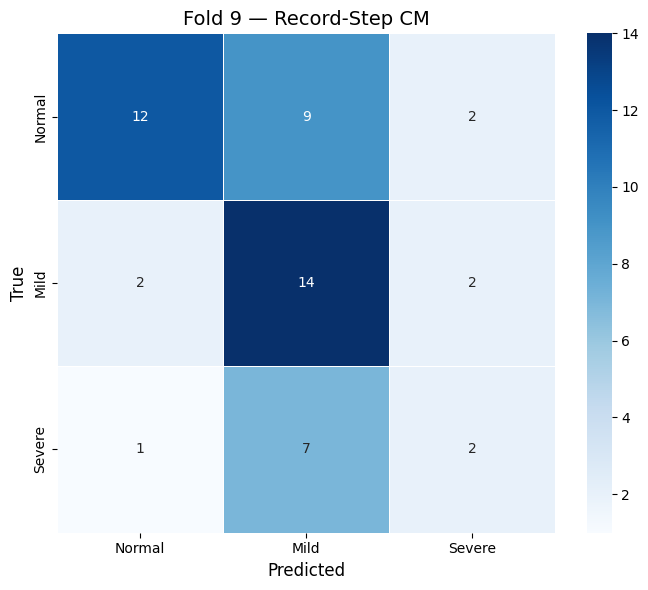


FOLD 10 / 10
  Validation quality: RELIABLE
    Normal: 24 step-units, 72 windows
    Mild: 17 step-units, 51 windows
    Severe: 5 step-units, 15 windows

TRAINING FROM SCRATCH
  Class weights (manual override): {0: 0.9, 1: 1.2, 2: 2.3}
  Early stopping monitor: val_record_step_balanced_accuracy
  Label smoothing: 0.00
Epoch 1/100
626/630 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.3853 - loss: 1.3594  val_record_step_balanced_accuracy: 0.4273
630/630 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - accuracy: 0.4468 - loss: 1.3341 - val_accuracy: 0.5072 - val_loss: 0.9830 - val_record_step_balanced_accuracy: 0.4273 - learning_rate: 0.0010
Epoch 2/100
627/630 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4930 - loss: 1.2856  val_record_step_balanced_accuracy: 0.4469
630/630 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.5000 - loss: 1.2758 - val_accuracy: 0.5072 - val_loss: 0.9540 - val_record_step_balanced_accuracy: 0.4469 - learning_rate: 0.0010
Epoch 3/100
626/630 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms

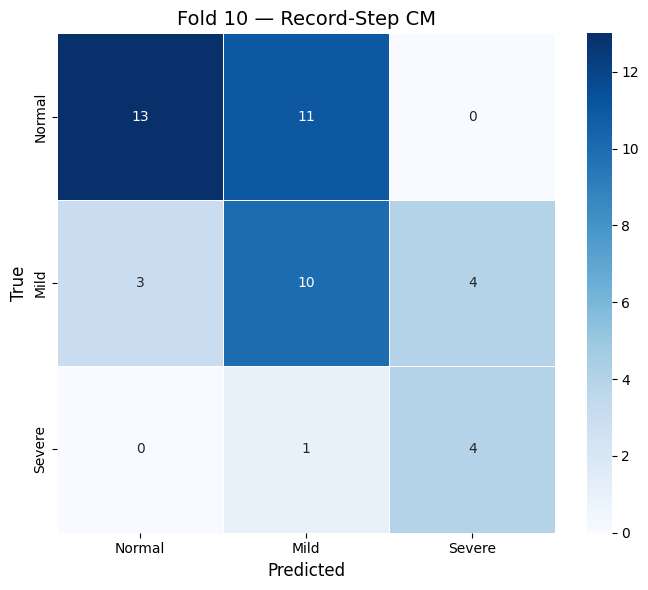

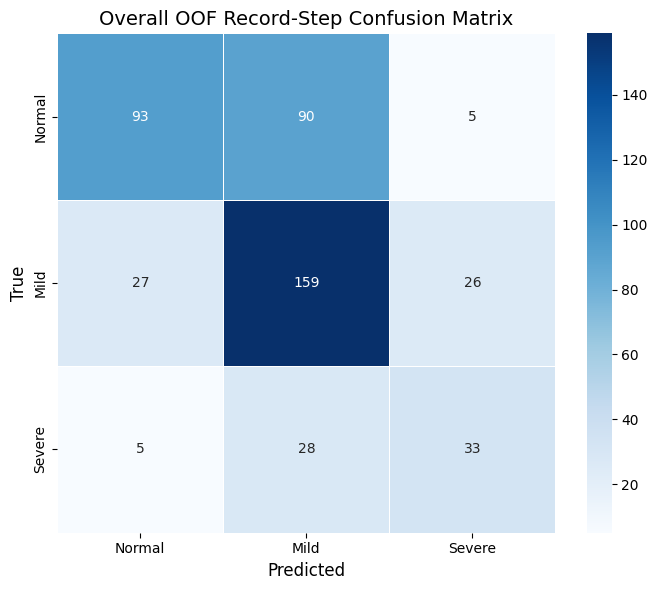

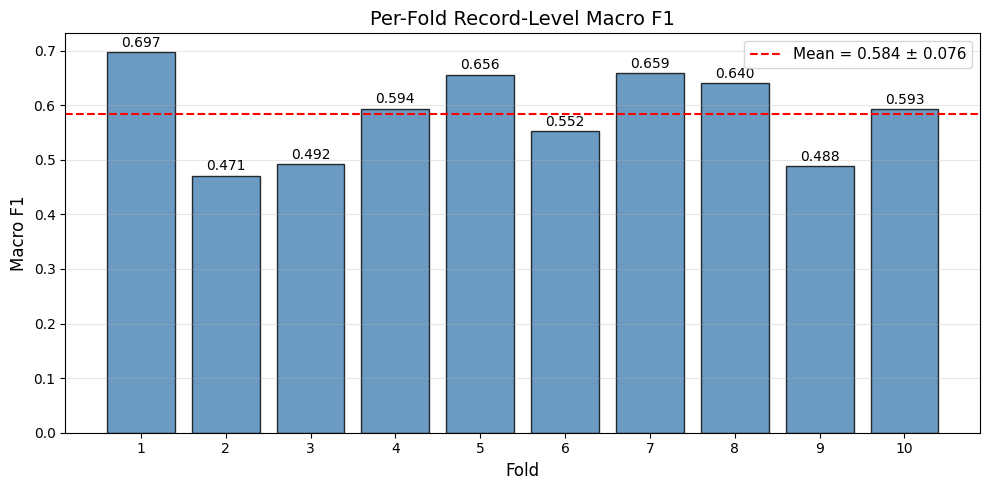

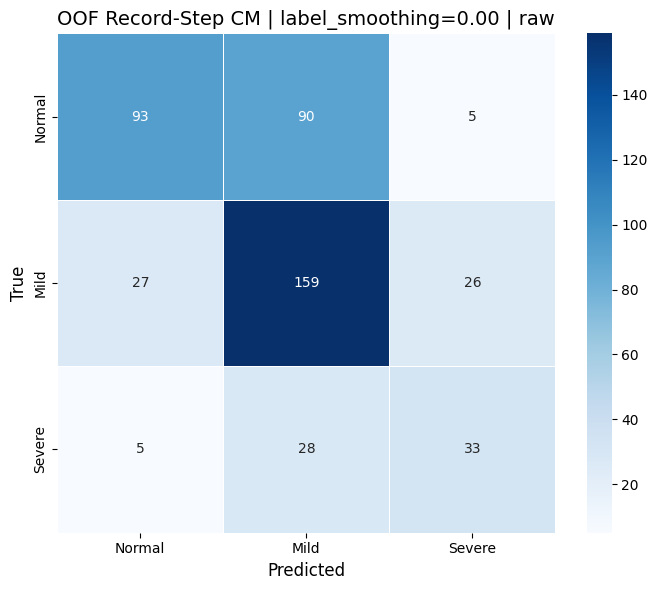

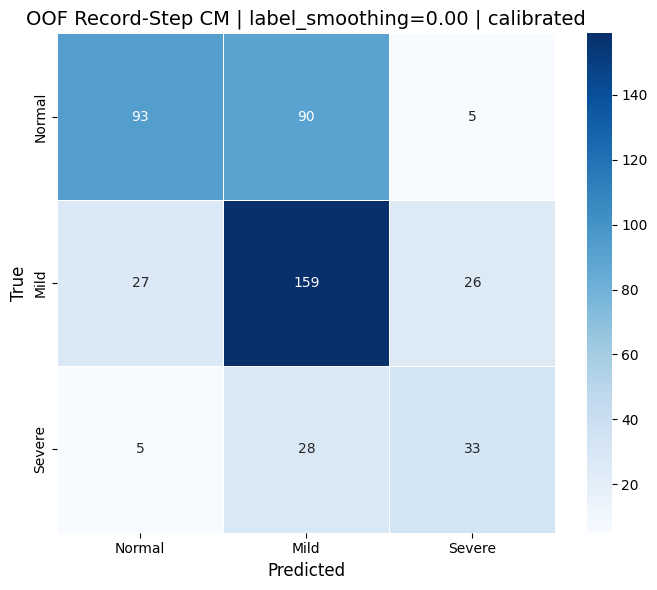


Run complete:
  Label smoothing:          0.00
  Raw OOF balanced acc:     0.5816
  Calibrated OOF bal acc:   0.5816
  Best OOF Severe boost:    0.00
  Results saved to:         C:\Users\ZEYNEP\OneDrive\Desktop\CTG_Dissertation\src\Transfer_Learning\outputs\step23_softmax_tenfold_tuning\cw_0p9_1p2_2p3\ls_0p00

Running tenfold CV for label_smoothing=0.02
Output directory: C:\Users\ZEYNEP\OneDrive\Desktop\CTG_Dissertation\src\Transfer_Learning\outputs\step23_softmax_tenfold_tuning\cw_0p9_1p2_2p3\ls_0p02
Computing engineered features from cleaned FHR windows...
  Engineered feature matrix: (1398, 10)

Generating 10-fold CV with requested >= 10 Severe step-units/fold...
  Total Severe step-units: 66, 10 folds -> max ~6/fold
  Found valid split at attempt 8 (seed=49, StratifiedGroupKFold)
    Severe step-units per val fold: [7, 7, 7, 8, 5, 6, 5, 6, 10, 5]
  Effective reliability threshold: 5 Severe step-units/fold

FOLD 1 / 10
  Validation quality: RELIABLE
    Normal: 17 step-units, 51 wi

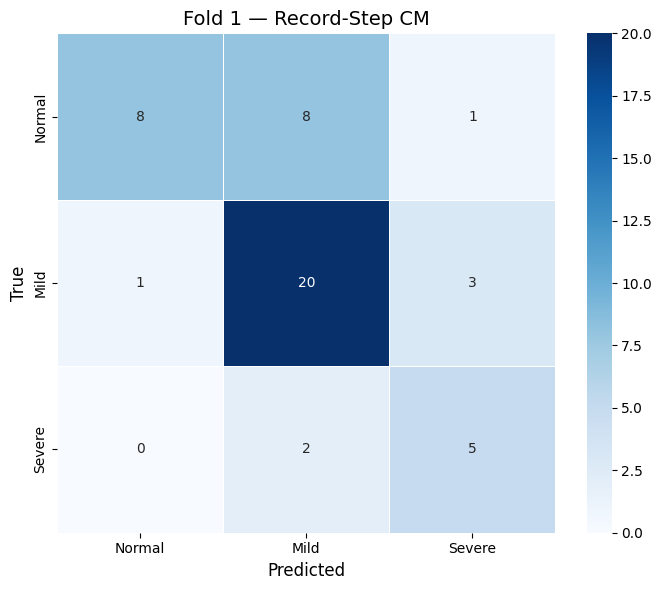


FOLD 2 / 10
  Validation quality: RELIABLE
    Normal: 26 step-units, 78 windows
    Mild: 19 step-units, 57 windows
    Severe: 7 step-units, 21 windows

TRAINING FROM SCRATCH
  Class weights (manual override): {0: 0.9, 1: 1.2, 2: 2.3}
  Early stopping monitor: val_record_step_balanced_accuracy
  Label smoothing: 0.02
Epoch 1/100
614/621 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4275 - loss: 1.3801  val_record_step_balanced_accuracy: 0.3621
621/621 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.4662 - loss: 1.3585 - val_accuracy: 0.3718 - val_loss: 1.0645 - val_record_step_balanced_accuracy: 0.3621 - learning_rate: 0.0010
Epoch 2/100
616/621 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5021 - loss: 1.2483  val_record_step_balanced_accuracy: 0.3735
621/621 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.4839 - loss: 1.2845 - val_accuracy: 0.4423 - val_loss: 1.0402 - val_record_step_balanced_accuracy: 0.3735 - learning_rate: 0.0010
Epoch 3/100
615/621 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/

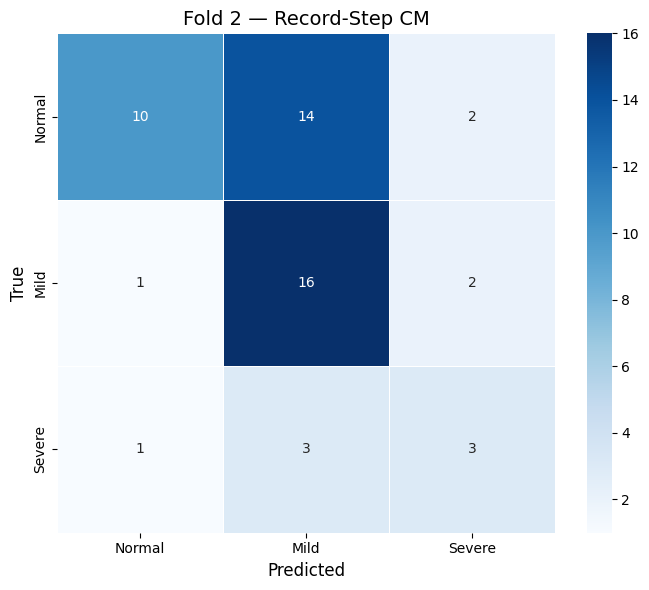


FOLD 3 / 10
  Validation quality: RELIABLE
    Normal: 16 step-units, 48 windows
    Mild: 19 step-units, 57 windows
    Severe: 7 step-units, 21 windows

TRAINING FROM SCRATCH
  Class weights (manual override): {0: 0.9, 1: 1.2, 2: 2.3}
  Early stopping monitor: val_record_step_balanced_accuracy
  Label smoothing: 0.02
Epoch 1/100
631/636 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.3998 - loss: 1.3973  val_record_step_balanced_accuracy: 0.3914
636/636 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - accuracy: 0.4363 - loss: 1.3438 - val_accuracy: 0.5079 - val_loss: 1.0357 - val_record_step_balanced_accuracy: 0.3914 - learning_rate: 0.0010
Epoch 2/100
635/636 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4884 - loss: 1.2661  val_record_step_balanced_accuracy: 0.4123
636/636 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.5000 - loss: 1.2403 - val_accuracy: 0.5000 - val_loss: 1.0426 - val_record_step_balanced_accuracy: 0.4123 - learning_rate: 0.0010
Epoch 3/100
631/636 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/

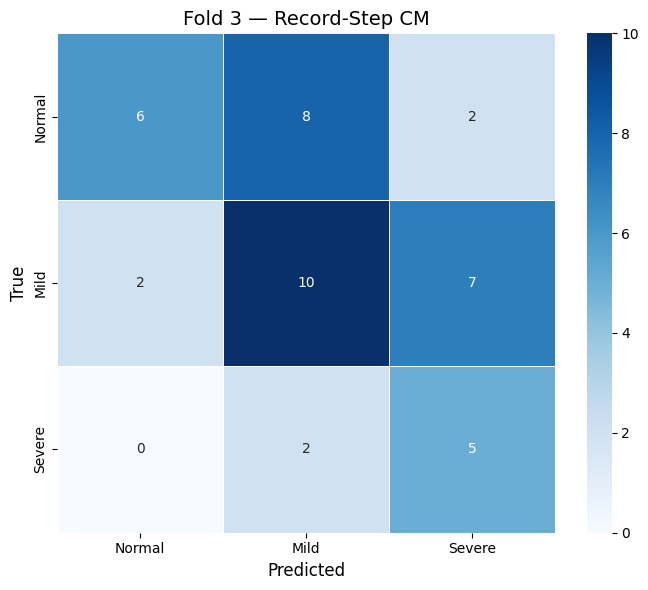


FOLD 4 / 10
  Validation quality: RELIABLE
    Normal: 11 step-units, 33 windows
    Mild: 26 step-units, 78 windows
    Severe: 8 step-units, 24 windows

TRAINING FROM SCRATCH
  Class weights (manual override): {0: 0.9, 1: 1.2, 2: 2.3}
  Early stopping monitor: val_record_step_balanced_accuracy
  Label smoothing: 0.02
Epoch 1/100
626/632 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4542 - loss: 1.3021  val_record_step_balanced_accuracy: 0.5775
632/632 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - accuracy: 0.4656 - loss: 1.3113 - val_accuracy: 0.6296 - val_loss: 0.9277 - val_record_step_balanced_accuracy: 0.5775 - learning_rate: 0.0010
Epoch 2/100
631/632 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5212 - loss: 1.2172  val_record_step_balanced_accuracy: 0.4513
632/632 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.4972 - loss: 1.2625 - val_accuracy: 0.5333 - val_loss: 0.9599 - val_record_step_balanced_accuracy: 0.4513 - learning_rate: 0.0010
Epoch 3/100
626/632 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms

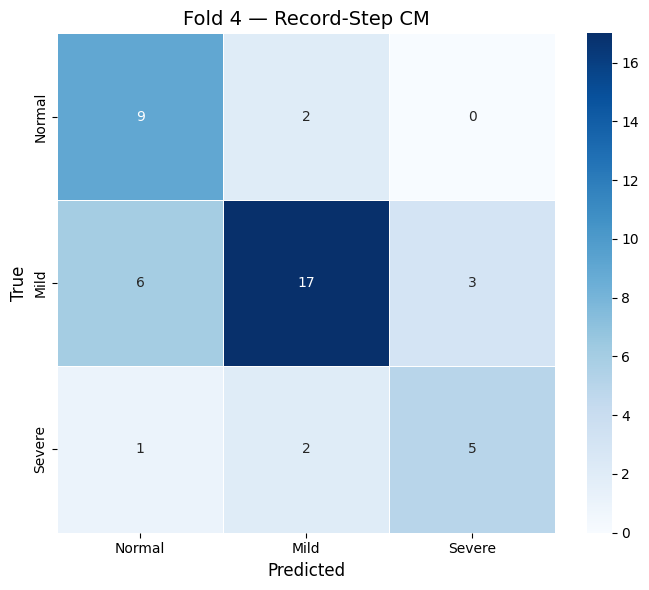


FOLD 5 / 10
  Validation quality: RELIABLE
    Normal: 16 step-units, 48 windows
    Mild: 21 step-units, 63 windows
    Severe: 5 step-units, 15 windows

TRAINING FROM SCRATCH
  Class weights (manual override): {0: 0.9, 1: 1.2, 2: 2.3}
  Early stopping monitor: val_record_step_balanced_accuracy
  Label smoothing: 0.02
Epoch 1/100
634/636 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.3878 - loss: 1.4153  val_record_step_balanced_accuracy: 0.4573
636/636 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - accuracy: 0.4269 - loss: 1.3543 - val_accuracy: 0.5556 - val_loss: 0.9647 - val_record_step_balanced_accuracy: 0.4573 - learning_rate: 0.0010
Epoch 2/100
629/636 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4969 - loss: 1.3166  val_record_step_balanced_accuracy: 0.4732
636/636 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.4906 - loss: 1.3002 - val_accuracy: 0.5635 - val_loss: 0.9752 - val_record_step_balanced_accuracy: 0.4732 - learning_rate: 0.0010
Epoch 3/100
636/636 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/

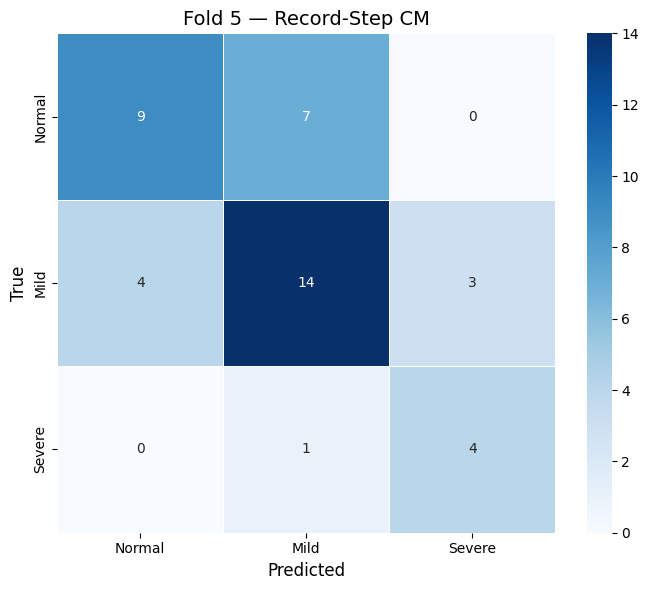


FOLD 6 / 10
  Validation quality: RELIABLE
    Normal: 24 step-units, 72 windows
    Mild: 20 step-units, 60 windows
    Severe: 6 step-units, 18 windows

TRAINING FROM SCRATCH
  Class weights (manual override): {0: 0.9, 1: 1.2, 2: 2.3}
  Early stopping monitor: val_record_step_balanced_accuracy
  Label smoothing: 0.02
Epoch 1/100
615/624 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4337 - loss: 1.3758  val_record_step_balanced_accuracy: 0.4028
624/624 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - accuracy: 0.4495 - loss: 1.3471 - val_accuracy: 0.4533 - val_loss: 1.0534 - val_record_step_balanced_accuracy: 0.4028 - learning_rate: 0.0010
Epoch 2/100
624/624 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4882 - loss: 1.3007  val_record_step_balanced_accuracy: 0.4083
624/624 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.4960 - loss: 1.2866 - val_accuracy: 0.4933 - val_loss: 1.0302 - val_record_step_balanced_accuracy: 0.4083 - learning_rate: 0.0010
Epoch 3/100
621/624 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms

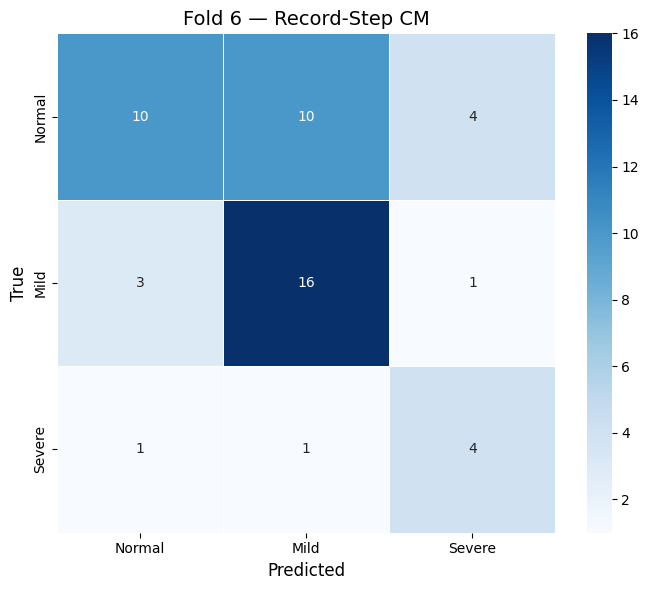


FOLD 7 / 10
  Validation quality: RELIABLE
    Normal: 15 step-units, 45 windows
    Mild: 26 step-units, 78 windows
    Severe: 5 step-units, 15 windows

TRAINING FROM SCRATCH
  Class weights (manual override): {0: 0.9, 1: 1.2, 2: 2.3}
  Early stopping monitor: val_record_step_balanced_accuracy
  Label smoothing: 0.02
Epoch 1/100
629/630 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.4109 - loss: 1.3960  val_record_step_balanced_accuracy: 0.3829
630/630 ━━━━━━━━━━━━━━━━━━━━ 34s 36ms/step - accuracy: 0.4302 - loss: 1.3505 - val_accuracy: 0.4928 - val_loss: 1.0141 - val_record_step_balanced_accuracy: 0.3829 - learning_rate: 0.0010
Epoch 2/100
630/630 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.4878 - loss: 1.3261  val_record_step_balanced_accuracy: 0.3547
630/630 ━━━━━━━━━━━━━━━━━━━━ 21s 34ms/step - accuracy: 0.5056 - loss: 1.2890 - val_accuracy: 0.5217 - val_loss: 1.0165 - val_record_step_balanced_accuracy: 0.3547 - learning_rate: 0.0010
Epoch 3/100
630/630 ━━━━━━━━━━━━━━━━━━━━ 0

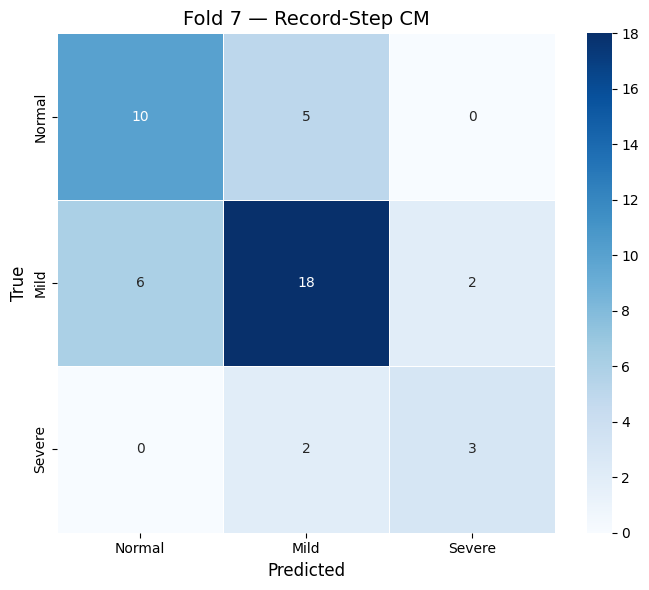


FOLD 8 / 10
  Validation quality: RELIABLE
    Normal: 16 step-units, 48 windows
    Mild: 22 step-units, 66 windows
    Severe: 6 step-units, 18 windows

TRAINING FROM SCRATCH
  Class weights (manual override): {0: 0.9, 1: 1.2, 2: 2.3}
  Early stopping monitor: val_record_step_balanced_accuracy
  Label smoothing: 0.02
Epoch 1/100
633/633 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.3989 - loss: 1.3704  val_record_step_balanced_accuracy: 0.3333
633/633 ━━━━━━━━━━━━━━━━━━━━ 44s 43ms/step - accuracy: 0.4052 - loss: 1.3217 - val_accuracy: 0.5152 - val_loss: 0.9665 - val_record_step_balanced_accuracy: 0.3333 - learning_rate: 0.0010
Epoch 2/100
632/633 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.4894 - loss: 1.2660  val_record_step_balanced_accuracy: 0.4987
633/633 ━━━━━━━━━━━━━━━━━━━━ 49s 55ms/step - accuracy: 0.4581 - loss: 1.2765 - val_accuracy: 0.6061 - val_loss: 0.9718 - val_record_step_balanced_accuracy: 0.4987 - learning_rate: 0.0010
Epoch 3/100
632/633 ━━━━━━━━━━━━━━━━━━━━ 0

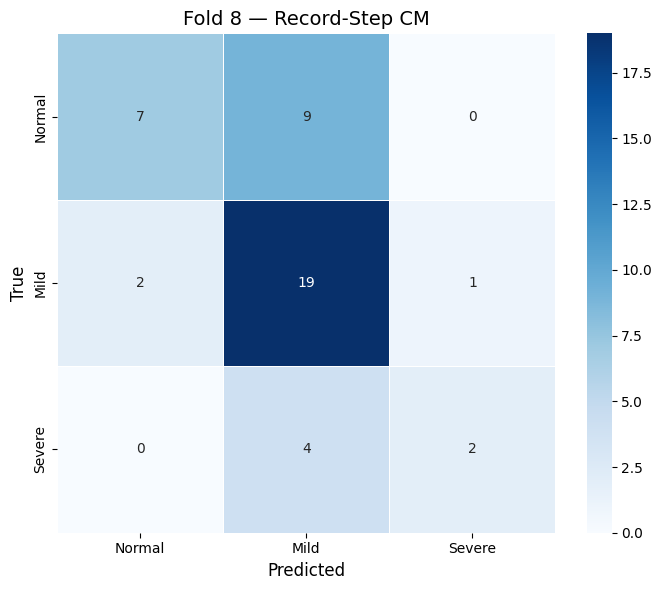


FOLD 9 / 10
  Validation quality: RELIABLE
    Normal: 23 step-units, 69 windows
    Mild: 18 step-units, 54 windows
    Severe: 10 step-units, 30 windows

TRAINING FROM SCRATCH
  Class weights (manual override): {0: 0.9, 1: 1.2, 2: 2.3}
  Early stopping monitor: val_record_step_balanced_accuracy
  Label smoothing: 0.02
Epoch 1/100
623/623 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4442 - loss: 1.3234  val_record_step_balanced_accuracy: 0.5187
623/623 ━━━━━━━━━━━━━━━━━━━━ 17s 14ms/step - accuracy: 0.4707 - loss: 1.3070 - val_accuracy: 0.4314 - val_loss: 1.0587 - val_record_step_balanced_accuracy: 0.5187 - learning_rate: 0.0010
Epoch 2/100
620/623 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5105 - loss: 1.2405  val_record_step_balanced_accuracy: 0.4366
623/623 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.5213 - loss: 1.2385 - val_accuracy: 0.4641 - val_loss: 1.0557 - val_record_step_balanced_accuracy: 0.4366 - learning_rate: 0.0010
Epoch 3/100
618/623 ━━━━━━━━━━━━━━━━━━━━ 0s 

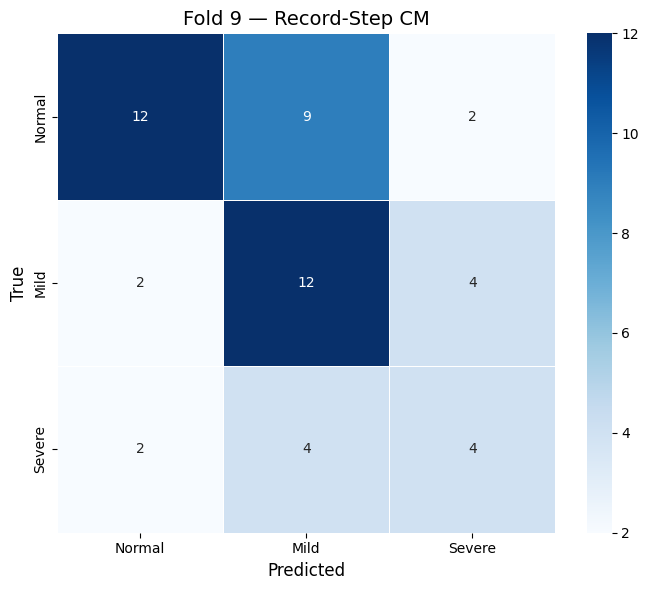


FOLD 10 / 10
  Validation quality: RELIABLE
    Normal: 24 step-units, 72 windows
    Mild: 17 step-units, 51 windows
    Severe: 5 step-units, 15 windows

TRAINING FROM SCRATCH
  Class weights (manual override): {0: 0.9, 1: 1.2, 2: 2.3}
  Early stopping monitor: val_record_step_balanced_accuracy
  Label smoothing: 0.02
Epoch 1/100
630/630 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4096 - loss: 1.3720  val_record_step_balanced_accuracy: 0.5716
630/630 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.4476 - loss: 1.3299 - val_accuracy: 0.6884 - val_loss: 0.9653 - val_record_step_balanced_accuracy: 0.5716 - learning_rate: 0.0010
Epoch 2/100
630/630 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5276 - loss: 1.2513  val_record_step_balanced_accuracy: 0.5438
630/630 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.5167 - loss: 1.2713 - val_accuracy: 0.5870 - val_loss: 0.9621 - val_record_step_balanced_accuracy: 0.5438 - learning_rate: 0.0010
Epoch 3/100
624/630 ━━━━━━━━━━━━━━━━━━━━ 0s 7m

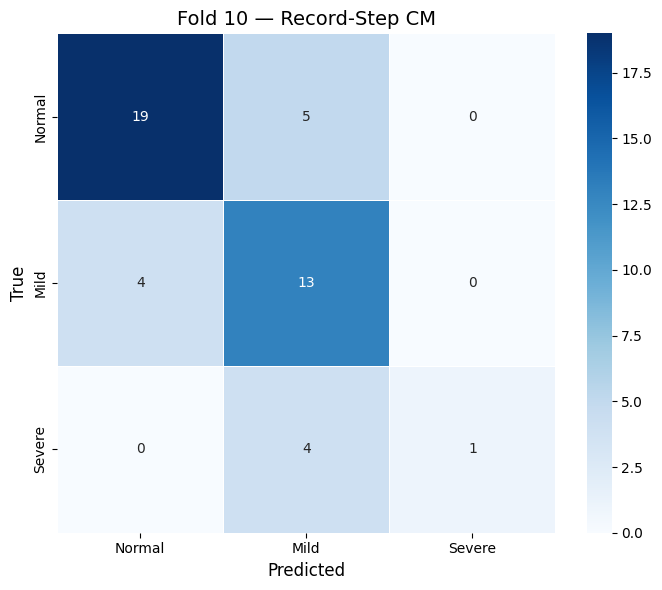

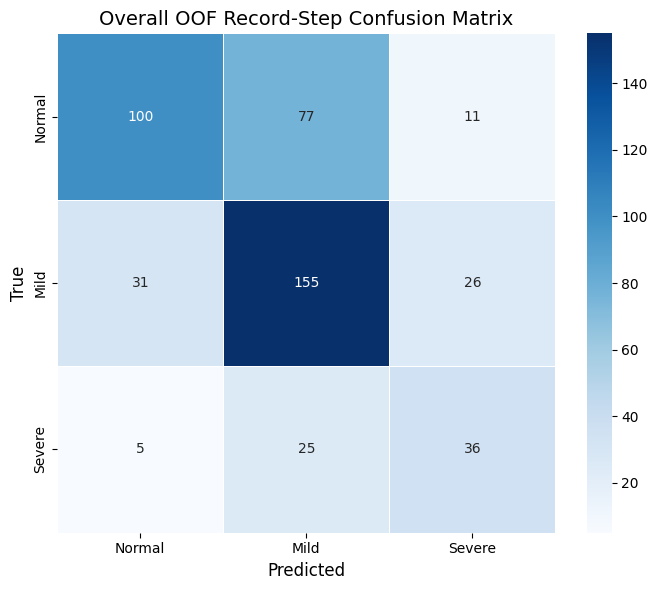

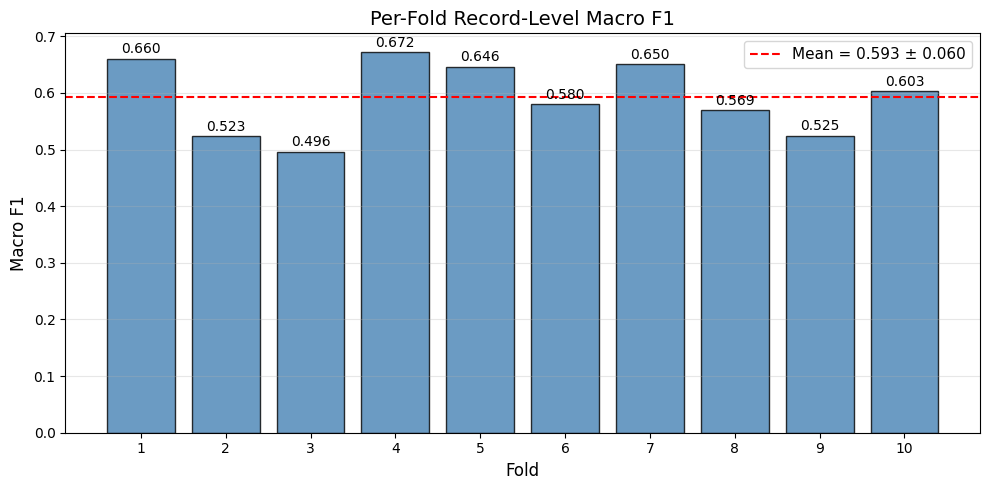

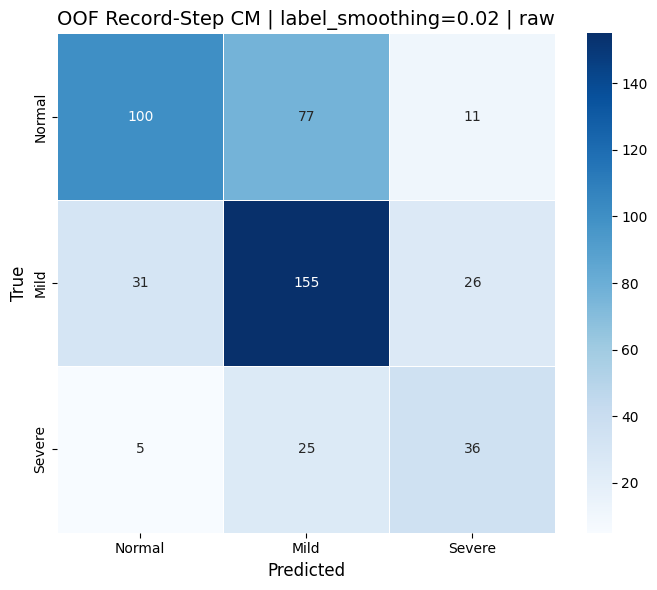

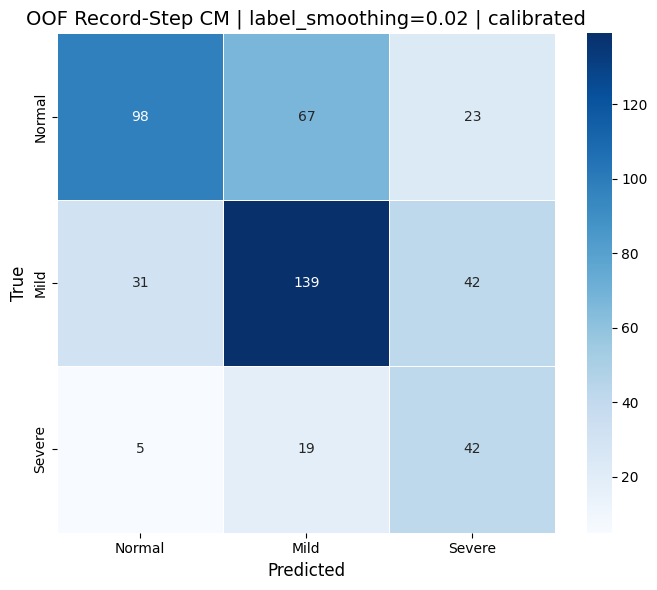


Run complete:
  Label smoothing:          0.02
  Raw OOF balanced acc:     0.6028
  Calibrated OOF bal acc:   0.6044
  Best OOF Severe boost:    0.10
  Results saved to:         C:\Users\ZEYNEP\OneDrive\Desktop\CTG_Dissertation\src\Transfer_Learning\outputs\step23_softmax_tenfold_tuning\cw_0p9_1p2_2p3\ls_0p02

Running tenfold CV for label_smoothing=0.05
Output directory: C:\Users\ZEYNEP\OneDrive\Desktop\CTG_Dissertation\src\Transfer_Learning\outputs\step23_softmax_tenfold_tuning\cw_0p9_1p2_2p3\ls_0p05
Computing engineered features from cleaned FHR windows...
  Engineered feature matrix: (1398, 10)

Generating 10-fold CV with requested >= 10 Severe step-units/fold...
  Total Severe step-units: 66, 10 folds -> max ~6/fold
  Found valid split at attempt 8 (seed=49, StratifiedGroupKFold)
    Severe step-units per val fold: [7, 7, 7, 8, 5, 6, 5, 6, 10, 5]
  Effective reliability threshold: 5 Severe step-units/fold

FOLD 1 / 10
  Validation quality: RELIABLE
    Normal: 17 step-units, 51 wi

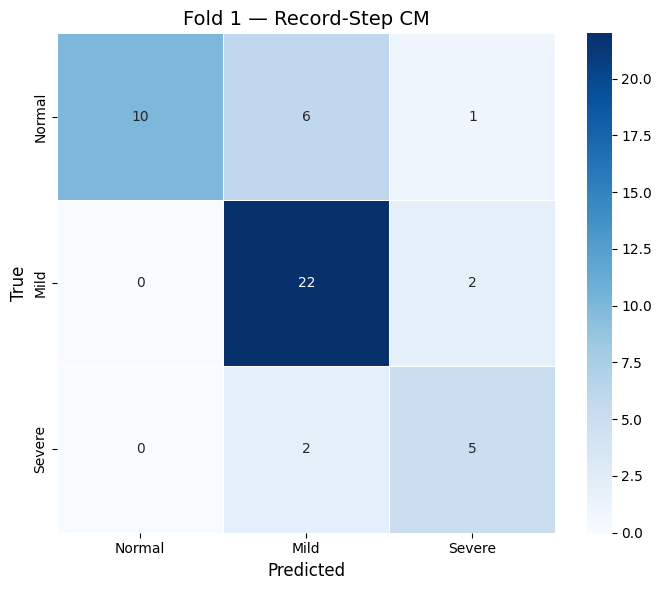


FOLD 2 / 10
  Validation quality: RELIABLE
    Normal: 26 step-units, 78 windows
    Mild: 19 step-units, 57 windows
    Severe: 7 step-units, 21 windows

TRAINING FROM SCRATCH
  Class weights (manual override): {0: 0.9, 1: 1.2, 2: 2.3}
  Early stopping monitor: val_record_step_balanced_accuracy
  Label smoothing: 0.05
Epoch 1/100
619/621 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4580 - loss: 1.3255  val_record_step_balanced_accuracy: 0.3016
621/621 ━━━━━━━━━━━━━━━━━━━━ 14s 14ms/step - accuracy: 0.4597 - loss: 1.3385 - val_accuracy: 0.3654 - val_loss: 1.0554 - val_record_step_balanced_accuracy: 0.3016 - learning_rate: 0.0010
Epoch 2/100
618/621 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5227 - loss: 1.2370  val_record_step_balanced_accuracy: 0.3259
621/621 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - accuracy: 0.5016 - loss: 1.2708 - val_accuracy: 0.4808 - val_loss: 1.0294 - val_record_step_balanced_accuracy: 0.3259 - learning_rate: 0.0010
Epoch 3/100
620/621 ━━━━━━━━━━━━━━━━━━━━ 0s

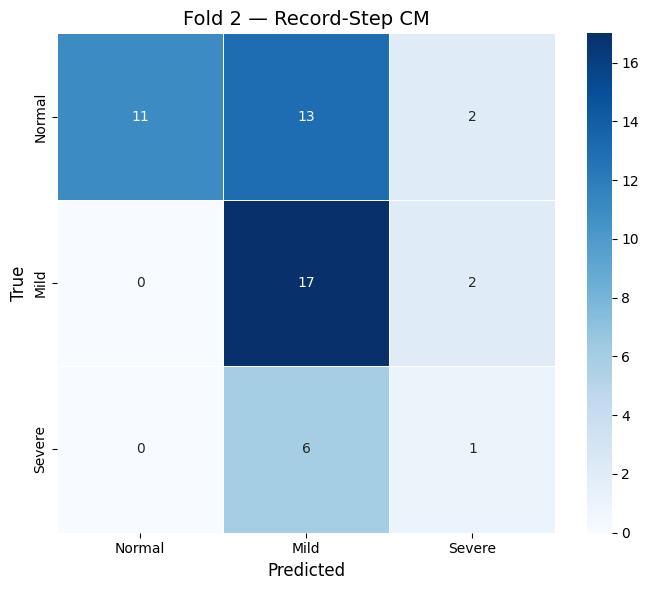


FOLD 3 / 10
  Validation quality: RELIABLE
    Normal: 16 step-units, 48 windows
    Mild: 19 step-units, 57 windows
    Severe: 7 step-units, 21 windows

TRAINING FROM SCRATCH
  Class weights (manual override): {0: 0.9, 1: 1.2, 2: 2.3}
  Early stopping monitor: val_record_step_balanced_accuracy
  Label smoothing: 0.05
Epoch 1/100
636/636 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.4415 - loss: 1.3907  val_record_step_balanced_accuracy: 0.4408
636/636 ━━━━━━━━━━━━━━━━━━━━ 18s 14ms/step - accuracy: 0.4654 - loss: 1.3211 - val_accuracy: 0.5238 - val_loss: 1.0546 - val_record_step_balanced_accuracy: 0.4408 - learning_rate: 0.0010
Epoch 2/100
633/636 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4976 - loss: 1.2909  val_record_step_balanced_accuracy: 0.3914
636/636 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.5063 - loss: 1.2606 - val_accuracy: 0.4603 - val_loss: 1.0361 - val_record_step_balanced_accuracy: 0.3914 - learning_rate: 0.0010
Epoch 3/100
632/636 ━━━━━━━━━━━━━━━━━━━━ 0s

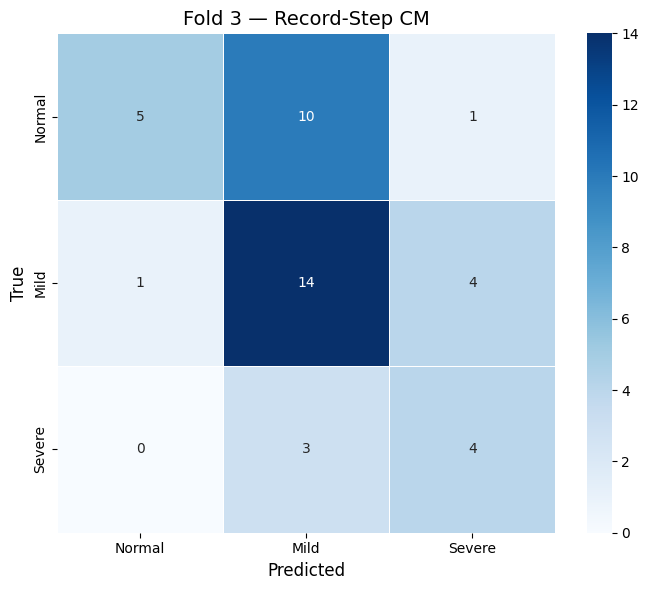


FOLD 4 / 10
  Validation quality: RELIABLE
    Normal: 11 step-units, 33 windows
    Mild: 26 step-units, 78 windows
    Severe: 8 step-units, 24 windows

TRAINING FROM SCRATCH
  Class weights (manual override): {0: 0.9, 1: 1.2, 2: 2.3}
  Early stopping monitor: val_record_step_balanced_accuracy
  Label smoothing: 0.05
Epoch 1/100
631/632 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.4084 - loss: 1.3189  val_record_step_balanced_accuracy: 0.5166
632/632 ━━━━━━━━━━━━━━━━━━━━ 20s 15ms/step - accuracy: 0.4656 - loss: 1.3126 - val_accuracy: 0.5185 - val_loss: 0.9949 - val_record_step_balanced_accuracy: 0.5166 - learning_rate: 0.0010
Epoch 2/100
632/632 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5258 - loss: 1.2271  val_record_step_balanced_accuracy: 0.6862
632/632 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.5123 - loss: 1.2775 - val_accuracy: 0.5556 - val_loss: 0.9902 - val_record_step_balanced_accuracy: 0.6862 - learning_rate: 0.0010
Epoch 3/100
631/632 ━━━━━━━━━━━━━━━━━━━━ 0s

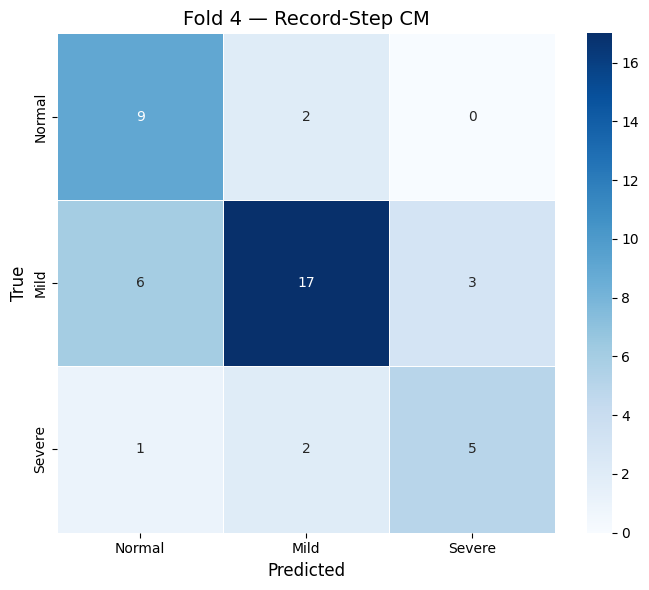


FOLD 5 / 10
  Validation quality: RELIABLE
    Normal: 16 step-units, 48 windows
    Mild: 21 step-units, 63 windows
    Severe: 5 step-units, 15 windows

TRAINING FROM SCRATCH
  Class weights (manual override): {0: 0.9, 1: 1.2, 2: 2.3}
  Early stopping monitor: val_record_step_balanced_accuracy
  Label smoothing: 0.05
Epoch 1/100
635/636 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.3743 - loss: 1.3901  val_record_step_balanced_accuracy: 0.6175
636/636 ━━━━━━━━━━━━━━━━━━━━ 19s 14ms/step - accuracy: 0.4222 - loss: 1.3377 - val_accuracy: 0.6190 - val_loss: 0.9826 - val_record_step_balanced_accuracy: 0.6175 - learning_rate: 0.0010
Epoch 2/100
634/636 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4943 - loss: 1.3102  val_record_step_balanced_accuracy: 0.5698
636/636 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.5173 - loss: 1.2727 - val_accuracy: 0.5952 - val_loss: 0.9388 - val_record_step_balanced_accuracy: 0.5698 - learning_rate: 0.0010
Epoch 3/100
634/636 ━━━━━━━━━━━━━━━━━━━━ 0s

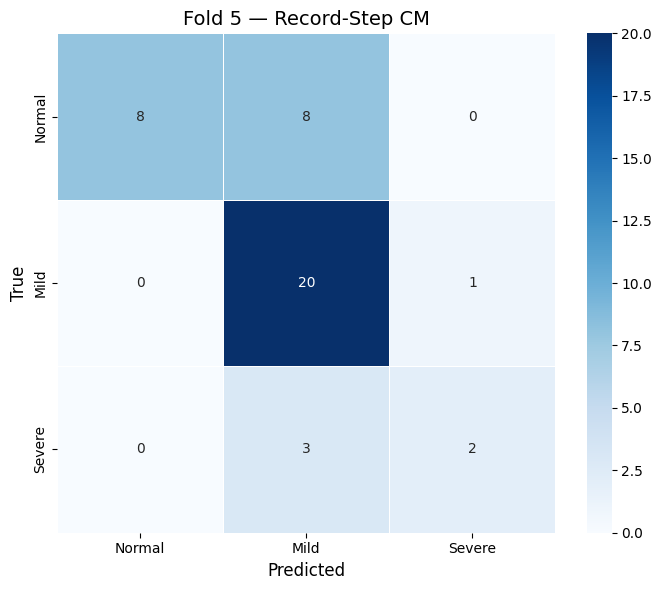


FOLD 6 / 10
  Validation quality: RELIABLE
    Normal: 24 step-units, 72 windows
    Mild: 20 step-units, 60 windows
    Severe: 6 step-units, 18 windows

TRAINING FROM SCRATCH
  Class weights (manual override): {0: 0.9, 1: 1.2, 2: 2.3}
  Early stopping monitor: val_record_step_balanced_accuracy
  Label smoothing: 0.05
Epoch 1/100
623/624 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4206 - loss: 1.4397  val_record_step_balanced_accuracy: 0.4194
624/624 ━━━━━━━━━━━━━━━━━━━━ 18s 14ms/step - accuracy: 0.4391 - loss: 1.3577 - val_accuracy: 0.4533 - val_loss: 1.1120 - val_record_step_balanced_accuracy: 0.4194 - learning_rate: 0.0010
Epoch 2/100
621/624 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4432 - loss: 1.3205  val_record_step_balanced_accuracy: 0.4472
624/624 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.4567 - loss: 1.3059 - val_accuracy: 0.5067 - val_loss: 1.0426 - val_record_step_balanced_accuracy: 0.4472 - learning_rate: 0.0010
Epoch 3/100
622/624 ━━━━━━━━━━━━━━━━━━━━ 0s

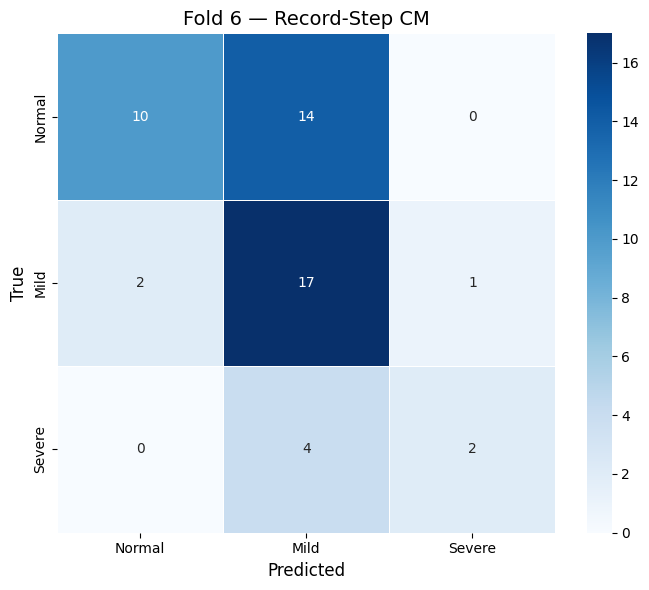


FOLD 7 / 10
  Validation quality: RELIABLE
    Normal: 15 step-units, 45 windows
    Mild: 26 step-units, 78 windows
    Severe: 5 step-units, 15 windows

TRAINING FROM SCRATCH
  Class weights (manual override): {0: 0.9, 1: 1.2, 2: 2.3}
  Early stopping monitor: val_record_step_balanced_accuracy
  Label smoothing: 0.05
Epoch 1/100
627/630 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4540 - loss: 1.3782  val_record_step_balanced_accuracy: 0.4846
630/630 ━━━━━━━━━━━━━━━━━━━━ 17s 13ms/step - accuracy: 0.4873 - loss: 1.3168 - val_accuracy: 0.4928 - val_loss: 1.0304 - val_record_step_balanced_accuracy: 0.4846 - learning_rate: 0.0010
Epoch 2/100
629/630 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.4647 - loss: 1.3152  val_record_step_balanced_accuracy: 0.4308
630/630 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.5016 - loss: 1.2835 - val_accuracy: 0.5290 - val_loss: 1.0163 - val_record_step_balanced_accuracy: 0.4308 - learning_rate: 0.0010
Epoch 3/100
627/630 ━━━━━━━━━━━━━━━━━━━━ 0s

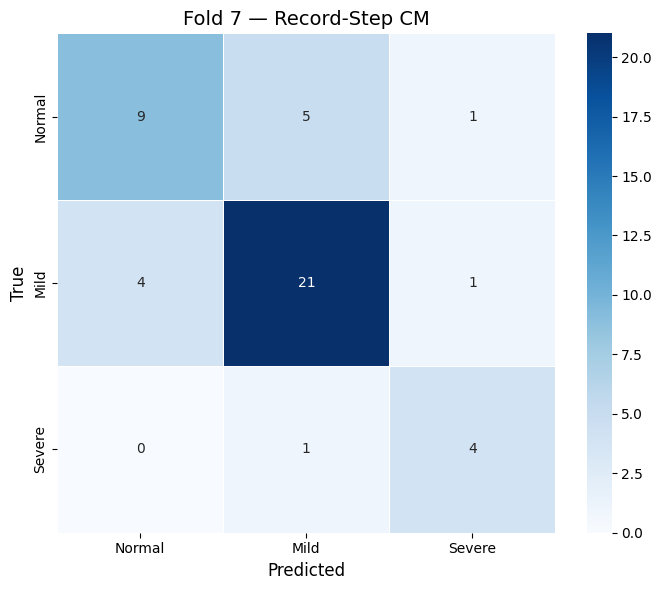


FOLD 8 / 10
  Validation quality: RELIABLE
    Normal: 16 step-units, 48 windows
    Mild: 22 step-units, 66 windows
    Severe: 6 step-units, 18 windows

TRAINING FROM SCRATCH
  Class weights (manual override): {0: 0.9, 1: 1.2, 2: 2.3}
  Early stopping monitor: val_record_step_balanced_accuracy
  Label smoothing: 0.05
Epoch 1/100
631/633 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4260 - loss: 1.3559  val_record_step_balanced_accuracy: 0.4242
633/633 ━━━━━━━━━━━━━━━━━━━━ 20s 15ms/step - accuracy: 0.4487 - loss: 1.3363 - val_accuracy: 0.5303 - val_loss: 1.0010 - val_record_step_balanced_accuracy: 0.4242 - learning_rate: 0.0010
Epoch 2/100
632/633 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4912 - loss: 1.2977  val_record_step_balanced_accuracy: 0.4432
633/633 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - accuracy: 0.4968 - loss: 1.2879 - val_accuracy: 0.5606 - val_loss: 0.9895 - val_record_step_balanced_accuracy: 0.4432 - learning_rate: 0.0010
Epoch 3/100
628/633 ━━━━━━━━━━━━━━━━━━━━ 0s

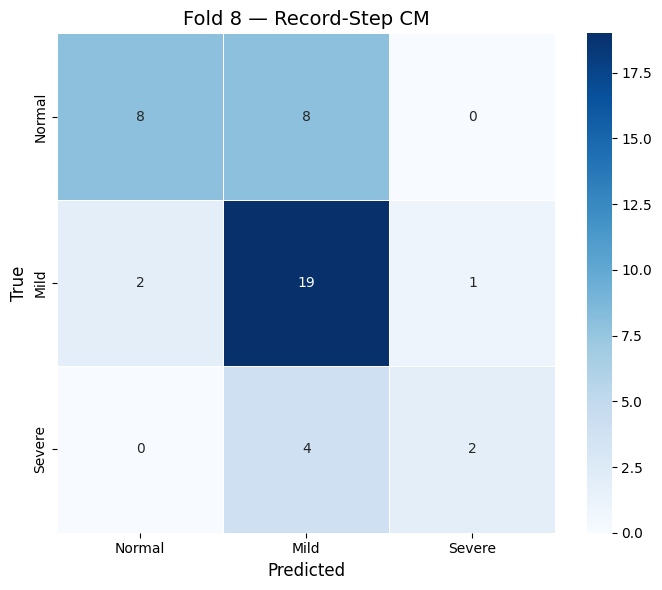


FOLD 9 / 10
  Validation quality: RELIABLE
    Normal: 23 step-units, 69 windows
    Mild: 18 step-units, 54 windows
    Severe: 10 step-units, 30 windows

TRAINING FROM SCRATCH
  Class weights (manual override): {0: 0.9, 1: 1.2, 2: 2.3}
  Early stopping monitor: val_record_step_balanced_accuracy
  Label smoothing: 0.05
Epoch 1/100
618/623 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.4113 - loss: 1.3736  val_record_step_balanced_accuracy: 0.5372
623/623 ━━━━━━━━━━━━━━━━━━━━ 20s 15ms/step - accuracy: 0.4546 - loss: 1.3413 - val_accuracy: 0.4967 - val_loss: 1.0582 - val_record_step_balanced_accuracy: 0.5372 - learning_rate: 0.0010
Epoch 2/100
622/623 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5106 - loss: 1.2422  val_record_step_balanced_accuracy: 0.4110
623/623 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.5157 - loss: 1.2544 - val_accuracy: 0.4837 - val_loss: 1.0525 - val_record_step_balanced_accuracy: 0.4110 - learning_rate: 0.0010
Epoch 3/100
620/623 ━━━━━━━━━━━━━━━━━━━━ 0

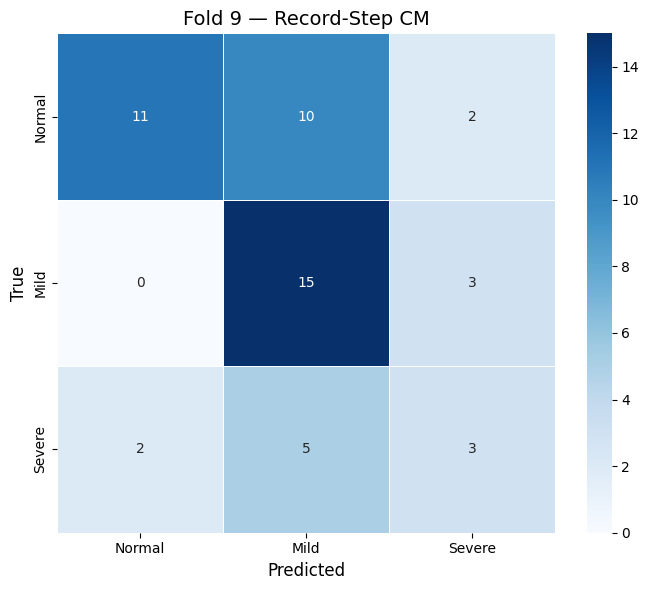


FOLD 10 / 10
  Validation quality: RELIABLE
    Normal: 24 step-units, 72 windows
    Mild: 17 step-units, 51 windows
    Severe: 5 step-units, 15 windows

TRAINING FROM SCRATCH
  Class weights (manual override): {0: 0.9, 1: 1.2, 2: 2.3}
  Early stopping monitor: val_record_step_balanced_accuracy
  Label smoothing: 0.05
Epoch 1/100
629/630 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4084 - loss: 1.4001  val_record_step_balanced_accuracy: 0.4493
630/630 ━━━━━━━━━━━━━━━━━━━━ 17s 13ms/step - accuracy: 0.4579 - loss: 1.3518 - val_accuracy: 0.5725 - val_loss: 0.9768 - val_record_step_balanced_accuracy: 0.4493 - learning_rate: 0.0010
Epoch 2/100
629/630 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.4860 - loss: 1.3166  val_record_step_balanced_accuracy: 0.4850
630/630 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - accuracy: 0.5056 - loss: 1.2949 - val_accuracy: 0.5725 - val_loss: 0.9612 - val_record_step_balanced_accuracy: 0.4850 - learning_rate: 0.0010
Epoch 3/100
627/630 ━━━━━━━━━━━━━━━━━━━━ 0

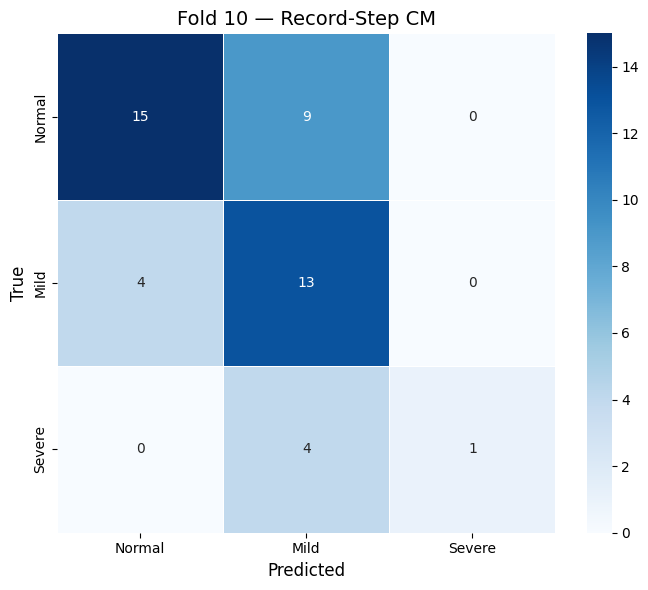

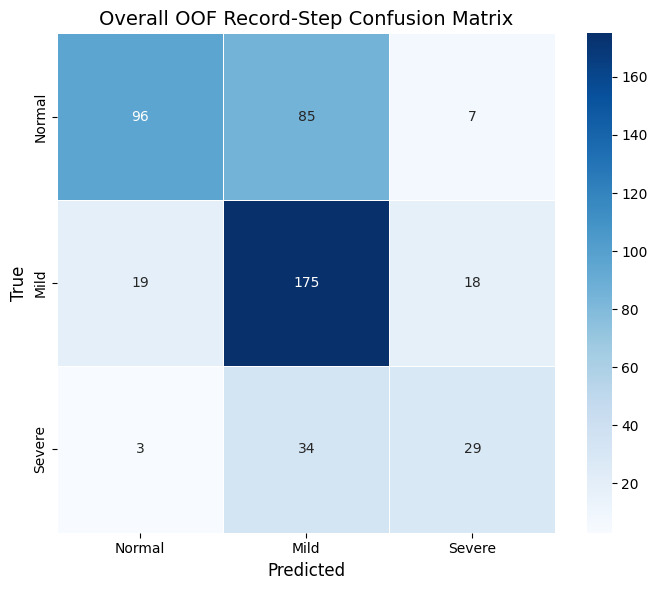

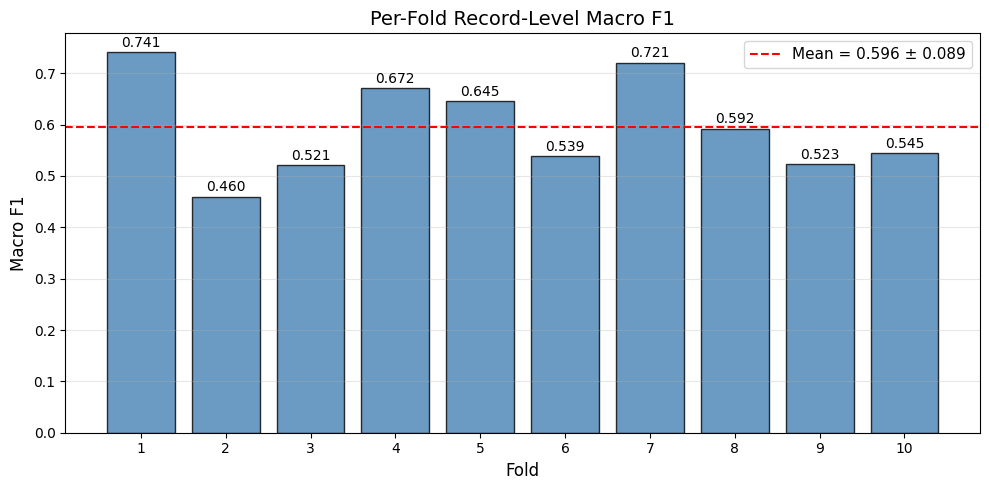

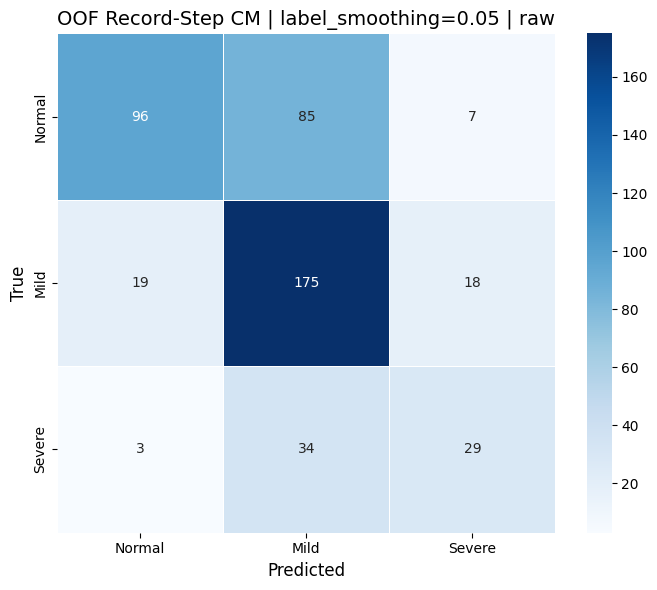

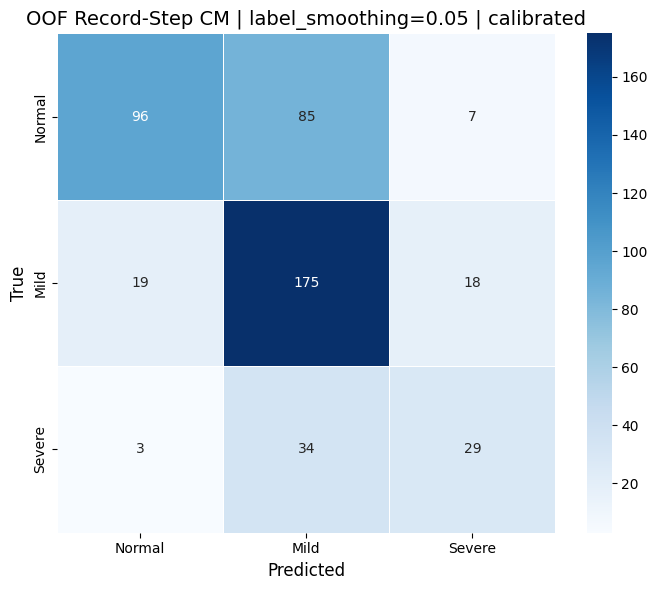


Run complete:
  Label smoothing:          0.05
  Raw OOF balanced acc:     0.5918
  Calibrated OOF bal acc:   0.5918
  Best OOF Severe boost:    0.00
  Results saved to:         C:\Users\ZEYNEP\OneDrive\Desktop\CTG_Dissertation\src\Transfer_Learning\outputs\step23_softmax_tenfold_tuning\cw_0p9_1p2_2p3\ls_0p05

##############################################################################
TENFOLD LABEL-SMOOTHING + OOF CALIBRATION SUMMARY
##############################################################################
 label_smoothing  best_oof_severe_boost  raw_balanced_accuracy  calibrated_balanced_accuracy  raw_macro_f1  calibrated_macro_f1
            0.02                    0.1               0.602834                      0.604434      0.598750             0.576800
            0.05                    0.0               0.591835                      0.591835      0.600828             0.600828
            0.00                    0.0               0.581560                      0.581560   

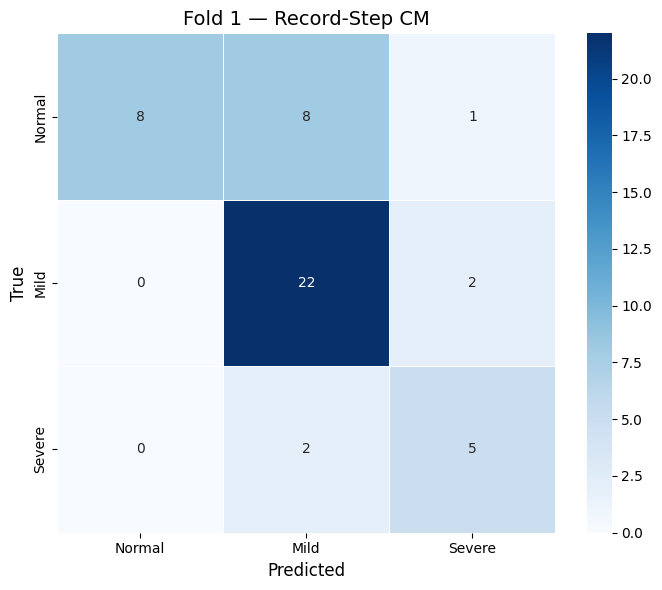


FOLD 2 / 10
  Validation quality: RELIABLE
    Normal: 26 step-units, 78 windows
    Mild: 19 step-units, 57 windows
    Severe: 7 step-units, 21 windows

TRAINING FROM SCRATCH
  Class weights (manual override): {0: 0.9, 1: 1.3, 2: 2.3}
  Early stopping monitor: val_record_step_balanced_accuracy
  Label smoothing: 0.00
Epoch 1/100
616/621 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.4195 - loss: 1.3874  val_record_step_balanced_accuracy: 0.4984
621/621 ━━━━━━━━━━━━━━━━━━━━ 21s 15ms/step - accuracy: 0.4589 - loss: 1.3701 - val_accuracy: 0.5897 - val_loss: 0.9941 - val_record_step_balanced_accuracy: 0.4984 - learning_rate: 0.0010
Epoch 2/100
620/621 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.4961 - loss: 1.2715  val_record_step_balanced_accuracy: 0.4437
621/621 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.4823 - loss: 1.3078 - val_accuracy: 0.5064 - val_loss: 1.0372 - val_record_step_balanced_accuracy: 0.4437 - learning_rate: 0.0010
Epoch 3/100
618/621 ━━━━━━━━━━━━━━━━━━━━ 0s

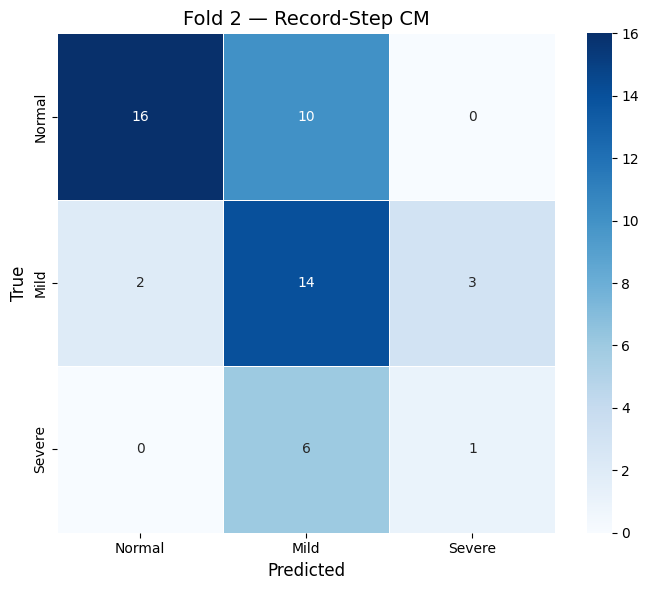


FOLD 3 / 10
  Validation quality: RELIABLE
    Normal: 16 step-units, 48 windows
    Mild: 19 step-units, 57 windows
    Severe: 7 step-units, 21 windows

TRAINING FROM SCRATCH
  Class weights (manual override): {0: 0.9, 1: 1.3, 2: 2.3}
  Early stopping monitor: val_record_step_balanced_accuracy
  Label smoothing: 0.00
Epoch 1/100
634/636 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.4218 - loss: 1.4198  val_record_step_balanced_accuracy: 0.3849
636/636 ━━━━━━━━━━━━━━━━━━━━ 22s 15ms/step - accuracy: 0.4497 - loss: 1.3619 - val_accuracy: 0.4762 - val_loss: 1.0230 - val_record_step_balanced_accuracy: 0.3849 - learning_rate: 0.0010
Epoch 2/100
631/636 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4944 - loss: 1.3328  val_record_step_balanced_accuracy: 0.4024
636/636 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - accuracy: 0.4953 - loss: 1.3005 - val_accuracy: 0.5238 - val_loss: 1.0303 - val_record_step_balanced_accuracy: 0.4024 - learning_rate: 0.0010
Epoch 3/100
634/636 ━━━━━━━━━━━━━━━━━━━━ 0s

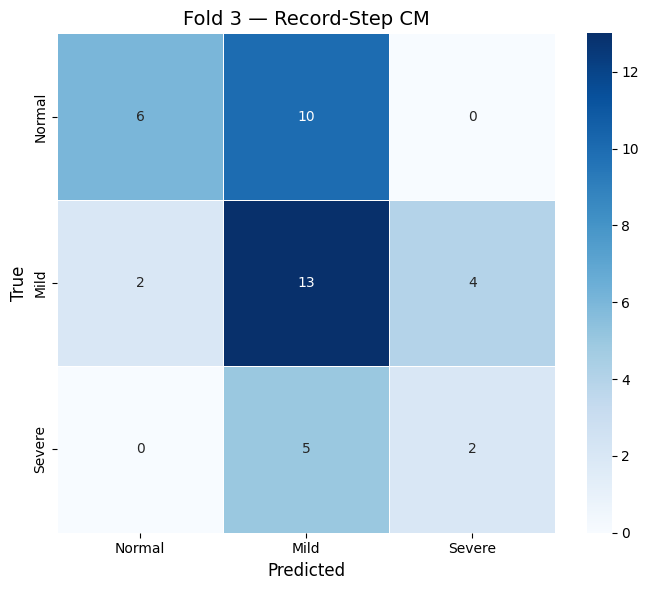


FOLD 4 / 10
  Validation quality: RELIABLE
    Normal: 11 step-units, 33 windows
    Mild: 26 step-units, 78 windows
    Severe: 8 step-units, 24 windows

TRAINING FROM SCRATCH
  Class weights (manual override): {0: 0.9, 1: 1.3, 2: 2.3}
  Early stopping monitor: val_record_step_balanced_accuracy
  Label smoothing: 0.00
Epoch 1/100
629/632 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.4380 - loss: 1.3344  val_record_step_balanced_accuracy: 0.6270
632/632 ━━━━━━━━━━━━━━━━━━━━ 20s 15ms/step - accuracy: 0.4719 - loss: 1.3354 - val_accuracy: 0.5333 - val_loss: 0.9705 - val_record_step_balanced_accuracy: 0.6270 - learning_rate: 0.0010
Epoch 2/100
629/632 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5026 - loss: 1.2739  val_record_step_balanced_accuracy: 0.6480
632/632 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - accuracy: 0.5067 - loss: 1.2969 - val_accuracy: 0.5704 - val_loss: 0.9275 - val_record_step_balanced_accuracy: 0.6480 - learning_rate: 0.0010
Epoch 3/100
629/632 ━━━━━━━━━━━━━━━━━━━━ 0s

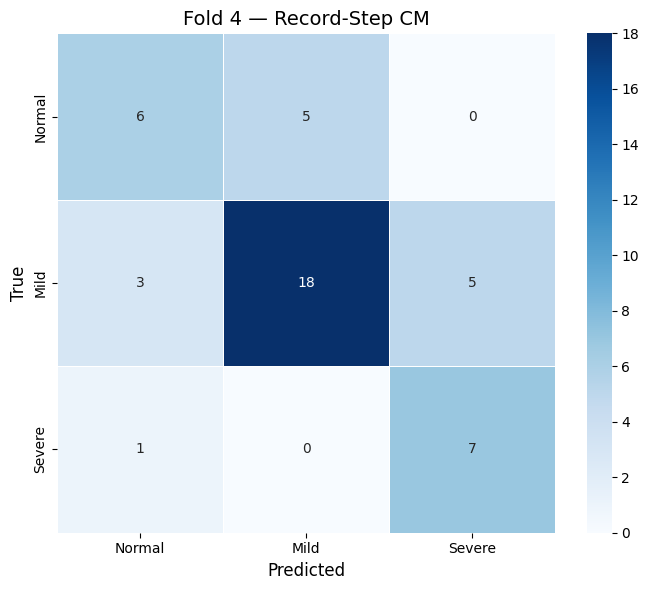


FOLD 5 / 10
  Validation quality: RELIABLE
    Normal: 16 step-units, 48 windows
    Mild: 21 step-units, 63 windows
    Severe: 5 step-units, 15 windows

TRAINING FROM SCRATCH
  Class weights (manual override): {0: 0.9, 1: 1.3, 2: 2.3}
  Early stopping monitor: val_record_step_balanced_accuracy
  Label smoothing: 0.00
Epoch 1/100
636/636 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.4120 - loss: 1.4364  val_record_step_balanced_accuracy: 0.4933
636/636 ━━━━━━━━━━━━━━━━━━━━ 17s 13ms/step - accuracy: 0.4465 - loss: 1.3712 - val_accuracy: 0.5556 - val_loss: 0.9626 - val_record_step_balanced_accuracy: 0.4933 - learning_rate: 0.0010
Epoch 2/100
631/636 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4879 - loss: 1.3198  val_record_step_balanced_accuracy: 0.4107
636/636 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.5039 - loss: 1.2996 - val_accuracy: 0.5476 - val_loss: 0.9296 - val_record_step_balanced_accuracy: 0.4107 - learning_rate: 0.0010
Epoch 3/100
633/636 ━━━━━━━━━━━━━━━━━━━━ 0s 

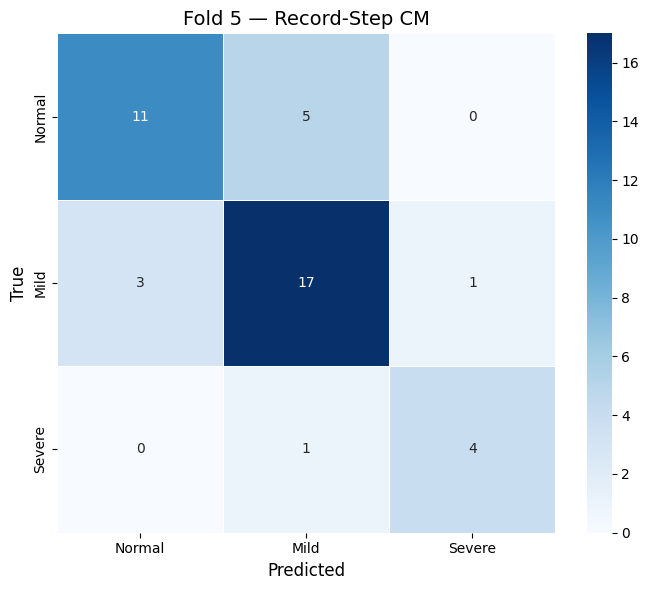


FOLD 6 / 10
  Validation quality: RELIABLE
    Normal: 24 step-units, 72 windows
    Mild: 20 step-units, 60 windows
    Severe: 6 step-units, 18 windows

TRAINING FROM SCRATCH
  Class weights (manual override): {0: 0.9, 1: 1.3, 2: 2.3}
  Early stopping monitor: val_record_step_balanced_accuracy
  Label smoothing: 0.00
Epoch 1/100
619/624 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4809 - loss: 1.4278  val_record_step_balanced_accuracy: 0.3861
624/624 ━━━━━━━━━━━━━━━━━━━━ 17s 14ms/step - accuracy: 0.4800 - loss: 1.3769 - val_accuracy: 0.4667 - val_loss: 1.0625 - val_record_step_balanced_accuracy: 0.3861 - learning_rate: 0.0010
Epoch 2/100
619/624 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5311 - loss: 1.3234  val_record_step_balanced_accuracy: 0.3694
624/624 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.5088 - loss: 1.3224 - val_accuracy: 0.4333 - val_loss: 1.0482 - val_record_step_balanced_accuracy: 0.3694 - learning_rate: 0.0010
Epoch 3/100
621/624 ━━━━━━━━━━━━━━━━━━━━ 0s 

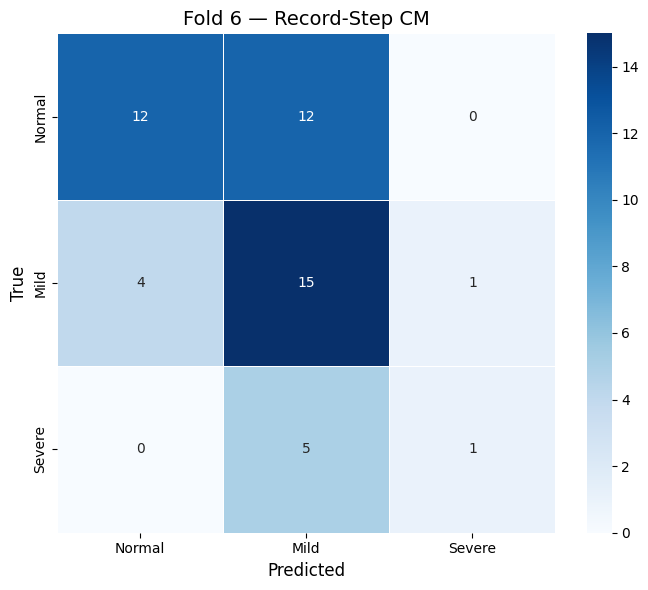


FOLD 7 / 10
  Validation quality: RELIABLE
    Normal: 15 step-units, 45 windows
    Mild: 26 step-units, 78 windows
    Severe: 5 step-units, 15 windows

TRAINING FROM SCRATCH
  Class weights (manual override): {0: 0.9, 1: 1.3, 2: 2.3}
  Early stopping monitor: val_record_step_balanced_accuracy
  Label smoothing: 0.00
Epoch 1/100
624/630 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.3261 - loss: 1.4371  val_record_step_balanced_accuracy: 0.5077
630/630 ━━━━━━━━━━━━━━━━━━━━ 17s 13ms/step - accuracy: 0.3944 - loss: 1.3601 - val_accuracy: 0.5652 - val_loss: 1.0142 - val_record_step_balanced_accuracy: 0.5077 - learning_rate: 0.0010
Epoch 2/100
625/630 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.4865 - loss: 1.3465  val_record_step_balanced_accuracy: 0.5359
630/630 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.5183 - loss: 1.2945 - val_accuracy: 0.5145 - val_loss: 0.9752 - val_record_step_balanced_accuracy: 0.5359 - learning_rate: 0.0010
Epoch 3/100
628/630 ━━━━━━━━━━━━━━━━━━━━ 0s 1

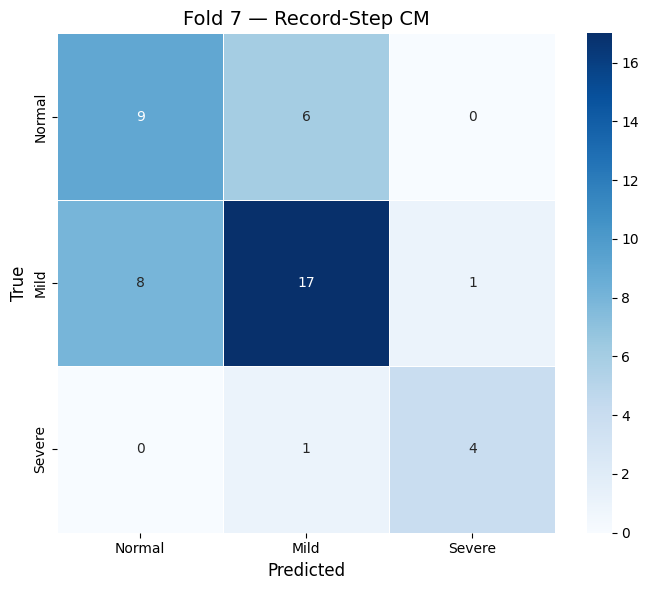


FOLD 8 / 10
  Validation quality: RELIABLE
    Normal: 16 step-units, 48 windows
    Mild: 22 step-units, 66 windows
    Severe: 6 step-units, 18 windows

TRAINING FROM SCRATCH
  Class weights (manual override): {0: 0.9, 1: 1.3, 2: 2.3}
  Early stopping monitor: val_record_step_balanced_accuracy
  Label smoothing: 0.00
Epoch 1/100
633/633 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4120 - loss: 1.4049  val_record_step_balanced_accuracy: 0.3561
633/633 ━━━━━━━━━━━━━━━━━━━━ 17s 13ms/step - accuracy: 0.4494 - loss: 1.3591 - val_accuracy: 0.5227 - val_loss: 0.9695 - val_record_step_balanced_accuracy: 0.3561 - learning_rate: 0.0010
Epoch 2/100
628/633 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5032 - loss: 1.3041  val_record_step_balanced_accuracy: 0.4893
633/633 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.4929 - loss: 1.2988 - val_accuracy: 0.5909 - val_loss: 0.9381 - val_record_step_balanced_accuracy: 0.4893 - learning_rate: 0.0010
Epoch 3/100
630/633 ━━━━━━━━━━━━━━━━━━━━ 0s 

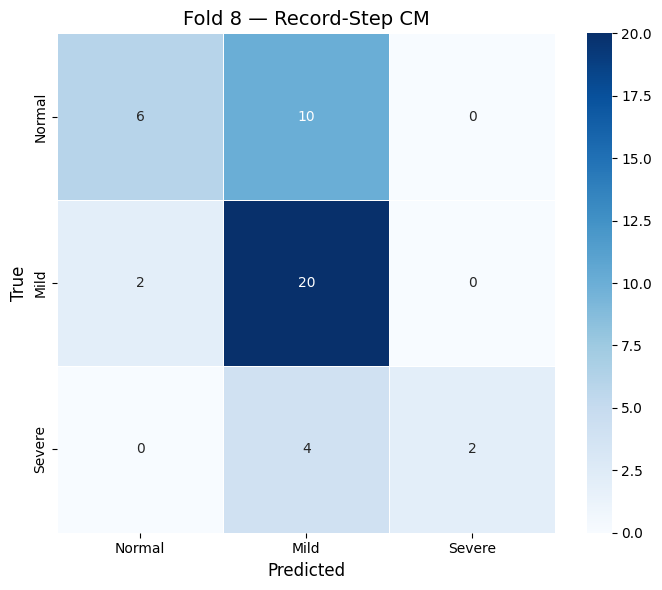


FOLD 9 / 10
  Validation quality: RELIABLE
    Normal: 23 step-units, 69 windows
    Mild: 18 step-units, 54 windows
    Severe: 10 step-units, 30 windows

TRAINING FROM SCRATCH
  Class weights (manual override): {0: 0.9, 1: 1.3, 2: 2.3}
  Early stopping monitor: val_record_step_balanced_accuracy
  Label smoothing: 0.00
Epoch 1/100
618/623 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4514 - loss: 1.3468  val_record_step_balanced_accuracy: 0.4092
623/623 ━━━━━━━━━━━━━━━━━━━━ 17s 13ms/step - accuracy: 0.4811 - loss: 1.3349 - val_accuracy: 0.4183 - val_loss: 1.0662 - val_record_step_balanced_accuracy: 0.4092 - learning_rate: 0.0010
Epoch 2/100
619/623 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.4805 - loss: 1.3205  val_record_step_balanced_accuracy: 0.4681
623/623 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - accuracy: 0.4892 - loss: 1.3088 - val_accuracy: 0.4641 - val_loss: 1.0394 - val_record_step_balanced_accuracy: 0.4681 - learning_rate: 0.0010
Epoch 3/100
621/623 ━━━━━━━━━━━━━━━━━━━━ 0

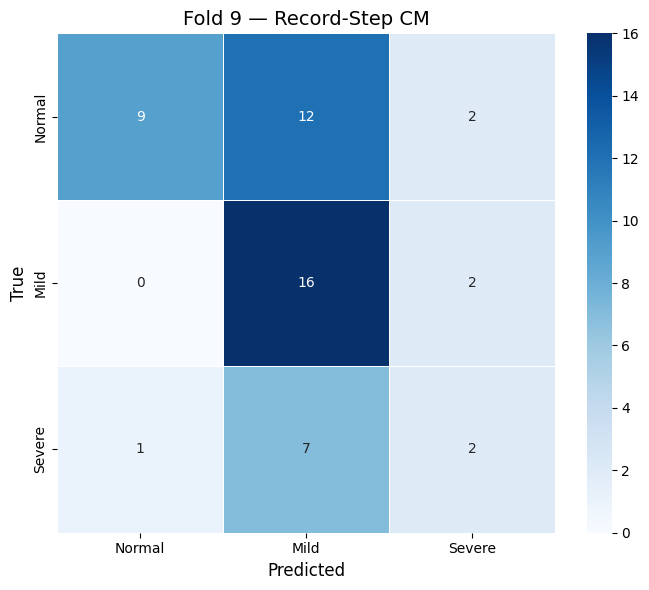


FOLD 10 / 10
  Validation quality: RELIABLE
    Normal: 24 step-units, 72 windows
    Mild: 17 step-units, 51 windows
    Severe: 5 step-units, 15 windows

TRAINING FROM SCRATCH
  Class weights (manual override): {0: 0.9, 1: 1.3, 2: 2.3}
  Early stopping monitor: val_record_step_balanced_accuracy
  Label smoothing: 0.00
Epoch 1/100
628/630 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.3872 - loss: 1.4931  val_record_step_balanced_accuracy: 0.3889
630/630 ━━━━━━━━━━━━━━━━━━━━ 17s 13ms/step - accuracy: 0.4365 - loss: 1.4290 - val_accuracy: 0.4420 - val_loss: 1.0374 - val_record_step_balanced_accuracy: 0.3889 - learning_rate: 0.0010
Epoch 2/100
629/630 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4841 - loss: 1.3370  val_record_step_balanced_accuracy: 0.3881
630/630 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.4976 - loss: 1.3273 - val_accuracy: 0.5217 - val_loss: 0.9885 - val_record_step_balanced_accuracy: 0.3881 - learning_rate: 0.0010
Epoch 3/100
628/630 ━━━━━━━━━━━━━━━━━━━━ 0s

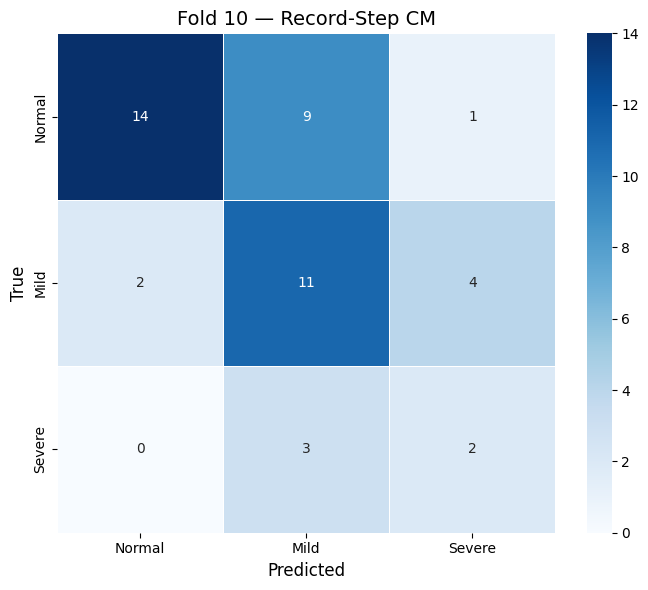

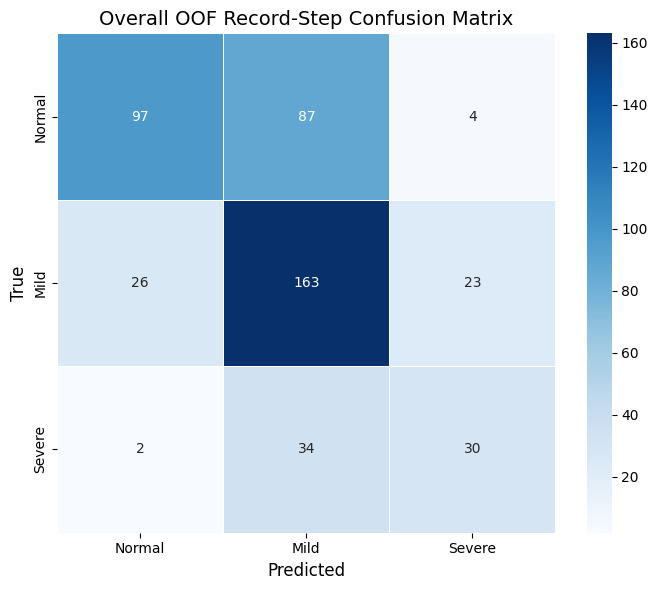

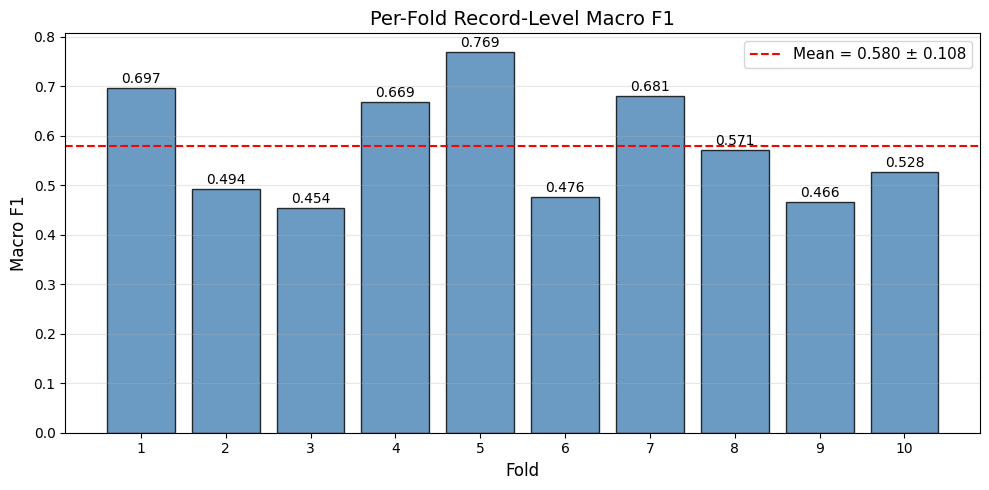

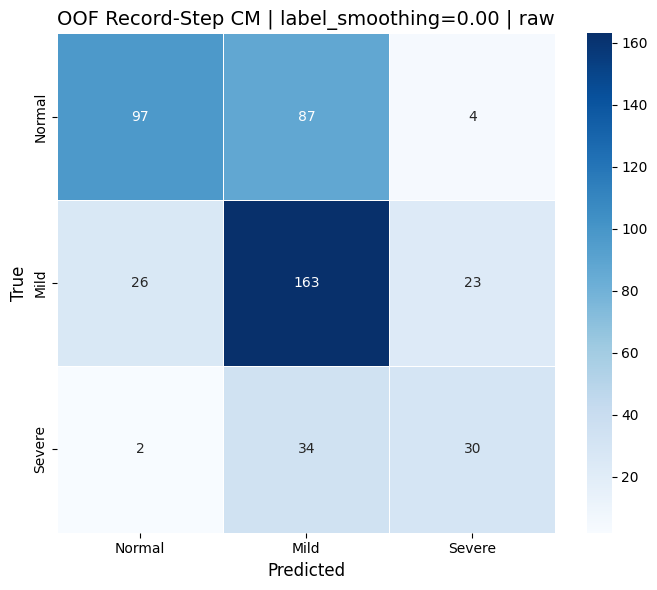

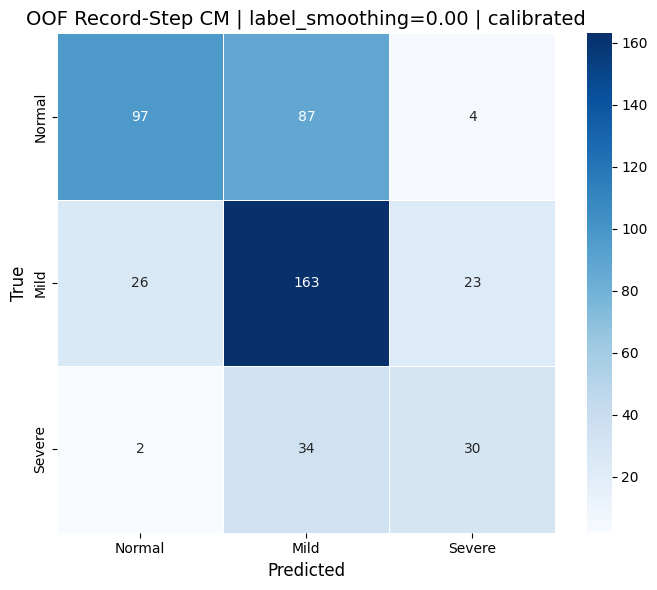


Run complete:
  Label smoothing:          0.00
  Raw OOF balanced acc:     0.5798
  Calibrated OOF bal acc:   0.5798
  Best OOF Severe boost:    0.00
  Results saved to:         C:\Users\ZEYNEP\OneDrive\Desktop\CTG_Dissertation\src\Transfer_Learning\outputs\step23_softmax_tenfold_tuning\cw_0p9_1p3_2p3\ls_0p00

Running tenfold CV for label_smoothing=0.02
Output directory: C:\Users\ZEYNEP\OneDrive\Desktop\CTG_Dissertation\src\Transfer_Learning\outputs\step23_softmax_tenfold_tuning\cw_0p9_1p3_2p3\ls_0p02
Computing engineered features from cleaned FHR windows...
  Engineered feature matrix: (1398, 10)

Generating 10-fold CV with requested >= 10 Severe step-units/fold...
  Total Severe step-units: 66, 10 folds -> max ~6/fold
  Found valid split at attempt 8 (seed=49, StratifiedGroupKFold)
    Severe step-units per val fold: [7, 7, 7, 8, 5, 6, 5, 6, 10, 5]
  Effective reliability threshold: 5 Severe step-units/fold

FOLD 1 / 10
  Validation quality: RELIABLE
    Normal: 17 step-units, 51 wi

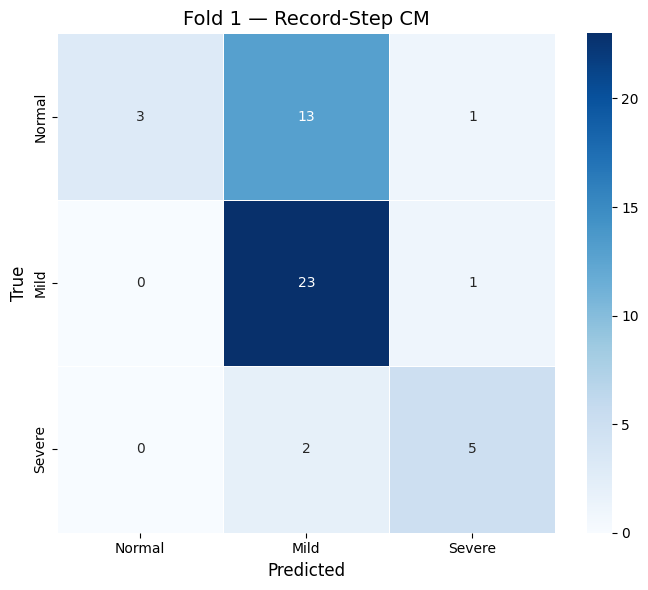


FOLD 2 / 10
  Validation quality: RELIABLE
    Normal: 26 step-units, 78 windows
    Mild: 19 step-units, 57 windows
    Severe: 7 step-units, 21 windows

TRAINING FROM SCRATCH
  Class weights (manual override): {0: 0.9, 1: 1.3, 2: 2.3}
  Early stopping monitor: val_record_step_balanced_accuracy
  Label smoothing: 0.02
Epoch 1/100
618/621 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4707 - loss: 1.3649  val_record_step_balanced_accuracy: 0.3097
621/621 ━━━━━━━━━━━━━━━━━━━━ 17s 13ms/step - accuracy: 0.4710 - loss: 1.3880 - val_accuracy: 0.3974 - val_loss: 1.0662 - val_record_step_balanced_accuracy: 0.3097 - learning_rate: 0.0010
Epoch 2/100
619/621 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5113 - loss: 1.2805  val_record_step_balanced_accuracy: 0.3576
621/621 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.4895 - loss: 1.3130 - val_accuracy: 0.4615 - val_loss: 1.0407 - val_record_step_balanced_accuracy: 0.3576 - learning_rate: 0.0010
Epoch 3/100
617/621 ━━━━━━━━━━━━━━━━━━━━ 0s

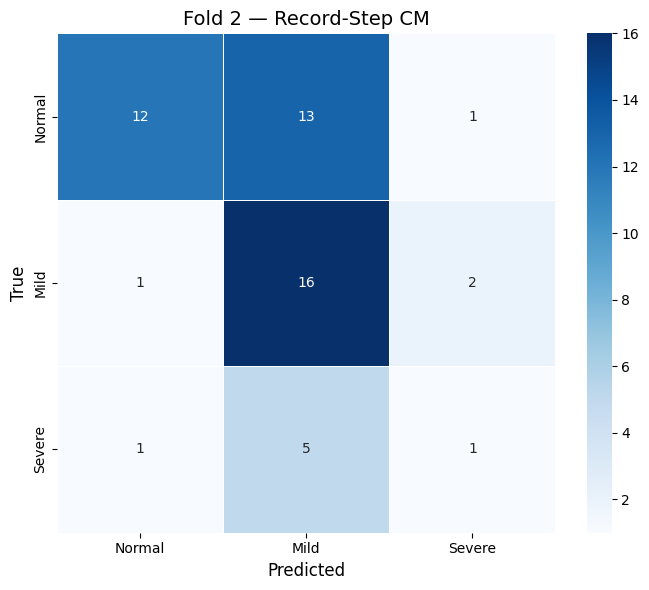


FOLD 3 / 10
  Validation quality: RELIABLE
    Normal: 16 step-units, 48 windows
    Mild: 19 step-units, 57 windows
    Severe: 7 step-units, 21 windows

TRAINING FROM SCRATCH
  Class weights (manual override): {0: 0.9, 1: 1.3, 2: 2.3}
  Early stopping monitor: val_record_step_balanced_accuracy
  Label smoothing: 0.02
Epoch 1/100
630/636 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.3869 - loss: 1.4582  val_record_step_balanced_accuracy: 0.3958
636/636 ━━━━━━━━━━━━━━━━━━━━ 17s 13ms/step - accuracy: 0.4143 - loss: 1.3993 - val_accuracy: 0.4921 - val_loss: 1.0097 - val_record_step_balanced_accuracy: 0.3958 - learning_rate: 0.0010
Epoch 2/100
636/636 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4716 - loss: 1.3579  val_record_step_balanced_accuracy: 0.3081
636/636 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.4725 - loss: 1.3138 - val_accuracy: 0.4365 - val_loss: 1.0159 - val_record_step_balanced_accuracy: 0.3081 - learning_rate: 0.0010
Epoch 3/100
636/636 ━━━━━━━━━━━━━━━━━━━━ 0s 

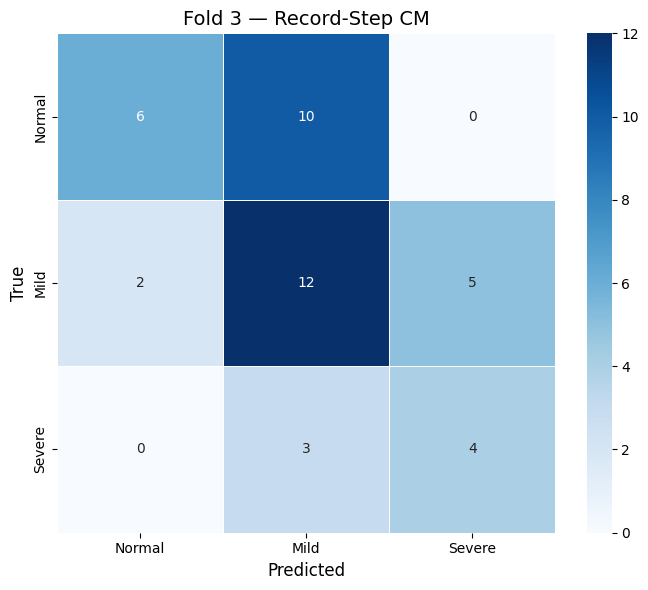


FOLD 4 / 10
  Validation quality: RELIABLE
    Normal: 11 step-units, 33 windows
    Mild: 26 step-units, 78 windows
    Severe: 8 step-units, 24 windows

TRAINING FROM SCRATCH
  Class weights (manual override): {0: 0.9, 1: 1.3, 2: 2.3}
  Early stopping monitor: val_record_step_balanced_accuracy
  Label smoothing: 0.02
Epoch 1/100
632/632 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4969 - loss: 1.3624  val_record_step_balanced_accuracy: 0.4289
632/632 ━━━━━━━━━━━━━━━━━━━━ 20s 14ms/step - accuracy: 0.4861 - loss: 1.3770 - val_accuracy: 0.5778 - val_loss: 0.9579 - val_record_step_balanced_accuracy: 0.4289 - learning_rate: 0.0010
Epoch 2/100
630/632 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.4771 - loss: 1.2935  val_record_step_balanced_accuracy: 0.4610
632/632 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.4941 - loss: 1.3240 - val_accuracy: 0.5407 - val_loss: 0.9607 - val_record_step_balanced_accuracy: 0.4610 - learning_rate: 0.0010
Epoch 3/100
630/632 ━━━━━━━━━━━━━━━━━━━━ 0s

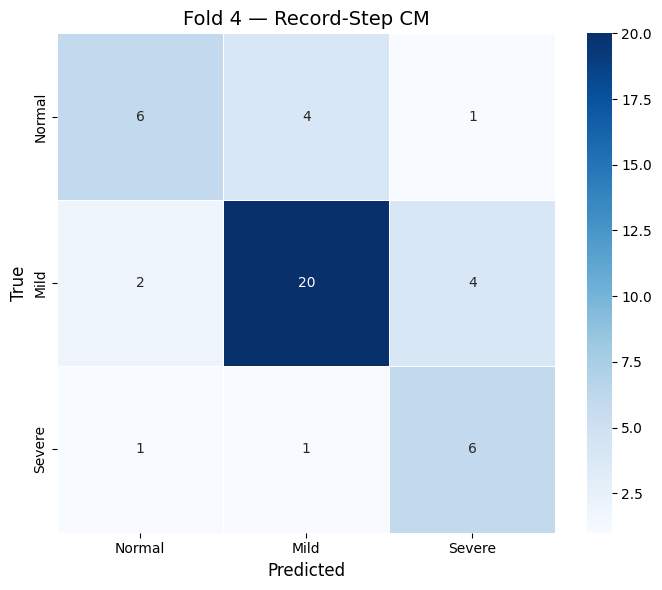


FOLD 5 / 10
  Validation quality: RELIABLE
    Normal: 16 step-units, 48 windows
    Mild: 21 step-units, 63 windows
    Severe: 5 step-units, 15 windows

TRAINING FROM SCRATCH
  Class weights (manual override): {0: 0.9, 1: 1.3, 2: 2.3}
  Early stopping monitor: val_record_step_balanced_accuracy
  Label smoothing: 0.02
Epoch 1/100
632/636 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4225 - loss: 1.4940  val_record_step_balanced_accuracy: 0.3839
636/636 ━━━━━━━━━━━━━━━━━━━━ 19s 14ms/step - accuracy: 0.4379 - loss: 1.4114 - val_accuracy: 0.5635 - val_loss: 0.9354 - val_record_step_balanced_accuracy: 0.3839 - learning_rate: 0.0010
Epoch 2/100
636/636 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4857 - loss: 1.3588  val_record_step_balanced_accuracy: 0.4873
636/636 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.4953 - loss: 1.3189 - val_accuracy: 0.5397 - val_loss: 0.9247 - val_record_step_balanced_accuracy: 0.4873 - learning_rate: 0.0010
Epoch 3/100
635/636 ━━━━━━━━━━━━━━━━━━━━ 0s

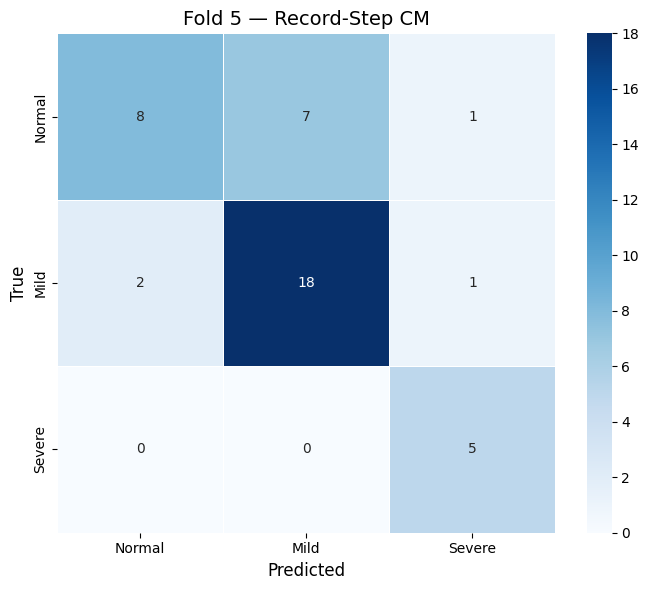


FOLD 6 / 10
  Validation quality: RELIABLE
    Normal: 24 step-units, 72 windows
    Mild: 20 step-units, 60 windows
    Severe: 6 step-units, 18 windows

TRAINING FROM SCRATCH
  Class weights (manual override): {0: 0.9, 1: 1.3, 2: 2.3}
  Early stopping monitor: val_record_step_balanced_accuracy
  Label smoothing: 0.02
Epoch 1/100
624/624 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.4575 - loss: 1.4040  val_record_step_balanced_accuracy: 0.3667
624/624 ━━━━━━━━━━━━━━━━━━━━ 18s 14ms/step - accuracy: 0.4519 - loss: 1.3795 - val_accuracy: 0.4800 - val_loss: 1.0670 - val_record_step_balanced_accuracy: 0.3667 - learning_rate: 0.0010
Epoch 2/100
622/624 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5304 - loss: 1.2989  val_record_step_balanced_accuracy: 0.4556
624/624 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.4976 - loss: 1.2982 - val_accuracy: 0.4867 - val_loss: 1.0319 - val_record_step_balanced_accuracy: 0.4556 - learning_rate: 0.0010
Epoch 3/100
624/624 ━━━━━━━━━━━━━━━━━━━━ 0s

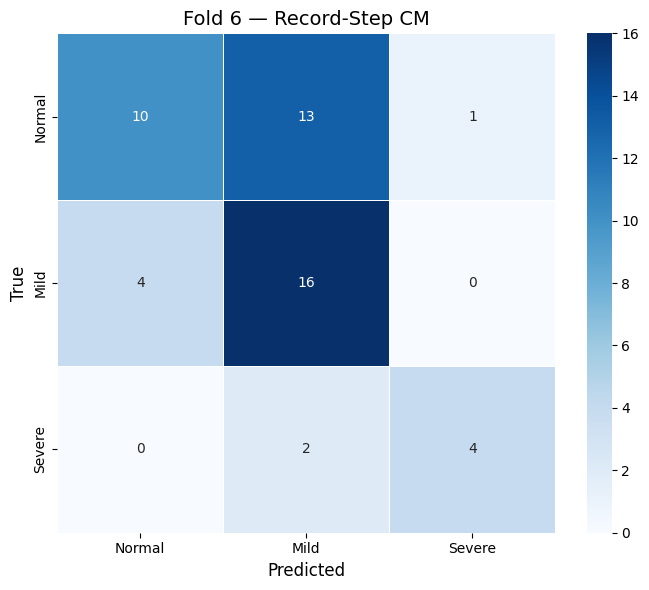


FOLD 7 / 10
  Validation quality: RELIABLE
    Normal: 15 step-units, 45 windows
    Mild: 26 step-units, 78 windows
    Severe: 5 step-units, 15 windows

TRAINING FROM SCRATCH
  Class weights (manual override): {0: 0.9, 1: 1.3, 2: 2.3}
  Early stopping monitor: val_record_step_balanced_accuracy
  Label smoothing: 0.02
Epoch 1/100
629/630 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4055 - loss: 1.4234  val_record_step_balanced_accuracy: 0.3769
630/630 ━━━━━━━━━━━━━━━━━━━━ 17s 15ms/step - accuracy: 0.4500 - loss: 1.3586 - val_accuracy: 0.5217 - val_loss: 0.9704 - val_record_step_balanced_accuracy: 0.3769 - learning_rate: 0.0010
Epoch 2/100
630/630 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4985 - loss: 1.3413  val_record_step_balanced_accuracy: 0.4214
630/630 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.5063 - loss: 1.3064 - val_accuracy: 0.5217 - val_loss: 1.0037 - val_record_step_balanced_accuracy: 0.4214 - learning_rate: 0.0010
Epoch 3/100
627/630 ━━━━━━━━━━━━━━━━━━━━ 0s

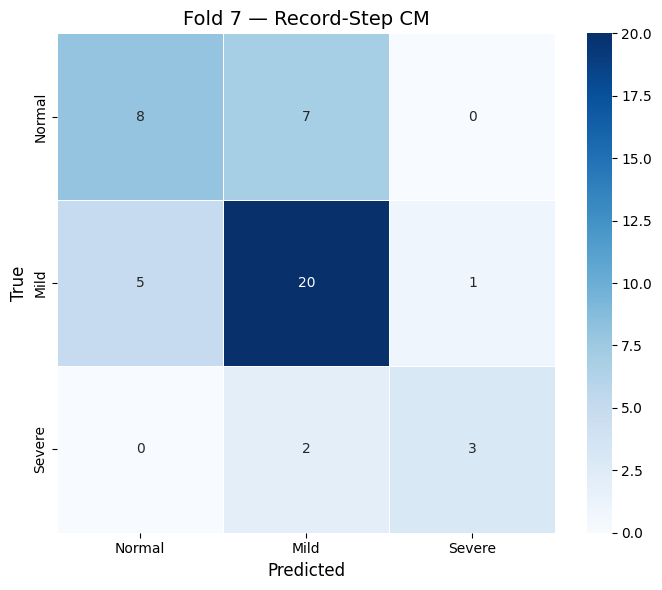


FOLD 8 / 10
  Validation quality: RELIABLE
    Normal: 16 step-units, 48 windows
    Mild: 22 step-units, 66 windows
    Severe: 6 step-units, 18 windows

TRAINING FROM SCRATCH
  Class weights (manual override): {0: 0.9, 1: 1.3, 2: 2.3}
  Early stopping monitor: val_record_step_balanced_accuracy
  Label smoothing: 0.02
Epoch 1/100
632/633 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.4102 - loss: 1.3970  val_record_step_balanced_accuracy: 0.4836
633/633 ━━━━━━━━━━━━━━━━━━━━ 18s 14ms/step - accuracy: 0.4360 - loss: 1.3766 - val_accuracy: 0.5682 - val_loss: 0.9929 - val_record_step_balanced_accuracy: 0.4836 - learning_rate: 0.0010
Epoch 2/100
631/633 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.4889 - loss: 1.3406  val_record_step_balanced_accuracy: 0.4280
633/633 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.4984 - loss: 1.3265 - val_accuracy: 0.5152 - val_loss: 1.0054 - val_record_step_balanced_accuracy: 0.4280 - learning_rate: 0.0010
Epoch 3/100
629/633 ━━━━━━━━━━━━━━━━━━━━ 0s

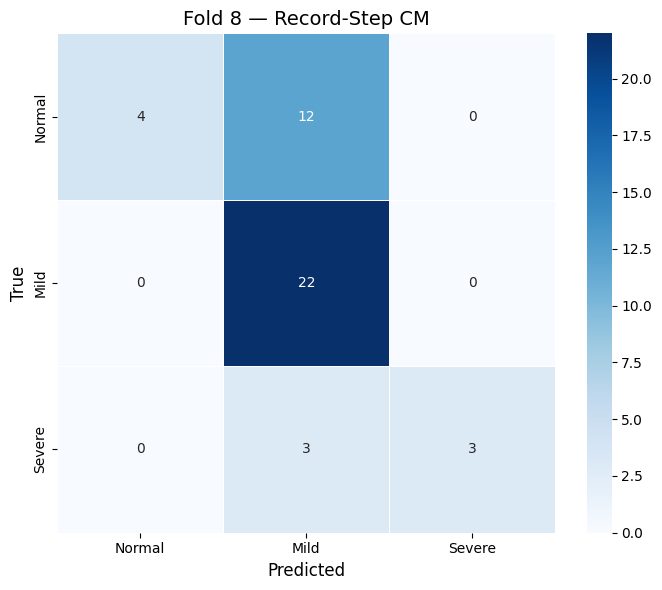


FOLD 9 / 10
  Validation quality: RELIABLE
    Normal: 23 step-units, 69 windows
    Mild: 18 step-units, 54 windows
    Severe: 10 step-units, 30 windows

TRAINING FROM SCRATCH
  Class weights (manual override): {0: 0.9, 1: 1.3, 2: 2.3}
  Early stopping monitor: val_record_step_balanced_accuracy
  Label smoothing: 0.02
Epoch 1/100
621/623 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.4781 - loss: 1.3236  val_record_step_balanced_accuracy: 0.4937
623/623 ━━━━━━━━━━━━━━━━━━━━ 20s 16ms/step - accuracy: 0.4988 - loss: 1.3123 - val_accuracy: 0.5033 - val_loss: 1.0652 - val_record_step_balanced_accuracy: 0.4937 - learning_rate: 0.0010
Epoch 2/100
619/623 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4820 - loss: 1.2478  val_record_step_balanced_accuracy: 0.4749
623/623 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.5092 - loss: 1.2589 - val_accuracy: 0.5294 - val_loss: 1.0712 - val_record_step_balanced_accuracy: 0.4749 - learning_rate: 0.0010
Epoch 3/100
622/623 ━━━━━━━━━━━━━━━━━━━━ 0

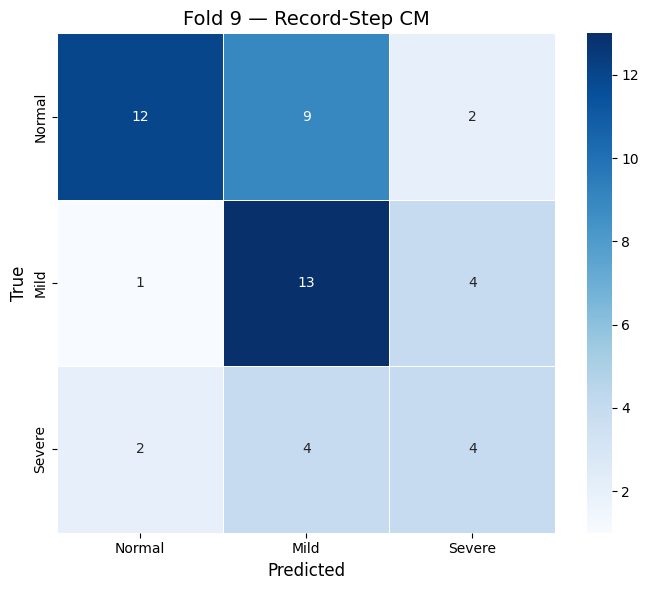


FOLD 10 / 10
  Validation quality: RELIABLE
    Normal: 24 step-units, 72 windows
    Mild: 17 step-units, 51 windows
    Severe: 5 step-units, 15 windows

TRAINING FROM SCRATCH
  Class weights (manual override): {0: 0.9, 1: 1.3, 2: 2.3}
  Early stopping monitor: val_record_step_balanced_accuracy
  Label smoothing: 0.02
Epoch 1/100
628/630 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.4429 - loss: 1.4162  val_record_step_balanced_accuracy: 0.4915
630/630 ━━━━━━━━━━━━━━━━━━━━ 19s 16ms/step - accuracy: 0.4659 - loss: 1.3831 - val_accuracy: 0.4420 - val_loss: 0.9678 - val_record_step_balanced_accuracy: 0.4915 - learning_rate: 0.0010
Epoch 2/100
630/630 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4903 - loss: 1.3302  val_record_step_balanced_accuracy: 0.4637
630/630 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.4849 - loss: 1.3338 - val_accuracy: 0.4565 - val_loss: 0.9994 - val_record_step_balanced_accuracy: 0.4637 - learning_rate: 0.0010
Epoch 3/100
629/630 ━━━━━━━━━━━━━━━━━━━━ 0

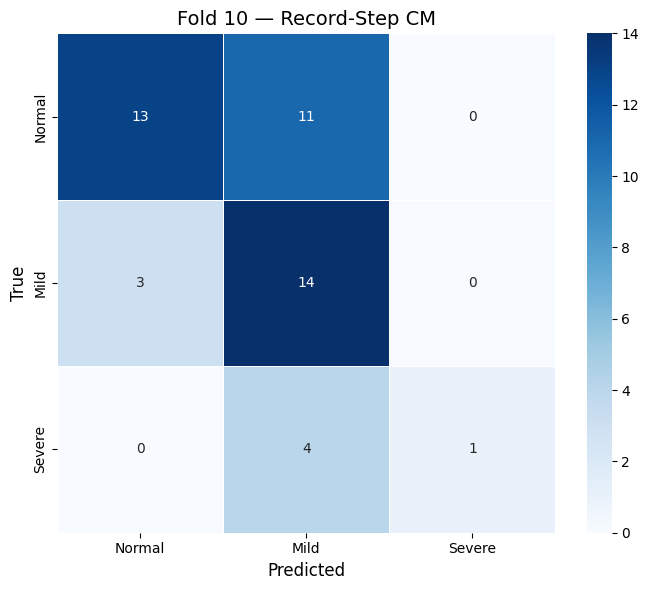

In [ ]:
from pathlib import Path
import os
import runpy
import sys


def resolve_project_root() -> Path:
    env_root = os.environ.get("CTG_DISSERTATION_ROOT")
    candidate_starts = [Path.cwd().resolve()]
    if env_root:
        candidate_starts.append(Path(env_root).expanduser().resolve())

    candidate_starts.extend(
        [
            Path("/content/CTG_Dissertation"),
            Path("/content/drive/MyDrive/CTG_Dissertation"),
        ]
    )

    seen = set()
    for start in candidate_starts:
        if start in seen:
            continue
        seen.add(start)

        for candidate in [start, *start.parents]:
            runner_candidate = candidate / "src" / "Transfer_Learning" / "run_tenfold_tuning_from_notebook.py"
            if runner_candidate.exists():
                return candidate

    raise FileNotFoundError(
        "Could not locate the CTG_Dissertation project root. "
        "In Colab, clone or copy the repo to /content/CTG_Dissertation, "
        "or set CTG_DISSERTATION_ROOT before running this cell."
    )


PROJECT_ROOT = resolve_project_root()
TRANSFER_LEARNING_DIR = PROJECT_ROOT / "src" / "Transfer_Learning"
os.chdir(TRANSFER_LEARNING_DIR)

if str(TRANSFER_LEARNING_DIR) not in sys.path:
    sys.path.insert(0, str(TRANSFER_LEARNING_DIR))

print(f"Project root: {PROJECT_ROOT}")
print(f"Working directory: {TRANSFER_LEARNING_DIR}")

runner_path = TRANSFER_LEARNING_DIR / "run_tenfold_tuning_from_notebook.py"
runner_globals = runpy.run_path(str(runner_path))
run_result = runner_globals["run"]()

tenfold_tuning_summary_df = run_result["tenfold_tuning_summary_df"]
tenfold_tuning_summaries = run_result["tenfold_tuning_summaries"]
best_tenfold_run = run_result["best_tenfold_run"]
best_current_weights = run_result["best_current_weights"]
tenfold_tuning_output_dir = run_result["tenfold_tuning_output_dir"]

tenfold_tuning_summary_df

In [ ]:
print('Best setting:')
print(f"  Manual class weights: {best_tenfold_run['manual_class_weights']}")
print(f"  Label smoothing: {best_tenfold_run['label_smoothing']:.2f}")
print(f"  OOF Severe boost: {best_tenfold_run['best_oof_severe_boost']:.2f}")
print(f"  Raw balanced accuracy: {best_tenfold_run['raw_balanced_accuracy']:.4f}")
print(f"  Calibrated balanced accuracy: {best_tenfold_run['calibrated_balanced_accuracy']:.4f}")
print(f"  Raw macro F1: {best_tenfold_run['raw_macro_f1']:.4f}")
print(f"  Calibrated macro F1: {best_tenfold_run['calibrated_macro_f1']:.4f}")
print(f"  Outputs: {tenfold_tuning_output_dir}")